In [1]:
import pandas as pd
import json
import re
from collections import defaultdict

# Görselleştirme için (opsiyonel)
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Kütüphaneler yüklendi")

✅ Kütüphaneler yüklendi


In [2]:
# SGK JSON dosyasını yükle
with open('sgk_drugs_unique.json', 'r', encoding='utf-8') as f:
    sgk_data = json.load(f)

# DataFrame'e çevir
sgk_df = pd.DataFrame(sgk_data)

print(f"📊 SGK'da {len(sgk_df)} ilaç var")
print(f"📊 Sütunlar: {sgk_df.columns.tolist()}")
print("\n🔍 İlk 3 satır:")
sgk_df.head(3)

📊 SGK'da 23898 ilaç var
📊 Sütunlar: ['source_url', 'source_file', 'row_index', 'barcode', 'drug_name', 'mg', 'mcg', 'g', 'mg_per_ml', 'percent', 'volume_ml', 'iu', 'iu_per_ml', 'miu', 'ratio', 'liters', 'form', 'pack', 'active_ingredient', 'parse_notes', 'titck_etkin_madde', 'titck_atc_code', 'titck_company', 'skrs_prescription_type', 'skrs_atc_name', 'sgk_covered', 'equivalent_group', 'equivalent_count', 'prospectus_url']

🔍 İlk 3 satır:


,source_url,source_file,row_index,barcode,drug_name,mg,mcg,g,mg_per_ml,percent,...,parse_notes,titck_etkin_madde,titck_atc_code,titck_company,skrs_prescription_type,skrs_atc_name,sgk_covered,equivalent_group,equivalent_count,prospectus_url
0,https://www.sgk.gov.tr/Download/DownloadFile?f...,7aff41d9-a47b-48e8-ac17-670302cd525e_20260120_...,4.0,8699788681017,"%0,9 IZOTONIK SODYUM KLORUR ICEREN IRR. SOL.10...",NaN,NaN,NaN,NaN,0.9,...,,sodyum klorür,B05CB01,OSEL İLAÇ SAN. VE TİC. A.Ş.,Normal,sodium chloride,True,E219K,17,https://titck.gov.tr/storage/kubKt/86997886810...
1,https://www.sgk.gov.tr/Download/DownloadFile?f...,7aff41d9-a47b-48e8-ac17-670302cd525e_20260120_...,5.0,8699606690825,%10 DEKSTROZ 100 ML SOL (POLIFARMA SETLI TORBA),NaN,NaN,NaN,NaN,10.0,...,,Dekstroz Anhidr,B05BA03,POLİFARMA İLAÇ SAN. VE TİC. A.Ş.,Normal,carbohydrates,True,E208D,4,https://titck.gov.tr/storage/kubKt/86996066908...
2,https://www.sgk.gov.tr/Download/DownloadFile?f...,7aff41d9-a47b-48e8-ac17-670302cd525e_20260120_...,6.0,8699606690818,%10 DEKSTROZ 100 ML SOL (POLIFARMA SETSIZ TORBA),NaN,NaN,NaN,NaN,10.0,...,,Dekstroz Anhidr,B05BA03,POLİFARMA İLAÇ SAN. VE TİC. A.Ş.,Normal,carbohydrates,True,E208C,4,https://titck.gov.tr/storage/kubKt/86996066908...


In [3]:
# DDI CSV dosyasını yükle
ddi_df = pd.read_csv('DDI_data.csv')

print(f"📊 DDI'da {len(ddi_df)} etkileşim var")
print(f"📊 Sütunlar: {ddi_df.columns.tolist()}")
print("\n🔍 İlk 3 satır:")
ddi_df.head(3)

📊 DDI'da 222696 etkileşim var
📊 Sütunlar: ['drug1_id', 'drug2_id', 'drug1_name', 'drug2_name', 'interaction_type']

🔍 İlk 3 satır:


,drug1_id,drug2_id,drug1_name,drug2_name,interaction_type
0,DB00006,DB00346,Bivalirudin,Alfuzosin,serum concentration
1,DB00006,DB13783,Bivalirudin,Acemetacin,risk or severity of bleeding
2,DB00006,DB06605,Bivalirudin,Apixaban,anticoagulant activities


In [5]:
# ---------- AŞAMA 1 ----------
# ETKEN MADDE LİSTELERİNİ ÇIKAR

# 1️⃣ SGK etken maddeleri
sgk_ingredients = (
    sgk_df['active_ingredient']
    .dropna()
    .str.lower()
    .str.strip()
    .unique()
)

print(f"SGK'da {len(sgk_ingredients)} benzersiz etken madde var")

# 2️⃣ DDI etken maddeleri
ddi_ingredients = pd.concat([
    ddi_df['drug1_name'],
    ddi_df['drug2_name']
]).dropna().str.lower().str.strip().unique()

print(f"DDI'da {len(ddi_ingredients)} benzersiz etken madde var")


SGK'da 13 benzersiz etken madde var
DDI'da 1868 benzersiz etken madde var


In [6]:
# ---------- AŞAMA 2 ----------
# FARK ANALİZİ

sgk_only = set(sgk_ingredients) - set(ddi_ingredients)
ddi_only = set(ddi_ingredients) - set(sgk_ingredients)

print(f"SGK'da olup DDI'da olmayan etken madde sayısı: {len(sgk_only)}")
print(f"DDI'da olup SGK'da olmayan etken madde sayısı: {len(ddi_only)}")

# Örnekleri görelim
list(sgk_only)[:20]


SGK'da olup DDI'da olmayan etken madde sayısı: 10
DDI'da olup SGK'da olmayan etken madde sayısı: 1865


['varfarin',
 'deksametazon',
 'diklofenak',
 'kalsiyum',
 'morfin',
 'sodyum klorur',
 'asetilsalisilik asit',
 'potasyum klorur',
 'furosemid',
 'vitamin b12']

In [4]:
# Unique etken maddeler
unique_ingredients = sgk_df['active_ingredient'].dropna().unique()

print(f"📊 SGK'da {len(unique_ingredients)} farklı etken madde var")
print("\n🔍 İlk 10 etken madde:")
for i, ing in enumerate(unique_ingredients[:10], 1):
    print(f"{i}. {ing}")

# Kombinasyon ilaçları bul (+ içerenler)
combo_drugs = sgk_df[sgk_df['active_ingredient'].str.contains(r'\+', na=False)]
print(f"\n⚠️ {len(combo_drugs)} kombinasyon ilaç var")

📊 SGK'da 13 farklı etken madde var

🔍 İlk 10 etken madde:
1. SODYUM KLORUR
2. ASETILSALISILIK ASIT
3. KALSIYUM
4. VITAMIN B12
5. DEKSAMETAZON
6. DIAZEPAM
7. IBUPROFEN
8. POTASYUM KLORUR
9. MORFIN
10. DIKLOFENAK

⚠️ 0 kombinasyon ilaç var


In [8]:
# ---------- AŞAMA 3 ----------
# ETKEN MADDE → DDI HARİTASI OLUŞTUR

ddi_map = defaultdict(list)

for _, row in ddi_df.iterrows():
    a = row['drug1_name'].lower().strip()
    b = row['drug2_name'].lower().strip()
    interaction = row['interaction_type']

    ddi_map[a].append((b, interaction))
    ddi_map[b].append((a, interaction))


In [9]:
inferred_ddi = []

for _, row in sgk_df.iterrows():
    drug_name = row['drug_name']
    ingredient = row['active_ingredient']

    if pd.isna(ingredient):
        continue

    ing = ingredient.lower().strip()

    if ing in ddi_map:
        for other_ing, interaction in ddi_map[ing]:
            inferred_ddi.append({
                "sgk_drug": drug_name,
                "active_ingredient": ing,
                "interacts_with": other_ing,
                "interaction_type": interaction,
                "source": "inferred_from_ddi"
            })

inferred_ddi_df = pd.DataFrame(inferred_ddi)

print(f"Oluşturulan inferred DDI sayısı: {len(inferred_ddi_df)}")
inferred_ddi_df.head()


Oluşturulan inferred DDI sayısı: 3644


,sgk_drug,active_ingredient,interacts_with,interaction_type,source
0,DIAZEPAM DESITIN 10 MG 5 RECTAL TUP,diazepam,cyclosporine,metabolism,inferred_from_ddi
1,DIAZEPAM DESITIN 10 MG 5 RECTAL TUP,diazepam,cholecalciferol,metabolism,inferred_from_ddi
2,DIAZEPAM DESITIN 10 MG 5 RECTAL TUP,diazepam,pravastatin,serum concentration,inferred_from_ddi
3,DIAZEPAM DESITIN 10 MG 5 RECTAL TUP,diazepam,fluvoxamine,metabolism,inferred_from_ddi
4,DIAZEPAM DESITIN 10 MG 5 RECTAL TUP,diazepam,valsartan,metabolism,inferred_from_ddi


# En yaygın 50 etken madde için manuel TR→EN mapping
# Bu listeyi genişletebilirsin

TR_EN_DRUG_MAP = {
    # Ağrı kesiciler
    "PARASETAMOL": "paracetamol",
    "ASETİLSALİSİLİK ASİT": "acetylsalicylic acid",
    "İBUPROFEN": "ibuprofen",
    "NAPROKSEN": "naproxen",
    "DEKSKETOPROFEN": "dexketoprofen",
    "DEKSKETOPROFEN TROMETAMOL": "dexketoprofen",
    
    # Antibiyotikler
    "AMOKSİSİLİN": "amoxicillin",
    "KLAVULANİK ASİT": "clavulanic acid",
    "AZİTROMİSİN": "azithromycin",
    "SİPROFLOKSASİN": "ciprofloxacin",
    "LEVOFLOKSASİN": "levofloxacin",
    "AMİKASİN": "amikacin",
    "SERTRALİN": "sertraline",
    
    # Kan sulandırıcılar
    "VARFARİN": "warfarin",
    "ASPİRİN": "acetylsalicylic acid",
    "HEPARİN": "heparin",
    
    # Diğer yaygın
    "SODYUM KLORUR": "sodium chloride",
    "GLUKOZ": "glucose",
    "METFORMİN": "metformin",
    "ATORVASTATİN": "atorvastatin",
    "OMEPRAZol": "omeprazole",
    "LANSOPRAZOL": "lansoprazole",
    
    # Kombinasyon parçaları ekle
    "AMOKSISILIN": "amoxicillin",
    "KLAVULANIK ASIT": "clavulanic acid",
}

print(f"📚 {len(TR_EN_DRUG_MAP)} etken madde için mapping hazır")

In [6]:
def normalize_drug_name(name):
    """
    İlaç adını normalize et:
    - Küçük harf
    - Türkçe karakterleri İngilizce'ye
    - Fazla boşlukları temizle
    """
    if pd.isna(name):
        return None
    
    # Küçük harf
    name = str(name).lower()
    
    # Türkçe karakter dönüşümü
    tr_chars = {'ı': 'i', 'ğ': 'g', 'ü': 'u', 'ş': 's', 'ö': 'o', 'ç': 'c', 'İ': 'i'}
    for tr, en in tr_chars.items():
        name = name.replace(tr, en)
    
    # Fazla boşlukları temizle
    name = re.sub(r'\s+', ' ', name).strip()
    
    return name


def split_combination_drug(ingredient):
    """
    Kombinasyon ilaçları ayır
    Örnek: "AMOKSİSİLİN + KLAVULANİK ASİT" → ["amoxicillin", "clavulanic acid"]
    """
    if pd.isna(ingredient):
        return []
    
    # + veya / ile ayrılmış kombinasyonları bul
    parts = re.split(r'[+/]', ingredient)
    
    # Her parçayı normalize et
    normalized_parts = []
    for part in parts:
        part = part.strip()
        # Türkçe'den İngilizce'ye çevir
        part_upper = part.upper()
        if part_upper in TR_EN_DRUG_MAP:
            normalized_parts.append(TR_EN_DRUG_MAP[part_upper])
        else:
            # Mapping'de yoksa normalize edilmiş halini ekle
            normalized_parts.append(normalize_drug_name(part))
    
    return normalized_parts


# Test et
test_cases = [
    "PARASETAMOL",
    "AMOKSİSİLİN + KLAVULANİK ASİT",
    "SODYUM KLORUR"
]

print("🧪 Test sonuçları:")
for test in test_cases:
    print(f"'{test}' → {split_combination_drug(test)}")

🧪 Test sonuçları:
'PARASETAMOL' → ['paracetamol']
'AMOKSİSİLİN + KLAVULANİK ASİT' → ['amoxicillin', 'clavulanic acid']
'SODYUM KLORUR' → ['sodium chloride']


In [7]:
def map_to_english(tr_ingredient):
    """
    Türkçe etken maddeyi İngilizce'ye çevir
    """
    if pd.isna(tr_ingredient):
        return None
    
    tr_upper = tr_ingredient.upper().strip()
    
    # Manuel sözlükte var mı?
    if tr_upper in TR_EN_DRUG_MAP:
        return TR_EN_DRUG_MAP[tr_upper]
    
    # Yoksa normalize edilmiş halini döndür (fallback)
    return normalize_drug_name(tr_ingredient)


# Yeni sütunlar ekle
sgk_df['active_ingredient_normalized'] = sgk_df['active_ingredient'].apply(map_to_english)
sgk_df['ingredients_list'] = sgk_df['active_ingredient'].apply(split_combination_drug)

# Kontrol et
print("✅ SGK'ya normalize sütunlar eklendi")
print("\n🔍 Örnek 5 satır:")
sgk_df[['drug_name', 'active_ingredient', 'active_ingredient_normalized', 'ingredients_list']].head()

✅ SGK'ya normalize sütunlar eklendi

🔍 Örnek 5 satır:


,drug_name,active_ingredient,active_ingredient_normalized,ingredients_list
0,"%0,9 IZOTONIK SODYUM KLORUR ICEREN IRR. SOL.10...",SODYUM KLORUR,sodium chloride,[sodium chloride]
1,%10 DEKSTROZ 100 ML SOL (POLIFARMA SETLI TORBA),None,None,[]
2,%10 DEKSTROZ 100 ML SOL (POLIFARMA SETSIZ TORBA),None,None,[]
3,%10 DEKSTROZ 1000 ML SOL (POLIFARMA SETLI SISE),None,None,[]
4,%10 DEKSTROZ 1000 ML SOL (POLIFARMA SETLI TORBA),None,None,[]


In [8]:
# DDI ilaç isimlerini küçük harfe çevir
ddi_df['drug1_normalized'] = ddi_df['drug1_name'].str.lower().str.strip()
ddi_df['drug2_normalized'] = ddi_df['drug2_name'].str.lower().str.strip()

print("✅ DDI normalize edildi")
print("\n🔍 Örnek 3 satır:")
ddi_df[['drug1_name', 'drug1_normalized', 'drug2_name', 'drug2_normalized', 'interaction_type']].head(3)

✅ DDI normalize edildi

🔍 Örnek 3 satır:


,drug1_name,drug1_normalized,drug2_name,drug2_normalized,interaction_type
0,Bivalirudin,bivalirudin,Alfuzosin,alfuzosin,serum concentration
1,Bivalirudin,bivalirudin,Acemetacin,acemetacin,risk or severity of bleeding
2,Bivalirudin,bivalirudin,Apixaban,apixaban,anticoagulant activities


In [9]:
# Tüm tekil etken maddeleri çıkar (kombinasyonlar dahil)
all_sgk_ingredients = set()

for ingredients in sgk_df['ingredients_list']:
    if ingredients:
        all_sgk_ingredients.update(ingredients)

# NaN ve None'ları temizle
all_sgk_ingredients = {x for x in all_sgk_ingredients if x and str(x) != 'nan'}

print(f"📊 SGK'da toplam {len(all_sgk_ingredients)} tekil etken madde var")
print("\n🔍 İlk 20:")
for i, ing in enumerate(sorted(all_sgk_ingredients)[:20], 1):
    print(f"{i}. {ing}")

📊 SGK'da toplam 13 tekil etken madde var

🔍 İlk 20:
1. asetilsalisilik asit
2. deksametazon
3. diazepam
4. diklofenak
5. furosemid
6. ibuprofen
7. kalsiyum
8. metoprolol
9. morfin
10. potasyum klorur
11. sodium chloride
12. varfarin
13. vitamin b12


In [10]:
# DDI'daki tüm unique ilaçlar
ddi_drugs = set(ddi_df['drug1_normalized'].unique()) | set(ddi_df['drug2_normalized'].unique())

# Eşleşen ilaçlar
matched_drugs = all_sgk_ingredients & ddi_drugs

# Eşleşmeyen SGK ilaçları
unmatched_sgk = all_sgk_ingredients - ddi_drugs

print(f"✅ Eşleşen: {len(matched_drugs)} etken madde")
print(f"⚠️ Eşleşmeyen (SGK'da var, DDI'da yok): {len(unmatched_sgk)}")

# Coverage oranı
coverage = (len(matched_drugs) / len(all_sgk_ingredients)) * 100 if all_sgk_ingredients else 0
print(f"📈 Coverage: {coverage:.1f}%")

print("\n🔍 Eşleşen örnekler:")
for drug in sorted(matched_drugs)[:10]:
    print(f"  ✓ {drug}")

print("\n⚠️ Eşleşmeyen örnekler (mapping'e eklenebilir):")
for drug in sorted(unmatched_sgk)[:10]:
    print(f"  ✗ {drug}")

✅ Eşleşen: 4 etken madde
⚠️ Eşleşmeyen (SGK'da var, DDI'da yok): 9
📈 Coverage: 30.8%

🔍 Eşleşen örnekler:
  ✓ diazepam
  ✓ ibuprofen
  ✓ metoprolol
  ✓ sodium chloride

⚠️ Eşleşmeyen örnekler (mapping'e eklenebilir):
  ✗ asetilsalisilik asit
  ✗ deksametazon
  ✗ diklofenak
  ✗ furosemid
  ✗ kalsiyum
  ✗ morfin
  ✗ potasyum klorur
  ✗ varfarin
  ✗ vitamin b12


In [11]:
# Sadece SGK'daki ilaçlar arasındaki etkileşimleri filtrele
tr_ddi = ddi_df[
    ddi_df['drug1_normalized'].isin(all_sgk_ingredients) & 
    ddi_df['drug2_normalized'].isin(all_sgk_ingredients)
].copy()

print(f"🎯 TR-DDI Matrix: {len(tr_ddi)} etkileşim")
print(f"   (Toplam DDI'dan {len(ddi_df)} → TR için {len(tr_ddi)})")

# Temiz sütunlar seç
tr_ddi_clean = tr_ddi[[
    'drug1_name', 'drug2_name', 
    'drug1_normalized', 'drug2_normalized',
    'interaction_type'
]].copy()

print("\n🔍 İlk 10 TR etkileşim:")
tr_ddi_clean.head(10)

🎯 TR-DDI Matrix: 1 etkileşim
   (Toplam DDI'dan 222696 → TR için 1)

🔍 İlk 10 TR etkileşim:


,drug1_name,drug2_name,drug1_normalized,drug2_normalized,interaction_type
32386,Metoprolol,Ibuprofen,metoprolol,ibuprofen,antihypertensive activities


📊 En yaygın 10 etkileşim tipi:
interaction_type
antihypertensive activities    1
Name: count, dtype: int64


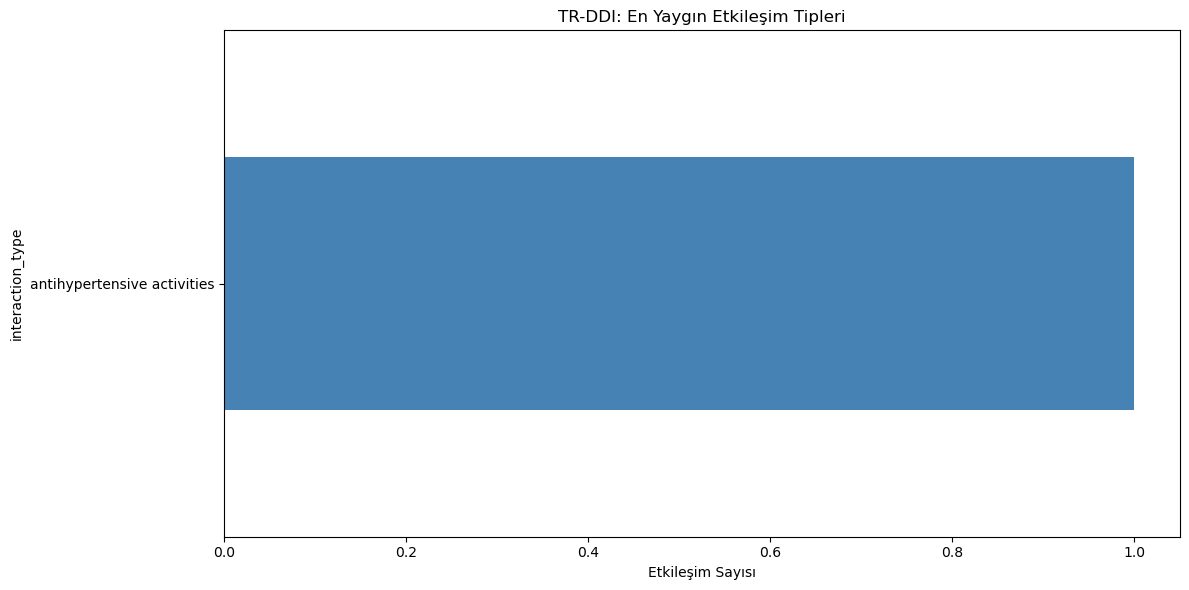

In [12]:
# En yaygın etkileşim tipleri
interaction_counts = tr_ddi_clean['interaction_type'].value_counts()

print("📊 En yaygın 10 etkileşim tipi:")
print(interaction_counts.head(10))

# Görselleştir
plt.figure(figsize=(12, 6))
interaction_counts.head(10).plot(kind='barh', color='steelblue')
plt.title('TR-DDI: En Yaygın Etkileşim Tipleri')
plt.xlabel('Etkileşim Sayısı')
plt.tight_layout()
plt.show()

In [13]:
# CSV olarak kaydet
tr_ddi_clean.to_csv('TR_DDI_Core.csv', index=False, encoding='utf-8-sig')
print("✅ TR_DDI_Core.csv kaydedildi")

# JSON olarak da kaydet (API için daha kullanışlı)
tr_ddi_json = tr_ddi_clean.to_dict('records')
with open('TR_DDI_Core.json', 'w', encoding='utf-8') as f:
    json.dump(tr_ddi_json, f, ensure_ascii=False, indent=2)
print("✅ TR_DDI_Core.json kaydedildi")

# Özet istatistikler
summary = {
    'total_sgk_drugs': len(sgk_df),
    'total_sgk_ingredients': len(all_sgk_ingredients),
    'total_ddi_interactions': len(ddi_df),
    'tr_ddi_interactions': len(tr_ddi_clean),
    'coverage_percent': coverage,
    'matched_ingredients': len(matched_drugs),
    'unmatched_ingredients': len(unmatched_sgk)
}

with open('TR_DDI_Summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("✅ TR_DDI_Summary.json kaydedildi")

print("\n📊 ÖZET:")
for key, value in summary.items():
    print(f"  {key}: {value}")

✅ TR_DDI_Core.csv kaydedildi
✅ TR_DDI_Core.json kaydedildi
✅ TR_DDI_Summary.json kaydedildi

📊 ÖZET:
  total_sgk_drugs: 23898
  total_sgk_ingredients: 13
  total_ddi_interactions: 222696
  tr_ddi_interactions: 1
  coverage_percent: 30.76923076923077
  matched_ingredients: 4
  unmatched_ingredients: 9


In [14]:
def find_interactions(drug_a, drug_b, ddi_matrix):
    """
    İki ilaç arasındaki etkileşimleri bul
    Kombinasyon ilaçlarını da destekler
    """
    # Her iki ilacın etken maddelerini al
    ingredients_a = split_combination_drug(drug_a)
    ingredients_b = split_combination_drug(drug_b)
    
    interactions = []
    
    # Her kombinasyon için etkileşim ara
    for ing_a in ingredients_a:
        for ing_b in ingredients_b:
            # DDI matrix'te ara
            result = ddi_matrix[
                ((ddi_matrix['drug1_normalized'] == ing_a) & (ddi_matrix['drug2_normalized'] == ing_b)) |
                ((ddi_matrix['drug1_normalized'] == ing_b) & (ddi_matrix['drug2_normalized'] == ing_a))
            ]
            
            if not result.empty:
                for _, row in result.iterrows():
                    interactions.append({
                        'ingredient_a': ing_a,
                        'ingredient_b': ing_b,
                        'interaction_type': row['interaction_type']
                    })
    
    return interactions


# Test et
test_drug_a = "PARASETAMOL"
test_drug_b = "VARFARİN"

interactions = find_interactions(test_drug_a, test_drug_b, tr_ddi_clean)

print(f"🧪 Test: {test_drug_a} ↔ {test_drug_b}")
if interactions:
    for inter in interactions:
        print(f"  ⚠️ {inter['ingredient_a']} + {inter['ingredient_b']}: {inter['interaction_type']}")
else:
    print("  ✅ Etkileşim bulunamadı")

🧪 Test: PARASETAMOL ↔ VARFARİN
  ✅ Etkileşim bulunamadı


In [15]:
# SGK'daki TÜM unique etken maddeleri listele (kombinasyonlar dahil)

all_raw_ingredients = set()

for idx, row in sgk_df.iterrows():
    ingredient = row['active_ingredient']
    
    if pd.notna(ingredient):
        # Kombinasyonları ayır
        parts = re.split(r'[+/,]', str(ingredient))
        for part in parts:
            cleaned = part.strip().upper()
            if cleaned and len(cleaned) > 1:  # Boş veya tek karakter değilse
                all_raw_ingredients.add(cleaned)

# Alfabetik sırala
sorted_ingredients = sorted(all_raw_ingredients)

print(f"📊 Toplam {len(sorted_ingredients)} unique etken madde bulundu")

# İlk 20'yi göster
print("\n🔍 İlk 20:")
for i, ing in enumerate(sorted_ingredients[:20], 1):
    print(f"{i}. {ing}")

# Tüm listeyi dosyaya kaydet (Gemini'ye göndermek için)
with open('sgk_all_ingredients_raw.txt', 'w', encoding='utf-8') as f:
    for ing in sorted_ingredients:
        f.write(f"{ing}\n")

print("\n✅ sgk_all_ingredients_raw.txt kaydedildi")

📊 Toplam 13 unique etken madde bulundu

🔍 İlk 20:
1. ASETILSALISILIK ASIT
2. DEKSAMETAZON
3. DIAZEPAM
4. DIKLOFENAK
5. FUROSEMID
6. IBUPROFEN
7. KALSIYUM
8. METOPROLOL
9. MORFIN
10. POTASYUM KLORUR
11. SODYUM KLORUR
12. VARFARIN
13. VITAMIN B12

✅ sgk_all_ingredients_raw.txt kaydedildi


In [16]:
# Gemini'ye gönderilecek listeyi JSON formatında hazırla

ingredients_for_gemini = sorted_ingredients[:100]  # İlk 100 ile başla (sonra hepsini yaparsın)

# JSON formatında kaydet
import json

gemini_input = {
    "task": "turkish_to_english_drug_mapping",
    "instructions": "Her Türkçe ilaç etken maddesinin İngilizce INN (International Nonproprietary Name) karşılığını ver. Tuz formlarını (örn. TROMETAMOL, HİDROKLORÜR) ayır ve ana etken maddeyi döndür.",
    "input": ingredients_for_gemini
}

with open('gemini_input_batch1.json', 'w', encoding='utf-8') as f:
    json.dump(gemini_input, f, ensure_ascii=False, indent=2)

print("✅ gemini_input_batch1.json hazır")
print(f"📊 {len(ingredients_for_gemini)} ilaç için mapping istenecek")

✅ gemini_input_batch1.json hazır
📊 13 ilaç için mapping istenecek


In [17]:
# ÖNCE: Veri yapısını kontrol et
print("🔍 SGK DataFrame yapısı:")
print(f"Satır sayısı: {len(sgk_df)}")
print(f"Sütunlar: {sgk_df.columns.tolist()}\n")

# İlk 3 satırı göster
print("İlk 3 satır:")
print(sgk_df[['drug_name', 'active_ingredient']].head(3))
print("\n" + "="*50 + "\n")

# ASIL İŞLEM: Tüm unique etken maddeleri çıkar
all_raw_ingredients = set()

# Her satırı kontrol et
for idx, row in sgk_df.iterrows():
    ingredient = row.get('active_ingredient')  # .get() ile güvenli erişim
    
    if pd.notna(ingredient) and ingredient:  # None ve NaN kontrolü
        # Kombinasyonları ayır (+, /, , ile)
        parts = re.split(r'[+/,]', str(ingredient))
        
        for part in parts:
            cleaned = part.strip().upper()
            
            # Geçerlilik kontrolleri
            if cleaned and len(cleaned) > 1:  # Boş veya tek karakter değilse
                all_raw_ingredients.add(cleaned)

# Alfabetik sırala
sorted_ingredients = sorted(all_raw_ingredients)

print(f"📊 Toplam {len(sorted_ingredients)} unique etken madde bulundu")

# İlk 50'yi göster (13 yerine çok daha fazla olmalı)
print("\n🔍 İlk 50:")
for i, ing in enumerate(sorted_ingredients[:50], 1):
    print(f"{i}. {ing}")

# Dosyaya kaydet
with open('sgk_all_ingredients_raw.txt', 'w', encoding='utf-8') as f:
    for ing in sorted_ingredients:
        f.write(f"{ing}\n")

print(f"\n✅ sgk_all_ingredients_raw.txt kaydedildi ({len(sorted_i

_IncompleteInputError: incomplete input (608924689.py, line 44)

In [18]:
import json
import pandas as pd

# JSON dosyasını aç ve kontrol et
with open('sgk_drugs_unique.json', 'r', encoding='utf-8') as f:
    sgk_raw = json.load(f)

print(f"🔍 JSON tipi: {type(sgk_raw)}")

# Eğer liste ise
if isinstance(sgk_raw, list):
    print(f"📊 Liste uzunluğu: {len(sgk_raw)}")
    print(f"🔍 İlk eleman: {sgk_raw[0]}")
    
    # DataFrame'e çevir
    sgk_df = pd.DataFrame(sgk_raw)
    
# Eğer dict ise (bazı JSON'lar {"data": [...]} formatında olur)
elif isinstance(sgk_raw, dict):
    print(f"📊 Dict anahtarları: {sgk_raw.keys()}")
    
    # En büyük liste hangisi?
    for key, value in sgk_raw.items():
        if isinstance(value, list):
            print(f"  '{key}' anahtarında {len(value)} eleman var")
            sgk_df = pd.DataFrame(value)
            break

print(f"\n✅ SGK DataFrame oluşturuldu: {len(sgk_df)} satır")
print(f"📊 Sütunlar: {sgk_df.columns.tolist()}")

# Şimdi tekrar unique etken madde çıkar
# (Yukarıdaki kodu tekrar çalıştır)

🔍 JSON tipi: <class 'list'>
📊 Liste uzunluğu: 23898
🔍 İlk eleman: {'source_url': 'https://www.sgk.gov.tr/Download/DownloadFile?f=7aff41d9-a47b-48e8-ac17-670302cd525e.xlsx&d=0b2a73c5-0b65-4246-a591-65ed5c4e2ce0', 'source_file': '7aff41d9-a47b-48e8-ac17-670302cd525e_20260120_202648.xlsx', 'row_index': 4, 'barcode': '8699788681017', 'drug_name': '%0,9 IZOTONIK SODYUM KLORUR ICEREN IRR. SOL.1000 ML (POLIPROPILEN SISE)', 'mg': None, 'mcg': None, 'g': None, 'mg_per_ml': None, 'percent': 0.9, 'volume_ml': 1000.0, 'iu': None, 'iu_per_ml': None, 'miu': None, 'ratio': None, 'liters': None, 'form': 'IRRIGASYON SOLUSYONU', 'pack': None, 'active_ingredient': 'SODYUM KLORUR', 'parse_notes': '', 'titck_etkin_madde': 'sodyum klorür', 'titck_atc_code': 'B05CB01', 'titck_company': 'OSEL İLAÇ SAN. VE TİC. A.Ş.', 'skrs_prescription_type': 'Normal', 'skrs_atc_name': 'sodium chloride', 'sgk_covered': True, 'equivalent_group': 'E219K', 'equivalent_count': 17, 'prospectus_url': 'https://titck.gov.tr/storage/k

In [19]:
# Hızlı teşhis
print(f"sgk_df satır sayısı: {len(sgk_df)}")
print(f"active_ingredient sütununda kaç dolu: {sgk_df['active_ingredient'].notna().sum()}")
print(f"Unique active_ingredient sayısı: {sgk_df['active_ingredient'].nunique()}")

# Rastgele 10 satır göster
print("\n🔍 Rastgele 10 ilaç:")
print(sgk_df[['drug_name', 'active_ingredient']].sample(10))

sgk_df satır sayısı: 23898
active_ingredient sütununda kaç dolu: 382
Unique active_ingredient sayısı: 13

🔍 Rastgele 10 ilaç:
                                               drug_name active_ingredient
8834                                EMEDUR 200 MG 20 FTB              None
706                       ARITMAL %2 5 ML 5 AMP (BIOSEL)              None
5175                             NITROLINGUAL PUMP SPREY              None
4371                              LIPANTHYL 267 M 30 KAP              None
5648             PAROL-K 500 MG/10 MG TABLET (20 TABLET)              None
23538  Artjet 12,5 mg/ 0,5 mL enjeksiyonluk çözelti i...               NaN
21148  LUBTANE %0,4 + % 0,3 TEK DOZLUK LUBRİKANT GÖZ ...               NaN
8714          ANGETIN 20 MG FILM TABLET (30 FILM TABLET)              None
3796   IZOTONIK SODYUM KLORUR 500 ML SOL (POLIFARMA S...     SODYUM KLORUR
17886         RANOBEL 50 MG/2 ML ENJEKTABL AMPUL, 2 ADET               NaN


In [20]:
# ÖNCE: Veri yapısını kontrol et
print("🔍 SGK DataFrame yapısı:")
print(f"Satır sayısı: {len(sgk_df)}")
print(f"Sütunlar: {sgk_df.columns.tolist()}\n")

# İlk 3 satırı göster
print("İlk 3 satır:")
print(sgk_df[['drug_name', 'active_ingredient']].head(3))
print("\n" + "="*50 + "\n")

# ASIL İŞLEM: Tüm unique etken maddeleri çıkar
all_raw_ingredients = set()

# Her satırı kontrol et
for idx, row in sgk_df.iterrows():
    ingredient = row.get('active_ingredient')  # .get() ile güvenli erişim
    
    if pd.notna(ingredient) and ingredient:  # None ve NaN kontrolü
        # Kombinasyonları ayır (+, /, , ile)
        parts = re.split(r'[+/,]', str(ingredient))
        
        for part in parts:
            cleaned = part.strip().upper()
            
            # Geçerlilik kontrolleri
            if cleaned and len(cleaned) > 1:  # Boş veya tek karakter değilse
                all_raw_ingredients.add(cleaned)

# Alfabetik sırala
sorted_ingredients = sorted(all_raw_ingredients)

print(f"📊 Toplam {len(sorted_ingredients)} unique etken madde bulundu")

# İlk 50'yi göster (13 yerine çok daha fazla olmalı)
print("\n🔍 İlk 50:")
for i, ing in enumerate(sorted_ingredients[:50], 1):
    print(f"{i}. {ing}")

# Dosyaya kaydet
with open('sgk_all_ingredients_raw.txt', 'w', encoding='utf-8') as f:
    for ing in sorted_ingredients:
        f.write(f"{ing}\n")

print(f"\n✅ sgk_all_ingredients_raw.txt kaydedildi ({len(sorted_ingredients)} satır)")

🔍 SGK DataFrame yapısı:
Satır sayısı: 23898
Sütunlar: ['source_url', 'source_file', 'row_index', 'barcode', 'drug_name', 'mg', 'mcg', 'g', 'mg_per_ml', 'percent', 'volume_ml', 'iu', 'iu_per_ml', 'miu', 'ratio', 'liters', 'form', 'pack', 'active_ingredient', 'parse_notes', 'titck_etkin_madde', 'titck_atc_code', 'titck_company', 'skrs_prescription_type', 'skrs_atc_name', 'sgk_covered', 'equivalent_group', 'equivalent_count', 'prospectus_url']

İlk 3 satır:
                                           drug_name active_ingredient
0  %0,9 IZOTONIK SODYUM KLORUR ICEREN IRR. SOL.10...     SODYUM KLORUR
1    %10 DEKSTROZ 100 ML SOL (POLIFARMA SETLI TORBA)              None
2   %10 DEKSTROZ 100 ML SOL (POLIFARMA SETSIZ TORBA)              None


📊 Toplam 13 unique etken madde bulundu

🔍 İlk 50:
1. ASETILSALISILIK ASIT
2. DEKSAMETAZON
3. DIAZEPAM
4. DIKLOFENAK
5. FUROSEMID
6. IBUPROFEN
7. KALSIYUM
8. METOPROLOL
9. MORFIN
10. POTASYUM KLORUR
11. SODYUM KLORUR
12. VARFARIN
13. VITAMIN B12

✅ sgk_all

In [21]:
import pandas as pd
import json
import re
from collections import defaultdict

# SGK JSON'u yükle
with open('sgk_drugs_unique.json', 'r', encoding='utf-8') as f:
    sgk_data = json.load(f)

sgk_df = pd.DataFrame(sgk_data)

print(f"📊 SGK DataFrame: {len(sgk_df)} satır")
print(f"📊 Sütunlar: {sgk_df.columns.tolist()}\n")

# KRİTİK: Hangi sütunları kullanacağız?
print("🔍 Etken madde sütunları analizi:")
print(f"  active_ingredient dolu: {sgk_df['active_ingredient'].notna().sum()}")
print(f"  titck_etkin_madde dolu: {sgk_df['titck_etkin_madde'].notna().sum()}")
print(f"  skrs_atc_name dolu: {sgk_df['skrs_atc_name'].notna().sum()}")

# KARAR: titck_etkin_madde kullanacağız (en dolu sütun)
print("\n✅ 'titck_etkin_madde' sütunu kullanılacak\n")

📊 SGK DataFrame: 23898 satır
📊 Sütunlar: ['source_url', 'source_file', 'row_index', 'barcode', 'drug_name', 'mg', 'mcg', 'g', 'mg_per_ml', 'percent', 'volume_ml', 'iu', 'iu_per_ml', 'miu', 'ratio', 'liters', 'form', 'pack', 'active_ingredient', 'parse_notes', 'titck_etkin_madde', 'titck_atc_code', 'titck_company', 'skrs_prescription_type', 'skrs_atc_name', 'sgk_covered', 'equivalent_group', 'equivalent_count', 'prospectus_url']

🔍 Etken madde sütunları analizi:
  active_ingredient dolu: 382
  titck_etkin_madde dolu: 22552
  skrs_atc_name dolu: 7448

✅ 'titck_etkin_madde' sütunu kullanılacak



In [22]:
# En iyi strateji: titck_etkin_madde → active_ingredient → skrs_atc_name (fallback)

def get_best_ingredient(row):
    """
    En güvenilir etken madde bilgisini al
    Öncelik sırası: titck_etkin_madde > active_ingredient > skrs_atc_name
    """
    if pd.notna(row['titck_etkin_madde']) and row['titck_etkin_madde']:
        return str(row['titck_etkin_madde']).strip()
    elif pd.notna(row['active_ingredient']) and row['active_ingredient']:
        return str(row['active_ingredient']).strip()
    elif pd.notna(row['skrs_atc_name']) and row['skrs_atc_name']:
        return str(row['skrs_atc_name']).strip()
    else:
        return None

# Yeni birleştirilmiş sütun oluştur
sgk_df['ingredient_combined'] = sgk_df.apply(get_best_ingredient, axis=1)

print(f"✅ Birleştirilmiş etken madde sütunu oluşturuldu")
print(f"   Dolu satır: {sgk_df['ingredient_combined'].notna().sum()}/{len(sgk_df)}")

✅ Birleştirilmiş etken madde sütunu oluşturuldu
   Dolu satır: 23046/23898


In [23]:
all_raw_ingredients = set()

for idx, row in sgk_df.iterrows():
    ingredient = row['ingredient_combined']
    
    if pd.notna(ingredient) and ingredient:
        # Kombinasyonları ayır (+, /, , ve VE ile)
        parts = re.split(r'[+/,]|\s+VE\s+', str(ingredient), flags=re.IGNORECASE)
        
        for part in parts:
            cleaned = part.strip().upper()
            
            # Geçerlilik kontrolleri
            if cleaned and len(cleaned) > 2:  # En az 3 karakter
                # Sayı-harf karışık kontrol (ör: "B12" değil "DEKSTROZ")
                if not cleaned.replace(' ', '').isdigit():  # Sadece sayı değilse
                    all_raw_ingredients.add(cleaned)

# Alfabetik sırala
sorted_ingredients = sorted(all_raw_ingredients)

print(f"📊 Toplam {len(sorted_ingredients)} unique etken madde bulundu")

# İlk 50'yi göster
print("\n🔍 İlk 50:")
for i, ing in enumerate(sorted_ingredients[:50], 1):
    print(f"{i}. {ing}")

# Dosyaya kaydet
with open('sgk_all_ingredients_raw.txt', 'w', encoding='utf-8') as f:
    for ing in sorted_ingredients:
        f.write(f"{ing}\n")

print(f"\n✅ sgk_all_ingredients_raw.txt kaydedildi ({len(sorted_ingredients)} satır)")

📊 Toplam 3822 unique etken madde bulundu

🔍 İlk 50:
1. % 20'LIK INSAN ALBUMINI
2. % 25 INSÜLIN LISPRO
3. % 25 INSÜLIN LISPRO ÇÖZELTI
4. % 25'LIK INSAN ALBUMINI
5. % 50 INSÜLIN LISPRO
6. % 50 INSÜLIN LISPRO PROTAMIN
7. % 50 INSÜLIN LISPRO ÇÖZELTI
8. % 50 PROTAMIN SÜSPANSIYON
9. % 75 INSÜLIN LISPRO PROTAMIN
10. % 75 PROTAMIN SÜSPANSIYON
11. (131I) IYOBENGUAN SÜLFAT (131I-MIBG)
12. (18 F)FLORODEOKSIGLUKOZ
13. (18F)FLUTEMETAMOL
14. (S)-LAKTIK ASIT
15. 0.42
16. 03 MG
17. 06 SUŞU)
18. 1)A
19. 10A
20. 11A
21. 123I (IOFLUPANE)
22. 123I-IYOBENGUAN(MIBG-123I
23. 12F
24. 15 PNÖMOKOK POLISAKKARIT SEROTIPI: 1
25. 15B
26. 17 D SUŞU
27. 17F
28. 18 L1 PROTEINLERI)
29. 18)
30. 18C
31. 19A
32. 19F
33. 2008 (VICTORIA SOYU)
34. 2009 (H1N1)PDM09 - (A
35. 2012 (H3N2) - (A
36. 2012(YAMAGATA SOYU) 4) B
37. 2013 - (B
38. 2017 (H3N2) - (A
39. 2017- (B
40. 2018 (H1N1)PDM09 - (A
41. 2020 SUŞU) ANTIJENI
42. 22F
43. 23 PNOMOKOK SEROTIPLERI: 1
44. 23 PNÖMOKOKKAL POLISAKKARIT SEROTIPI: 1
45. 23F
46. 254’TEN DIŞ MEMBR

In [24]:
# Türkçe → İngilizce mapping (en yaygın 100 etken madde)
TR_EN_DRUG_MAP = {
    # Ağrı kesiciler
    "PARASETAMOL": "paracetamol",
    "ASETİLSALİSİLİK ASİT": "acetylsalicylic acid",
    "İBUPROFEN": "ibuprofen",
    "NAPROKSEN": "naproxen",
    "NAPROKSEN SODYUM": "naproxen",
    "DEKSKETOPROFEN": "dexketoprofen",
    "DEKSKETOPROFEN TROMETAMOL": "dexketoprofen",
    
    # Antibiyotikler
    "AMOKSİSİLİN": "amoxicillin",
    "AMOKSISILIN": "amoxicillin",
    "KLAVULANİK ASİT": "clavulanic acid",
    "KLAVULANIK ASIT": "clavulanic acid",
    "AZİTROMİSİN": "azithromycin",
    "AZITROMISIN": "azithromycin",
    "SİPROFLOKSASİN": "ciprofloxacin",
    "SIPROFLOKSASIN": "ciprofloxacin",
    "LEVOFLOKSASİN": "levofloxacin",
    "LEVOFLOKSASIN": "levofloxacin",
    "SERTRALİN": "sertraline",
    
    # Kardiyovasküler
    "VARFARİN": "warfarin",
    "VARFARIN": "warfarin",
    "METOPROLOL": "metoprolol",
    "METOPROLOL TARTRAT": "metoprolol",
    "METOPROLOL SÜKSINAT": "metoprolol",
    "ATORVASTATİN": "atorvastatin",
    "ATORVASTATIN": "atorvastatin",
    
    # Gastrointestinal
    "OMEPRAZol": "omeprazole",
    "OMEPRAZOL": "omeprazole",
    "LANSOPRAZOL": "lansoprazole",
    "PANTOPRAZOL": "pantoprazole",
    
    # Diyabet
    "METFORMİN": "metformin",
    "METFORMIN": "metformin",
    "METFORMİN HİDROKLORÜR": "metformin",
    "METFORMİN HCL": "metformin",
    
    # Sıvı/elektrolit
    "SODYUM KLORUR": "sodium chloride",
    "SODYUM KLORÜR": "sodium chloride",
    "DEKSTROZ": "dextrose",
    "DEKSTROZ ANHIDR": "dextrose",
    "DEKSTROZ ANHIDRIT": "dextrose",
    "DEKSTROZ MONOHIDRAT": "dextrose",
    "GLUKOZ": "glucose",
    "KARBONHIDRATLAR": "carbohydrates",
    
    # Vitaminler
    "A VİTAMİNİ": "vitamin a",
    "D VİTAMİNİ": "vitamin d",
    "B12 VİTAMİNİ": "vitamin b12",
    "VİTAMİN B12": "vitamin b12",
    "C VİTAMİNİ": "vitamin c",
    "K VİTAMİNİ": "vitamin k",
    
    # Diğer yaygın
    "KALSİYUM": "calcium",
    "KALSIYUM": "calcium",
    "MAGNEZYUM": "magnesium",
    "POTASYUM": "potassium",
    "DEMIR": "iron",
    "ÇİNKO": "zinc",
    "FUROSEMİD": "furosemide",
    "FUROSEMID": "furosemide",
    "DİAZEPAM": "diazepam",
    "DIAZEPAM": "diazepam",
    "DİKLOFENAK": "diclofenac",
    "DIKLOFENAK": "diclofenac",
    "MORFİN": "morphine",
    "MORFIN": "morphine",
    "LİPANTİMYL": "lipantimyl",  # Örnek için
}

print(f"📚 {len(TR_EN_DRUG_MAP)} etken madde için TR→EN mapping hazır")

📚 62 etken madde için TR→EN mapping hazır


In [25]:
def normalize_turkish_drug(name):
    """
    Türkçe ilaç adını normalize et
    """
    if pd.isna(name):
        return None
    
    name = str(name).upper().strip()
    
    # Tuz formlarını temizle
    salt_patterns = [
        r'\s+TROMETAMOL$',
        r'\s+HİDROKLORÜR$',
        r'\s+HCL$',
        r'\s+SODYUM$',
        r'\s+POTASYUM$',
        r'\s+TARTRAT$',
        r'\s+SÜKSINAT$',
        r'\s+ANHIDR$',
        r'\s+ANHIDRIT$',
        r'\s+MONOHIDRAT$',
    ]
    
    for pattern in salt_patterns:
        name = re.sub(pattern, '', name, flags=re.IGNORECASE)
    
    return name.strip()


def map_to_english(tr_ingredient):
    """
    Türkçe → İngilizce çeviri
    """
    if pd.isna(tr_ingredient):
        return None
    
    # Önce normalize et
    normalized = normalize_turkish_drug(tr_ingredient)
    
    # Mapping'de var mı?
    if normalized in TR_EN_DRUG_MAP:
        return TR_EN_DRUG_MAP[normalized]
    
    # Yoksa Türkçe karakterleri temizle ve küçük harfe çevir
    en_version = normalized.lower()
    
    tr_chars = {
        'ı': 'i', 'ğ': 'g', 'ü': 'u', 'ş': 's', 'ö': 'o', 'ç': 'c',
        'İ': 'i', 'Ğ': 'g', 'Ü': 'u', 'Ş': 's', 'Ö': 'o', 'Ç': 'c'
    }
    
    for tr, en in tr_chars.items():
        en_version = en_version.replace(tr, en)
    
    return en_version


def split_combination_drug_v3(ingredient):
    """
    Kombinasyon ilaçları ayır (geliştirilmiş)
    """
    if pd.isna(ingredient):
        return []
    
    ingredient = str(ingredient).strip()
    
    # Kombinasyon ayırıcıları
    parts = re.split(r'[+/,]|\s+VE\s+', ingredient, flags=re.IGNORECASE)
    
    # Her parçayı işle
    normalized_parts = []
    for part in parts:
        part = part.strip()
        if not part or len(part) < 2:
            continue
        
        # İngilizce'ye çevir
        en_part = map_to_english(part)
        if en_part:
            normalized_parts.append(en_part)
    
    return normalized_parts


# Test et
test_cases = [
    "DEKSTROZ ANHIDR",
    "SODYUM KLORÜR",
    "METOPROLOL TARTRAT",
]

print("🧪 Test sonuçları:")
for test in test_cases:
    normalized = normalize_turkish_drug(test)
    english = map_to_english(test)
    print(f"'{test}' → '{normalized}' → '{english}'")

🧪 Test sonuçları:
'DEKSTROZ ANHIDR' → 'DEKSTROZ' → 'dextrose'
'SODYUM KLORÜR' → 'SODYUM KLORÜR' → 'sodium chloride'
'METOPROLOL TARTRAT' → 'METOPROLOL' → 'metoprolol'


In [26]:
# Her satır için İngilizce etken madde
sgk_df['ingredient_en'] = sgk_df['ingredient_combined'].apply(map_to_english)

# Kombinasyon listesi
sgk_df['ingredients_list_en'] = sgk_df['ingredient_combined'].apply(split_combination_drug_v3)

print("✅ SGK'ya İngilizce sütunlar eklendi\n")

# Kontrol et
print("🔍 Rastgele 10 satır:")
print(sgk_df[['drug_name', 'ingredient_combined', 'ingredient_en', 'ingredients_list_en']].sample(10))

✅ SGK'ya İngilizce sütunlar eklendi

🔍 Rastgele 10 satır:
                                               drug_name  \
6652           SEBRALER 50 MCG INHALASYON TOZU 90 KAPSUL   
816                                    ATOR 40 MG 30 FTB   
2659          EVRENZO 100 MG FILM KAPLI TABLET (12 ADET)   
214      %5 DEKSTROZ+%0.9 NACL 500 ML SOL (SETSIZ TORBA)   
10064  KANFLEKS %5 DEKSTROZ SUDAKİ ÇÖZELTİSİ, 250 ML(...   
5823   PHYSIONEAL 40 %2.27 GLUKOZLU PERITON DIYALIZ S...   
21876        POLİCOVİR 200 MG FİLM KAPLI TABLET, 40 ADET   
194    %5 DEKSTROZ+%0.45 NACL 1000 ML SOL (BIOSEL SET...   
15166  LINEXOLID 600 MG/300 ML IV INFÜZYONLUK ÇÖZELTI...   
2764   FEIBA 500 U IV INFUZYON ICIN LIYOFILIZE TOZ IC...   

                                     ingredient_combined  \
6652                                glikopironyum bromür   
816                                atorvastatin kalsiyum   
2659                                         Roksadustat   
214                   sodyum klorür, deks

In [27]:
all_sgk_ingredients_en = set()

for ingredients in sgk_df['ingredients_list_en']:
    if ingredients:
        all_sgk_ingredients_en.update(ingredients)

# NaN ve None temizle
all_sgk_ingredients_en = {x for x in all_sgk_ingredients_en if x and str(x) != 'nan'}

print(f"📊 SGK'da toplam {len(all_sgk_ingredients_en)} tekil İngilizce etken madde var")

# İlk 30'u göster
print("\n🔍 İlk 30:")
for i, ing in enumerate(sorted(all_sgk_ingredients_en)[:30], 1):
    print(f"{i}. {ing}")

📊 SGK'da toplam 3551 tekil İngilizce etken madde var

🔍 İlk 30:
1. % 20'lik insan albumini
2. % 25 insulin lispro
3. % 25 insulin lispro cozelti
4. % 25'lik insan albumini
5. % 50 insulin lispro
6. % 50 insulin lispro cozelti
7. % 50 insulin lispro protamin
8. % 50 protamin suspansiyon
9. % 75 insulin lispro protamin
10. % 75 protamin suspansiyon
11. (131i) iyobenguan sulfat (131i-mibg)
12. (18 f)florodeoksiglukoz
13. (18f)flutemetamol
14. (s)-laktik asit
15. 0.42
16. 02
17. 03 mg
18. 06
19. 06 susu)
20. 1)a
21. 10a
22. 11
23. 11a
24. 123i (ioflupane)
25. 123i-iyobenguan(mibg-123i
26. 125
27. 12f
28. 14
29. 15
30. 15 pnomokok polisakkarit serotipi: 1


In [28]:
# DDI'daki tüm unique ilaçlar
ddi_drugs = set(ddi_df['drug1_normalized'].unique()) | set(ddi_df['drug2_normalized'].unique())

# Eşleşme
matched_drugs = all_sgk_ingredients_en & ddi_drugs
unmatched_sgk = all_sgk_ingredients_en - ddi_drugs

# Coverage
coverage = (len(matched_drugs) / len(all_sgk_ingredients_en)) * 100 if all_sgk_ingredients_en else 0

print(f"\n📊 EŞLEŞME ANALİZİ:")
print(f"  SGK unique etken: {len(all_sgk_ingredients_en)}")
print(f"  DDI unique etken: {len(ddi_drugs)}")
print(f"  Eşleşen: {len(matched_drugs)}")
print(f"  Eşleşmeyen (mapping'e eklenebilir): {len(unmatched_sgk)}")
print(f"  Coverage: {coverage:.1f}%")

print("\n✅ Eşleşen örnekler:")
for drug in sorted(matched_drugs)[:15]:
    print(f"  ✓ {drug}")

print("\n⚠️ Eşleşmeyen örnekler (TR→EN mapping'e eklenebilir):")
for drug in sorted(unmatched_sgk)[:15]:
    print(f"  ✗ {drug}")

# Eşleşmeyenleri dosyaya kaydet (Gemini için)
with open('unmatched_for_gemini.txt', 'w', encoding='utf-8') as f:
    for drug in sorted(unmatched_sgk):
        f.write(f"{drug}\n")


📊 EŞLEŞME ANALİZİ:
  SGK unique etken: 3551
  DDI unique etken: 1868
  Eşleşen: 533
  Eşleşmeyen (mapping'e eklenebilir): 3018
  Coverage: 15.0%

✅ Eşleşen örnekler:
  ✓ acarbose
  ✓ aceclofenac
  ✓ acemetacin
  ✓ acitretin
  ✓ adapalene
  ✓ agomelatine
  ✓ albendazole
  ✓ alectinib
  ✓ alendronic acid
  ✓ alfacalcidol
  ✓ alfuzosin
  ✓ allopurinol
  ✓ alprazolam
  ✓ alprostadil
  ✓ ambrisentan

⚠️ Eşleşmeyen örnekler (TR→EN mapping'e eklenebilir):
  ✗ % 20'lik insan albumini
  ✗ % 25 insulin lispro
  ✗ % 25 insulin lispro cozelti
  ✗ % 25'lik insan albumini
  ✗ % 50 insulin lispro
  ✗ % 50 insulin lispro cozelti
  ✗ % 50 insulin lispro protamin
  ✗ % 50 protamin suspansiyon
  ✗ % 75 insulin lispro protamin
  ✗ % 75 protamin suspansiyon
  ✗ (131i) iyobenguan sulfat (131i-mibg)
  ✗ (18 f)florodeoksiglukoz
  ✗ (18f)flutemetamol
  ✗ (s)-laktik asit
  ✗ 0.42


In [29]:
# Sadece SGK'daki ilaçlar arasındaki etkileşimleri filtrele
tr_ddi = ddi_df[
    ddi_df['drug1_normalized'].isin(all_sgk_ingredients_en) & 
    ddi_df['drug2_normalized'].isin(all_sgk_ingredients_en)
].copy()

print(f"\n🎯 TR-DDI MATRIX:")
print(f"   Toplam DDI etkileşim: {len(ddi_df)}")
print(f"   TR için etkileşim: {len(tr_ddi)}")
print(f"   Filtreleme oranı: {(len(tr_ddi)/len(ddi_df)*100):.1f}%")

# Temiz sütunlar
tr_ddi_final = tr_ddi[[
    'drug1_name', 'drug2_name',
    'drug1_normalized', 'drug2_normalized',
    'interaction_type'
]].copy()

# CSV ve JSON olarak kaydet
tr_ddi_final.to_csv('TR_DDI_Core.csv', index=False, encoding='utf-8-sig')
tr_ddi_final.to_json('TR_DDI_Core.json', orient='records', force_ascii=False, indent=2)

print("\n✅ TR_DDI_Core.csv kaydedildi")
print("✅ TR_DDI_Core.json kaydedildi")

# İlk 10 etkileşimi göster
print("\n🔍 İlk 10 TR etkileşim:")
print(tr_ddi_final.head(10))


🎯 TR-DDI MATRIX:
   Toplam DDI etkileşim: 222696
   TR için etkileşim: 26100
   Filtreleme oranı: 11.7%

✅ TR_DDI_Core.csv kaydedildi
✅ TR_DDI_Core.json kaydedildi

🔍 İlk 10 TR etkileşim:
     drug1_name            drug2_name drug1_normalized      drug2_normalized  \
0   Bivalirudin             Alfuzosin      bivalirudin             alfuzosin   
1   Bivalirudin            Acemetacin      bivalirudin            acemetacin   
2   Bivalirudin              Apixaban      bivalirudin              apixaban   
3   Bivalirudin  Dabigatran etexilate      bivalirudin  dabigatran etexilate   
6   Bivalirudin            Lovastatin      bivalirudin            lovastatin   
8   Bivalirudin             Midazolam      bivalirudin             midazolam   
9   Bivalirudin           Simvastatin      bivalirudin           simvastatin   
14  Bivalirudin            Ergotamine      bivalirudin            ergotamine   
16  Bivalirudin     Methylergometrine      bivalirudin     methylergometrine   
20  Bivalir

In [30]:
# Eşleşmeyen SGK etken maddelerini al
unmatched_sgk = all_sgk_ingredients_en - matched_drugs

print(f"⚠️ Eşleşmeyen SGK etken madde sayısı: {len(unmatched_sgk)}")

# TR karşılıklarını bul (reverse mapping)
tr_to_en_reverse = {}

for idx, row in sgk_df.iterrows():
    tr_original = row['ingredient_combined']
    en_version = row['ingredient_en']
    
    if pd.notna(tr_original) and pd.notna(en_version):
        if en_version in unmatched_sgk:  # Sadece eşleşmeyenler
            tr_to_en_reverse[str(tr_original).strip().upper()] = en_version

# Unique TR listesi oluştur (Gemini için)
unmatched_tr_list = sorted(set(tr_to_en_reverse.keys()))

print(f"📊 Gemini'ye gönderilecek TR etken madde sayısı: {len(unmatched_tr_list)}")

# Dosyaya kaydet
with open('unmatched_TR_for_gemini.txt', 'w', encoding='utf-8') as f:
    for tr_drug in unmatched_tr_list:
        f.write(f"{tr_drug}\n")

print("✅ unmatched_TR_for_gemini.txt kaydedildi")

# İlk 30'u göster
print("\n🔍 İlk 30 eşleşmeyen TR etken madde:")
for i, drug in enumerate(unmatched_tr_list[:30], 1):
    print(f"{i}. {drug}")

⚠️ Eşleşmeyen SGK etken madde sayısı: 3018
📊 Gemini'ye gönderilecek TR etken madde sayısı: 2135
✅ unmatched_TR_for_gemini.txt kaydedildi

🔍 İlk 30 eşleşmeyen TR etken madde:
1. % 20'LIK INSAN ALBUMINI
2. % 25'LIK INSAN ALBUMINI
3. (131I) IYOBENGUAN SÜLFAT (131I-MIBG)
4. (18 F)FLORODEOKSIGLUKOZ
5. (18F)FLUTEMETAMOL
6. 123I (IOFLUPANE)
7. 123I-IYOBENGUAN(MIBG-123I
8. 5-AMINOLEVULINIK ASIT HIDROKLORÜR
9. 5-FLUOROURASIL
10. 8-METOKSIPSORALEN
11. A VITAMINI
12. A VITAMINI (RETINOL ASETAT)
13. ABAKAVIR
14. ABATACEPT
15. ABEMASIKLIB
16. ABIRATERON ASETAT
17. ABROSITINIB
18. ABSIKSIMAB
19. ACETYLCYSTEINE
20. ACICLOVIR
21. ADALIMUMAB
22. ADAPALEN
23. ADEFOVIR DIPIVOKSIL
24. ADENOZIN
25. ADRENALIN
26. AFATINIB DIMALEAT
27. AFLIBERSEPT
28. AGALSIDASE ALFA
29. AGALSIDAZ BETA
30. AGNI CASTI FRUCTUS


# Gemini'den gelen mapping'i buraya yapıştır
gemini_mapping_batch1 = {
  # Buraya Gemini'nin döndürdüğü JSON'u yapıştır
  "% 20'LIK INSAN ALBUMINI": "albumin human",
  "% 25'LIK INSAN ALBUMINI": "albumin human",
  "(131I) IYOBENGUAN SÜLFAT (131I-MIBG)": "iobenguane (131i)",
  "(18 F)FLORODEOKSIGLUKOZ": "fludeoxyglucose (18f)",
  "(18F)FLUTEMETAMOL": "flutemetamol (18f)",
  "123I (IOFLUPANE)": "ioflupane (123i)",
  "123I-IYOBENGUAN(MIBG-123I": "iobenguane (123i)",
  "5-AMINOLEVULINIK ASIT HIDROKLORÜR": "aminolevulinic acid",
  "5-FLUOROURASIL": "fluorouracil",
  "8-METOKSIPSORALEN": "methoxsalen",
  "A VITAMINI": "vitamin a",
  "A VITAMINI (RETINOL ASETAT)": "vitamin a",
  "ABAKAVIR": "abacavir",
  "ABATACEPT": "abatacept",
  "ABEMASIKLIB": "abemaciclib",
  "ABIRATERON ASETAT": "abiraterone",
  "ABROSITINIB": "abrocitinib",
  "ABSIKSIMAB": "abciximab",
  "ACETYLCYSTEINE": "acetylcysteine",
  "ACICLOVIR": "aciclovir",
  "ADALIMUMAB": "adalimumab",
  "ADAPALEN": "adapalene",
  "ADEFOVIR DIPIVOKSIL": "adefovir dipivoxil",
  "ADENOZIN": "adenosine",
  "ADRENALIN": "epinephrine",
  "AFATINIB DIMALEAT": "afatinib",
  "AFLIBERSEPT": "aflibercept",
  "AGALSIDASE ALFA": "agalsidase alfa",
  "AGALSIDAZ BETA": "agalsidase beta",
  "AGNI CASTI FRUCTUS": "vitex agnus-castus",
  "AKALABRUTINIB": "acalabrutinib",
  "AKALABRUTINIB MALEAT": "acalabrutinib",
  "AKAMPROSAT": "acamprosate",
  "AKARBOZ": "acarbose",
  "AKLIDINYUM BROMÜR": "aclidinium bromide",
  "AKSITINIB": "axitinib",
  "AKTIF KÖMÜR": "charcoal, activated",
  "AKTIVE ATTAPULJIT": "attapulgite",
  "ALANYL GLUTAMINE": "alanylglutamine",
  "ALBENDAZOL": "albendazole",
  "ALBUMIN": "albumin",
  "ALEMTUZUMAB": "alemtuzumab",
  "ALENDRONAT": "alendronic acid",
  "ALENDRONAT MONOSODYUM TRIHIDRAT": "alendronic acid",
  "ALENDRONAT SODYUM": "alendronic acid",
  "ALENDRONAT SODYUM TRIHIDRAT": "alendronic acid",
  "ALENDRONIK ASIT": "alendronic acid",
  "ALFA LIPOIK ASIT": "thioctic acid",
  "ALFA LIPOIK ASIT (TIOKTIK ASIT)": "thioctic acid",
  "ALFA1-PROTEINAZ İNHIBITÖRÜ (İNSAN": "alpha1-antitrypsin",
  "ALGINIC ACID": "alginic acid",
  "ALGLUKOSIDAZ ALFA": "alglucosidase alfa",
  "ALKAFTADIN": "alcaftadine",
  "ALKLOMETAZON DIPROPIYONAT": "alclometasone",
  "ALLERGEN EXTRACTS": "allergen extracts",
  "ALOGLIPIN BENZOAT": "alogliptin",
  "ALOGLIPTIN BENZOAT": "alogliptin",
  "ALPELISIB": "alpelisib",
  "ALPROSTADIL ALFADEX KOMPLEKSI": "alprostadil",
  "ALTEPLAZ": "alteplase",
  "ALÜMINYUM HIDROKSIKLORIT": "aluminum chlorohydrate",
  "ALÜMINYUM KLORID HIDROKSID KOMPLEKSI": "aluminum chlorohydrate",
  "AMANTADIN HIDROKLORÜR": "amantadine",
  "AMANTADIN SÜLFAT": "amantadine",
  "AMBROKSOL HCI": "ambroxol",
  "AMBROKSOL HCL": "ambroxol",
  "AMBROKSOL HIDROKLORÜR": "ambroxol",
  "AMFOTERISIN B": "amphotericin b",
  "AMIADORON HCL": "amiodarone",
  "AMIKACIN SÜLFAT": "amikacin",
  "AMIKASIN": "amikacin",
  "AMIKASIN SÜLFAT": "amikacin",
  "AMILORID HCL": "amiloride",
  "AMINO ACIDS": "amino acids",
  "AMINOASIT KOMPLEKSI": "amino acids",
  "AMINOFILIN": "aminophylline",
  "AMIODARON HCL": "amiodarone",
  "AMIODARON HIDROKLORÜR": "amiodarone",
  "AMISULPRID": "amisulpride",
  "AMITRIPTILIN": "amitriptyline",
  "AMITRIPTILIN HCL": "amitriptyline",
  "AMLODIPIN": "amlodipine",
  "AMLODIPIN BESILAT": "amlodipine",
  "AMLODIPIN MALEAT": "amlodipine",
  "AMOKSETIN HIDROKLORÜR": "atomoxetine",
  "AMOKSISILIN TRIHIDRAT": "amoxicillin",
  "AMOROLFIN HCL": "amorolfine",
  "AMOROLFIN HIDROKLORÜR": "amorolfine",
  "AMOXICILLIN AND 57MG KLAVULANIK ASIT": "amoxicillin + clavulanic acid",
  "AMOXICILLIN AND ENZYME INHIBITOR": "amoxicillin + enzyme inhibitor",
  "AMOXICILLIN TRIHYDRATE AND POTASSIUM CLAVULANATE": "amoxicillin + clavulanic acid",
  "AMPICILLIN AND ENZYME INHIBITOR": "ampicillin + enzyme inhibitor",
  "AMPISILIN": "ampicillin",
  "AMPISILIN ANHIDR": "ampicillin",
  "AMPISILIN SODYUM": "ampicillin",
  "AMPISILIN SUSUZ": "ampicillin",
  "AMPISILIN TRIHIDRAT": "ampicillin",
  "ANAGRELID": "anagrelide",
  "ANAGRELID HIDROKLORÜR": "anagrelide",
  "ANAKINRA": "anakinra",
  "ANASTROZOL": "anastrozole",
  "ANDROCTONUS CRASSICAUDA AKREP VENOMUNA KARŞIN IMMÜNOGLOBÜLIN F(AB')2 FRAGMANLARI (AT KÖKENLI)": "antivenom scorpion (equine)",
  "ANDUSOMERAN": "andusomeran",
  "ANESTHETICS FOR TOPICAL USE": "unknown",
  "ANHIDRÖZ PIROKSIKAM": "piroxicam",
  "ANIFROLUMAB": "anifrolumab",
  "ANTACIDS WITH ANTIFLATULENTS": "unknown",
  "ANTI-D (RH) IMMUNOGLOBULIN": "anti-d immunoglobulin",
  "ANTI-D (RH) INSAN IMMUNOGLOBULINI": "anti-d immunoglobulin human",
  "ANTI-D IMMUNOGLOBULIN": "anti-d immunoglobulin",
  "ANTI-D INSAN IMMUNGLOBULINI": "anti-d immunoglobulin human",
  "ANTI-D INSAN IMMÜNGLOBÜLINI": "anti-d immunoglobulin human",
  "ANTI-D İNSAN İMMÜNOGLOBÜLINI": "anti-d immunoglobulin human",
  "ANTIHEMOFILIK FAKTÖR": "antihemophilic factor",
  "ANTIHEMOFILIK FAKTÖR IX": "coagulation factor ix",
  "ANTIKUDUZ IMMUNOGLOBULIN F(AB)2 FRAGMENTI (AT KÖKENLI)": "rabies immunoglobulin (equine)",
  "ANTIKUDUZ IMMUNOGLOBULIN FRAGMANLARI-EKUIN": "rabies immunoglobulin (equine)",
  "ANTIMYCOTIQUE": "unknown",
  "ANTIPSORIATICS FOR TOPICAL USE": "unknown",
  "ANTITHROMBIN III": "antithrombin iii",
  "ANTITHYMOCYTE IMMUNOGLOBULIN (RABBIT)": "anti-thymocyte immunoglobulin (rabbit)",
  "ANTITIMOSIT IMMUNOGLOBULIN (TAVŞAN)": "anti-thymocyte immunoglobulin (rabbit)",
  "ANTIVARICOSE THERAPY": "unknown",
  "APALUTAMIT": "apalutamide",
  "APIKSABAN": "apixaban",
  "APOMORFIN HCL": "apomorphine",
  "APOMORFIN HIDROKLORID": "apomorphine",
  "APOMORFIN HIDROKLORÜR": "apomorphine",
  "APOMORFIN HIDROKLORÜR HEMIHIDRAT": "apomorphine",
  "APROTININ": "aprotinin",
  "ARFORMOTEROL TARTARAT": "arformoterol",
  "ARIPIPIRAZOL": "aripiprazole",
  "ARIPIPRAZOL": "aripiprazole",
  "ARIPIPRAZOL MONOHIDRAT": "aripiprazole",
  "ARIPIRAZOL MONOHIDRAT": "aripiprazole",
  "ARITILMIŞ REKOMBINANT INSAN EPIDERMAL BÜYÜME FAKTÖRÜ ARITILMIŞ BULKU": "epidermal growth factor",
  "ARITILMIŞ TETANOZ TOKSOIDI (ALÜMINYUM HIDROKSITE ADSORBE)": "tetanus toxoid",
  "ARSENIK TRIOKSIT": "arsenic trioxide",
  "ARTIFICIAL TEARS AND OTHER INDIFFERENT PREPARATIONS": "artificial tears",
  "ASCIMINIB HIDROKLORÜR": "asciminib",
  "ASEBUTOLOL": "acebutolol",
  "ASEKLOFENAK": "aceclofenac",
  "ASEMETASIN": "acemetacin",
  "ASEMETAZIN": "acemetacin",
  "ASETAMINOFEN": "paracetamol",
  "ASETAZOLAMID": "acetazolamide",
  "ASETIL SALISIK ASIT": "acetylsalicylic acid",
  "ASETIL SALISILIK ASIT": "acetylsalicylic acid",
  "ASETIL SISTEIN": "acetylcysteine",
  "ASETILSALISILIK ASIT": "acetylsalicylic acid",
  "ASETILSISTEIN": "acetylcysteine",
  "ASETILSITEIN": "acetylcysteine",
  "ASFOTASE ALFA": "asfotase alfa",
  "ASIKLOVIR": "aciclovir",
  "ASIKLOVIR SODYUM": "aciclovir",
  "ASITRETIN": "acitretin",
  "ASKORBIK ASIT": "ascorbic acid",
  "ASKORBIK ASIT (C VITAMINI)": "ascorbic acid",
  "ASKORBIK ASIT (VIT C)": "ascorbic acid",
  "ASPARAGINASE": "asparaginase",
  "ASPARTAM": "aspartame",
  "ASTEMIZOL": "astemizole",
  "AT KAYNAKLI ANTI T-LENFOSIT IMMÜNOGLOBÜLIN": "anti-t lymphocyte immunoglobulin (equine)",
  "ATENOLOL AND THIAZIDES": "atenolol + thiazides",
  "ATEZOLIZUMAB": "atezolizumab",
  "ATOMEKSIN HIDROKLORÜR": "atomoxetine",
  "ATOMOKSETIN HIDROKLORÜR": "atomoxetine",
  "ATOMOKSETINHIDROKLORÜR": "atomoxetine",
  "ATORVASTATIN KALSIYUM": "atorvastatin",
  "ATORVASTATIN KALSIYUM TRIHIDRAT": "atorvastatin",
  "ATRACURIUM": "atracurium",
  "ATRAKURYUM BESILAT": "atracurium",
  "ATRFORMOTEROL TARTARAT": "arformoterol",
  "ATROPIN SÜLFAT": "atropine",
  "ATTAPULGITE": "attapulgite",
  "AVALGLUKOZIDAZ ALFA": "avalglucosidase alfa",
  "AVELUMAB": "avelumab",
  "AZASITIDIN": "azacitidine",
  "AZELAIK ASIT": "azelaic acid",
  "AZELASTIN HIDROKLORÜR": "azelastine",
  "AZILSARTAN KAMEDOKSOMIL": "azilsartan medoxomil",
  "AZITROMISIN DIHIDRAT": "azithromycin",
  "B KOMPLEKS VITAMIN": "vitamin b complex",
  "B VITAMINLERI KOMPLEKSI": "vitamin b complex",
  "B12 VITAMINI (SIYANOKOBALAMIN)": "cyanocobalamin",
  "B6 VITAMINI": "pyridoxine",
  "BAKAMPISILIN HCL": "bacampicillin",
  "BAKAMPISILIN HIDROKLORÜR": "bacampicillin",
  "BAKLOFEN": "baclofen",
  "BALOKSAVIR MARBOKSIL": "baloxavir marboxil",
  "BARISITINIB": "baricitinib",
  "BARIUM SULFATE": "barium sulfate",
  "BARIUM SULFATE WITH SUSPENDING AGENTS": "barium sulfate",
  "BARYUM SÜLFAT": "barium sulfate",
  "BASILIKSIMAB": "basiliximab",
  "BASO4": "barium sulfate",
  "BCG VACCINE": "bcg vaccine",
  "BECLOMETASONE": "beclometasone",
  "BEDAKUILIN": "bedaquiline",
  "BEKLAMETAZON DIPROPIYONAT": "beclometasone",
  "BEKLOMETAZON DIPROPIYONAT": "beclometasone",
  "BEKLOMETAZON DIPROPIYONAT ANHIDR – FORMOTEROL FUMARAT DIHIDRAT": "beclometasone + formoterol",
  "BEKLOMETAZON DIPROPIYONAT ANHIDRÖZ – FORMOTEROL FUMARAT DIHIDRAT": "beclometasone + formoterol",
  "BEKLOMETAZON DIPROPIYONAT FORMOTEROL FUMARAT DIHIDRAT": "beclometasone + formoterol",
  "BEKLOMETAZON DIPROPRIYONAT": "beclometasone",
  "BEKSAROTEN": "bexarotene",
  "BELIMUMAB": "belimumab",
  "BELLADONNA AND DERIVATIVES IN COMBINATION WITH PSYCHOLEPTICS": "belladonna alkaloids + psycholeptics",
  "BELUMOSUDIL MESILAT": "belumosudil",
  "BEMIPARIN": "bemiparin",
  "BEMIPARIN SODYUM": "bemiparin",
  "BEMPEDOIK ASIT": "bempedoic acid",
  "BENDAMUSTIN HIDROKLORÜR": "bendamustine",
  "BENFOTIAMIN": "benfotiamine",
  "BENIDIPIN HCI": "benidipine",
  "BENIDIPIN HIDROKLORÜR": "benidipine",
  "BENRALIZUMAB": "benralizumab",
  "BENZALKONYUM KLORÜR": "benzalkonium chloride",
  "BENZATHINE BENZYLPENICILLIN": "benzathine benzylpenicillin",
  "BENZATIN FENOKSIMETIL PENISILIN": "benzathine phenoxymethylpenicillin",
  "BENZETAMOFILLIN": "benzetamophylline",
  "BENZIDAMIN": "benzydamine",
  "BENZIDAMIN HCL": "benzydamine",
  "BENZIDAMIN HIDROKLORÜR": "benzydamine",
  "BENZIL BENZOAT": "benzyl benzoate",
  "BENZOILPEROKSIT": "benzoyl peroxide",
  "BENZOKAIN": "benzocaine",
  "BENZTROPIN MESILAT": "benzatropine",
  "BENZYL BENZOATE": "benzyl benzoate",
  "BERAKTANT": "beractant",
  "BEROTRALSTAT DIHIDROKLORÜR": "berotralstat",
  "BESIFLOKSASIN HCI": "besifloxacin",
  "BETACAROTENE": "betacarotene",
  "BETAHISTIDIN DIHIDROKLORÜR": "betahistine",
  "BETAHISTIN DIHIDROKLORÜR": "betahistine",
  "BETAHİSTİN DİHİDROKLORÜR": "betahistine",
  "BETAIN": "betaine",
  "BETAKSOLOL HIDROKLORÜR": "betaxolol",
  "BETAMETAZON": "betamethasone",
  "BETAMETAZON (17-VALERAT ŞEKLINDE)": "betamethasone",
  "BETAMETAZON 17-VALERAT": "betamethasone",
  "BETAMETAZON DIPROPIYONAT": "betamethasone",
  "BETAMETAZON VALERAT": "betamethasone",
  "BETAMETHASONE AND ANTIINFECTIVES": "betamethasone + antiinfectives",
  "BETIATIDE": "betiatide",
  "BEVACIZUMAB": "bevacizumab",
  "BICISATE DIHIDROKLORÜR": "bicisate",
  "BIFAZIK IZOFAN BIYOSENTETIK INSAN INSÜLINI": "insulin human",
  "BIFONAZOL": "bifonazole",
  "BIKALUTAMID": "bicalutamide",
  "BILASTIN": "bilastine",
  "BILE ACID PREPARATIONS": "unknown",
  "BIMEKIZUMAB": "bimekizumab",
  "BINIMETINIB": "binimetinib",
  "BIOTIN": "biotin",
  "BISAKODIL": "bisacodyl",
  "BISOPROLOL AND THIAZIDES": "bisoprolol + thiazides",
  "BISOPROLOL FUMARAT": "bisoprolol",
  "BISOPROLOL FUMARATE": "bisoprolol",
  "BIVALURIDIN": "bivalirudin",
  "BIYOSENTETIK INSAN INSÜLINI": "insulin human",
  "BIZMUT SUBGALLAT": "bismuth subgallate",
  "BIZMUT SUBSALISILAT": "bismuth subsalicylate",
  "BLEOMISIN SÜLFAT": "bleomycin",
  "BLINATUMOMAB": "blinatumomab",
  "BORNAPRINE": "bornaprine",
  "BORTEZOMIB [MI]": "bortezomib",
  "BOTULINUM TOKSINI TIP A": "botulinum toxin type a",
  "BREKSPIPRAZOL": "brexpiprazole",
  "BRENTUKSIMAB VEDOTIN": "brentuximab vedotin",
  "BRIMONIDIN TARTARAT": "brimonidine",
  "BRIMONIDINE TARTRATE": "brimonidine",
  "BRINZOLAMID": "brinzolamide",
  "BRIVARASETAM": "brivaracetam",
  "BRIVUDIN": "brivudine",
  "BROLUCIZUMAB": "brolucizumab",
  "BROMEKSIN HIDROKLORÜR": "bromhexine",
  "BROMFENAK SODYUM SESKIHIDRAT": "bromfenac",
  "BROMHEKSIN HIDROKLORÜR": "bromhexine",
  "BROMHEXINE": "bromhexine",
  "BROMOKRIPTIN": "bromocriptine",
  "BROMOKRIPTIN MESILAT": "bromocriptine",
  "BUDESONID": "budesonide",
  "BUDEZONID": "budesonide",
  "BUPIVAKAIN": "bupivacaine",
  "BUPIVAKAIN HCL": "bupivacaine",
  "BUPIVAKAIN HIDROKLORÜR": "bupivacaine",
  "BUPIVAKAIN HIDROKLÖRÜR": "bupivacaine",
  "BUPRENORFIN": "buprenorphine",
  "BUPRENORFIN HIDROKLORÜR": "buprenorphine",
  "BUPROPIYON HIDROKLORÜR": "bupropion",
  "BUSPIRON": "buspirone",
  "BUSPIRON HCL": "buspirone",
  "BUTAMIRAT SITRAT": "butamirate",
  "BUTAMIRATE": "butamirate",
  "BUTAMITRAT SITRAT": "butamirate",
  "BUTENAFIN HCL": "butenafine",
  "BUTENAFIN HIDROKLORÜR": "butenafine",
  "BUTYLSCOPOLAMINE AND ANALGESICS": "butylscopolamine + analgesics",
  "C VITAMINI (ASKORBIK ASIT)": "ascorbic acid",
  "C-1 ESTERAZ INHIBITÖRÜ": "c1-esterase inhibitor",
  "CALCITONIN (SALMON SYNTHETIC)": "calcitonin salmon",
  "CALCIUM (DIFFERENT SALTS IN COMBINATION)": "calcium salts",
  "CALCIUM ACETATE ANHYDROUS": "calcium acetate",
  "CALCIUM FOLINATE": "calcium folinate",
  "CANAKINUMAB": "canakinumab",
  "CANDESARTAN": "candesartan",
  "CANDESARTAN AND DIURETICS": "candesartan + diuretics",
  "CANLI ATENÜE KIZAMIK VIRÜSÜ": "measles virus vaccine live",
  "CANLI ZAYIFLATILMIŞ VARISELLA VIRÜSÜ": "varicella virus vaccine live",
  "CAPLACIZUMAB": "caplacizumab",
  "CAPSAICIN AND SIMILAR AGENTS": "capsaicin",
  "CARBOHYDRATES": "carbohydrates",
  "CARGLUMIC ACID": "carglumic acid",
  "CARIES PROPHYLACTIC AGENTS": "unknown",
  "CASTOR OIL": "castor oil",
  "CEFALEXIN": "cefalexin",
  "CEFTRIAXONE DISODYUM": "ceftriaxone",
  "CENTELLA ASIATICA (GOTU COLA) EKST.": "centella asiatica",
  "CENTELLA ASIATICA EKSTRESI": "centella asiatica",
  "CEPHRADINE": "cephradine",
  "CERTOLIZUMAB PEGOL": "certolizumab pegol",
  "CETRORELIX": "cetrorelix",
  "CETUXIMAB": "cetuximab",
  "CETYLPYRIDINIUM": "cetylpyridinium",
  "CFU BCG TICE SUŞU": "bcg vaccine",
  "CHORIONIC GONADOTROPHIN": "chorionic gonadotrophin",
  "CICLOSPORIN": "ciclosporin",
  "CINKO SULFAT HEPTAHIDRAT": "zinc sulfate",
  "CIPROFLOXACIN HCI MONOHIDRAT": "ciprofloxacin",
  "CISATRAKURYUM": "cisatracurium",
  "CISPLATINUM": "cisplatin",
  "CLINDAMYCIN FOSFAT": "clindamycin",
  "CLOSTRIDIUM BOTILINUM TIP A TOKSINHEMAGLUTININ KOMPLEKSI": "botulinum toxin type a",
  "CO-ENZIM B12": "cobamamide",
  "COAGULATION FACTOR IX": "coagulation factor ix",
  "COAGULATION FACTOR VIII": "coagulation factor viii",
  "COBAMAMIDE": "cobamamide",
  "COLECALCIFEROL": "colecalciferol",
  "COMBINATIONS": "unknown",
  "COMBINATIONS OF ANTIHISTAMINES": "unknown",
  "COMBINATIONS OF ELECTROLYTES": "electrolytes",
  "COMBINATIONS OF IMIDAZOLE DERIVATIVES": "unknown",
  "COMBINATIONS OF LEVOTHYROXINE AND LIOTHYRONINE": "levothyroxine + liothyronine",
  "CROMOGLICIC ACID": "cromoglicic acid",
  "CYANOCOBALAMIN TANNIN COMPLEX": "cyanocobalamin",
  "CYPROTERONE": "cyproterone",
  "D-ALFA-TOKOFEROL": "alpha-tocopherol",
  "D-ALFATOKOFEROL ASETAT": "alpha-tocopherol",
  "D3 VITAMINI (KOLEKALSIFEROL)": "colecalciferol",
  "DABRAFENIB MESILAT": "dabrafenib",
  "DAKARBAZIN": "dacarbazine",
  "DAKOMITINIB MONOHIDRAT": "dacomitinib",
  "DAMOKTOKOG ALFA PEGOL (REKOMBINANT INSAN KOAGÜLASYON FAKTÖR VIII)": "damoctocog alfa pegol",
  "DAPAGLIFLOZIN PROPANDIOL MONOHIDRAT": "dapagliflozin",
  "DAPOKSETIN HIDROKLORÜR": "dapoxetine",
  "DAPSON": "dapsone",
  "DAPTOMISIN": "daptomycin",
  "DARATUMUMAB": "daratumumab",
  "DARBEPOETIN ALFA": "darbepoetin alfa",
  "DAROLUTAMIT": "darolutamide",
  "DASABUVIR SODYUM MONOHIDRAT": "dasabuvir",
  "DAUNORUBISIN HIDROKLORÜR": "daunorubicin",
  "DEFERASIROKS": "deferasirox",
  "DEFERIPRON": "deferiprone",
  "DEFEROKSAMIN METANSÜLFONAT": "deferoxamine",
  "DEFLAZAKORT": "deflazacort",
  "DEKSAMETAZIN-21-FOSFAT": "dexamethasone",
  "DEKSAMETAZON": "dexamethasone",
  "DEKSAMETAZON FOSFAT": "dexamethasone",
  "DEKSAMETAZON SODYUM": "dexamethasone",
  "DEKSAMETAZON SODYUM FOSFAT": "dexamethasone",
  "DEKSIBUPROFEN": "dexibuprofen",
  "DEKSKETOPROFEN TOMETAMOL": "dexketoprofen",
  "DEKSKETOPROFEN TROMETAMOL VEPARASETAMOL": "dexketoprofen + paracetamol",
  "DEKSLANSOPRAZOLVE DOMPERIDON MALEAT": "dexlansoprazole + domperidone",
  "DEKSMEDETOMIDIN HIDROKLORÜR": "dexmedetomidine",
  "DEKSPANTENOL": "dexpanthenol",
  "DEKSRABEPRAZOL SODYUM": "dexrabeprazole",
  "DEKSTOZ MONOHIDRAT": "dextrose",
  "DEKSTRAN": "dextran",
  "DEKSTRAN 40": "dextran 40",
  "DEKSTRAN-70 1.0 MG HIDROKSIPROPIL METIL SELÜLOZ": "dextran 70 + hypromellose",
  "DEKSTROMETORFAN HIDROBROMÜR": "dextromethorphan",
  "DEKSTROZ": "dextrose",
  "DEKSTROZ ANHIDR": "dextrose",
  "DEKSTROZ ANHIDRAT": "dextrose",
  "DEKSTROZ ANHIDRIT": "dextrose",
  "DEKSTROZ MONOHIDRAT": "dextrose",
  "DEKSTROZ MONOHİDRAT": "dextrose",
  "DEKUALINYUM KLORÜR": "dequalinium chloride",
  "DEKZAMETAZON": "dexamethasone",
  "DELAFLOKSASIN MEGLUMIN": "delafloxacin",
  "DEMETILKLORTETRASIKLIN HCL": "demeclocycline",
  "DEMIR (II) GLISIN SÜLFAT KOMPLEKSI": "ferrous glycine sulfate",
  "DEMIR (II) GLISINSÜLFAT KOMPLEKSI": "ferrous glycine sulfate",
  "DEMIR (III HIDROKSIT POLIMALTOZ KOMPLEKSI": "ferric polymaltose complex",
  "DEMIR (III HIDROKSIT SÜKROZ KOMPLEKSI": "ferric hydroxide sucrose complex",
  "DEMIR (III) HIDROKSIT POLIMALTOZ KOMPLEKSI": "ferric polymaltose complex",
  "DEMIR (III) HIDROKSIT SÜKROZ KOMPLEKSI": "ferric hydroxide sucrose complex",
  "DEMIR (III) POLIMALTOZ KOMPLEKSI": "ferric polymaltose complex",
  "DEMIR DEKSTRAN": "iron dextran",
  "DEMIR HIDROKSIT SÜKROZ KOMPLEKSI": "ferric hydroxide sucrose complex",
  "DEMIR II SÜLFAT": "ferrous sulfate",
  "DEMIR III": "iron",
  "DEMIR III HIDROKSI POLIMALTOZ KOMPLEKSI": "ferric polymaltose complex",
  "DEMIR III HIDROKSIT POLIMALTOZ KOMPLEKSI": "ferric polymaltose complex",
  "DEMIR III HIDROKSIT SÜKROZ KOMPLEKSI": "ferric hydroxide sucrose complex",
  "DEMIR III SÜKROZ KOMPLEKSI": "ferric hydroxide sucrose complex",
  "DEMIR KARBOKSIMALTOZ": "ferric carboxymaltose",
  "DEMIR POLIMALTOZ KOMPLEKSI": "ferric polymaltose complex",
  "DEMIR PROTEIN SÜKSINILAT": "iron proteinsuccinylate",
  "DEMIR PROTEINSÜKSINILAT": "iron proteinsuccinylate",
  "DEMIR SÜKROZ KOMPLEKSI": "ferric hydroxide sucrose complex",
  "DENOSUMAB": "denosumab",
  "DESFLURAN": "desflurane",
  "DESITABIN": "decitabine",
  "DESLORATADIN": "desloratadine",
  "DESLORATADIN HCL": "desloratadine",
  "DESMOPRESIN ASETAT HIDRAT": "desmopressin",
  "DESMOPRESSIN ASETAT": "desmopressin",
  "DEXAMETHASONE AND ANTIINFECTIVES": "dexamethasone + antiinfectives",
  "DEXPANTHENOL": "dexpanthenol",
  "DEXTRAN": "dextran",
  "DI-IYODOHIDROKSIKINOLIN": "diiodohydroxyquinoline",
  "DIASEREIN": "diacerein",
  "DICLOFENAC SODIUM": "diclofenac",
  "DICLOFENAK DIETILAMONYUM": "diclofenac",
  "DICLOFENAK SODYUM": "diclofenac",
  "DIDROGESTERON": "dydrogesterone",
  "DIETILAMIN SALISILAT": "diethylamine salicylate",
  "DIETILAMIN SALISILAT ESSIN": "diethylamine salicylate + escin",
  "DIETILEN TRIAMIN PENTA ASETIK ASIT KALSIYUM TRISODYUM HIDRAT": "pentetic acid",
  "DIFENHIDRAMIN": "diphenhydramine",
  "DIFENHIDRAMIN HCL": "diphenhydramine",
  "DIFENHIDRAMIN HIDROKLORÜR": "diphenhydramine",
  "DIFLORAZON DIASETAT": "diflorasone",
  "DIFLUKOTOLON VALERAT": "diflucortolone",
  "DIFLUPREDNAT": "difluprednate",
  "DIGOKSIN": "digoxin",
  "DIHIDROERGOTOKSIN ETANSÜLFONAT": "dihydroergotoxine",
  "DIHIDROKSIPROPIL TEOFILIN": "proxyphylline",
  "DIHYDROXIALUMINI SODIUM CARBONATE": "alexitol sodium",
  "DIKLOFENAK ASIT": "diclofenac",
  "DIKLOFENAK DIETILAMIN": "diclofenac",
  "DIKLOFENAK DIETILAMONYUM": "diclofenac",
  "DIKLOFENAK EPOLAMIN": "diclofenac",
  "DIKLOROFEN": "dichlorophen",
  "DILTIAZEM HIDROKLORUR": "diltiazem",
  "DILTIZEM HCL": "diltiazem",
  "DIMENHIDRINAT": "dimenhydrinate",
  "DIMERKAPTOSÜKSINIK ASIT": "succimer",
  "DIMETHYL FUMARAT": "dimethyl fumarate",
  "DIMETIL FUMARAT": "dimethyl fumarate",
  "DIMETINDEN MALEAT": "dimetindene",
  "DIPIRIDAMOL": "dipyridamole",
  "DIPROPHYLLINE": "diprophylline",
  "DIRITROMISIN": "dirithromycin",
  "DISODYUM KLODRANAT": "clodronic acid",
  "DISOPIRAMIT FOSFAT": "disopyramide",
  "DIĞER ILAÇLARLA KOMBINE ELEKTROLITLER": "electrolytes",
  "DL-ALFA TOKOFEROL": "alpha-tocopherol",
  "DOBUTAMIN HIDROKLORÜR": "dobutamine",
  "DOKSAPRAM HIDROKLORÜR": "doxapram",
  "DOKSAZOSIN": "doxazosin",
  "DOKSAZOSIN MESILAT": "doxazosin",
  "DOKSEPIN HIDROKLORÜR": "doxepin",
  "DOKSILAMIN SÜKSINAT": "doxylamine",
  "DOKSISIKLIN": "doxycycline",
  "DOKSISIKLIN HIKLAT": "doxycycline",
  "DOKSISIKLIN MONOHIDRAT": "doxycycline",
  "DOKSOFILIN": "doxofylline",
  "DOKSORUBISIN HCL": "doxorubicin",
  "DOKSORUBISIN HIDROKLORÜR": "doxorubicin",
  "DOMPERIDON": "domperidone",
  "DOMPERIDON MALEAT": "domperidone",
  "DONMPERIDON PELLET": "domperidone",
  "DOPAMIN HCL": "dopamine",
  "DOPAMIN HIDROKLORÜR": "dopamine",
  "DORAVIRIN": "doravirine",
  "DORNASE ALFA": "dornase alfa",
  "DORZALAMID HIDROKLORÜR;TIMOLOL MALEAT": "dorzolamide + timolol",
  "DORZOLAMID HIDROKLORÜR": "dorzolamide",
  "DOSETAKSEL": "docetaxel",
  "DOSETAKSEL TRIHIDRAT": "docetaxel",
  "DOXAZOSIN MESYLATE": "doxazosin",
  "DOĞAL AKCIĞER SURFEKTANI": "beractant",
  "DROSPIRENON": "drospirenone",
  "DULAGLUTIDE": "dulaglutide",
  "DULOKSETIN HCL": "duloxetine",
  "DULOKSETIN HIDROKLORÜR": "duloxetine",
  "DULOKSETIN HIDROKLORÜR PELLETLERI": "duloxetine",
  "DUPILUMAB": "dupilumab",
  "DURVALUMAB": "durvalumab",
  "DUTASTERID": "dutasteride",
  "E VITAMINI-ASETAT": "alpha-tocopherol",
  "EBASTIN": "ebastine",
  "ECULIZUMAB": "eculizumab"
    {
  "EDETATES": "edetates",
  "EDOKSABAN TOSILAT": "edoxaban",
  "EDOKSABAN TOSILAT MONOHIDRAT": "edoxaban",
  "EFEDRIN": "ephedrine",
  "EFEDRIN HCL": "ephedrine",
  "EFEDRIN HIDROKLORÜR": "ephedrine",
  "EFLORNITIN HIDROKLORÜR MONOHIDRAT": "eflornithine",
  "EFMOROKTOKOG ALFA": "efmoroctocog alfa",
  "EFTRENONAKOG ALFA (REKOMBINANT İNSAN PIHTILAŞMA FAKTÖRÜ IX)": "eftrenonacog alfa",
  "EKONAZOL NITRAT": "econazole",
  "EKSEMESTAN": "exemestane",
  "EKSENATID": "exenatide",
  "EKULIZUMAB": "eculizumab",
  "ELACESTRANT DIHIDROKLORÜR": "elacestrant",
  "ELECTROLYTES": "electrolytes",
  "ELECTROLYTES IN COMBINATION WITH OTHER DRUGS": "electrolytes",
  "ELECTROLYTES WITH CARBOHYDRATES": "electrolytes + carbohydrates",
  "ELEKTROLIT ÇÖZELTISI": "electrolytes",
  "ELEKTROLITLER": "electrolytes",
  "ELEMENTER DEMIR": "iron",
  "ELETRIPTAN HIDROBROMÜR": "eletriptan",
  "ELIGLUSTAT TARTARAT": "eliglustat",
  "ELRANATAMAB": "elranatamab",
  "ELTROMBOPAG OLAMIN": "eltrombopag",
  "ELTROMBOPAG SESKIETANOLAMIN": "eltrombopag",
  "EMEDASTIN DIFUMARAT": "emedastine",
  "EMICIZUMAB": "emicizumab",
  "ENALAPRIL AND DIURETICS": "enalapril + diuretics",
  "ENALAPRIL AND NITRENDIPINE": "enalapril + nitrendipine",
  "ENALAPRIL MALEAT": "enalapril",
  "ENALAPRIL MALEATE AND NITRENDIPINE": "enalapril + nitrendipine",
  "ENFORTUMAB VEDOTIN": "enfortumab vedotin",
  "ENKORAFENIB": "encorafenib",
  "ENOKSANARIN SODYUM": "enoxaparin",
  "ENOKSAPARIN SODYUM": "enoxaparin",
  "ENOKSASIN": "enoxacin",
  "ENOXAPARIN": "enoxaparin",
  "ENTEKAVIR": "entecavir",
  "ENTEKAVIR MONOHIDRAT": "entecavir",
  "ENTREKTINIB": "entrectinib",
  "ENZALUTAMID": "enzalutamide",
  "EPCORITAMAB": "epcoritamab",
  "EPINASTIN HCL": "epinastine",
  "EPINEFRIN": "epinephrine",
  "EPINEFRIN (ADRENALIN BAZ)": "epinephrine",
  "EPIRUBISIN HCL": "epirubicin",
  "EPIRUBISIN HIDROKLORÜR": "epirubicin",
  "EPLERENON": "eplerenone",
  "EPOETIN ALFA": "epoetin alfa",
  "EPOETIN ALFA (REKOMBINANT INSAN ERITROPOIETINI)": "epoetin alfa",
  "EPOETIN ZETA": "epoetin zeta",
  "EPTACOG ALFA AKTIFLEŞTIRILMIŞ": "eptacog alfa",
  "EPTAKOG ALFA (AKTIFLEŞTIRILMIŞ) (REKOMBINANT KOAGÜLASYON FAKTÖRÜ VIIA)": "eptacog alfa",
  "EPTIFIBATID": "eptifibatide",
  "ERDAFITINIB": "erdafitinib",
  "ERDOSTEIN": "erdosteine",
  "ERENUMAB": "erenumab",
  "ERGOTAMIN TARTARAT KAFEIN": "ergotamine + caffeine",
  "ERIBULIN MESILAT": "eribulin",
  "ERITROMISIN": "erythromycin",
  "ERITROMISIN BASE": "erythromycin",
  "ERITROMISIN ESTOLAT": "erythromycin",
  "ERITROPOIETIN ALFA": "epoetin alfa",
  "ERYTHROPOIETIN": "erythropoietin",
  "ESKETAMIN HIDROKLORÜR": "esketamine",
  "ESOMEPRAZOL": "esomeprazole",
  "ESOMEPRAZOL MAGNEZYUM DIHIDRAT": "esomeprazole",
  "ESOMEPRAZOL MAGNEZYUM TRIHIDRAT": "esomeprazole",
  "ESOMEPRAZOL SODYU": "esomeprazole",
  "ESOMEPRAZOL SODYUM": "esomeprazole",
  "ESSIN DIETILAMIN SALISILAT": "escin + diethylamine salicylate",
  "ESSITALOPRAM": "escitalopram",
  "ESSITALOPRAM OKSALAT": "escitalopram",
  "ESSITALOPRAM OKZALAT": "escitalopram",
  "ESTRADIOL PROPIONATE": "estradiol",
  "ESTRAMUSTIN SODYUM FOSFATMONOHIDRAT": "estramustine",
  "ETAMBUTOL HIDROKLORÜR": "ethambutol",
  "ETANERCEPT": "etanercept",
  "ETANERSEPT": "etanercept",
  "ETELKALSETID HIDROKLORÜR": "etelcalcetide",
  "ETHYL ESTERS OF IODISED FATTY ACIDS": "ethyl esters of iodised fatty acids",
  "ETIDRONAT DI SODYUM": "etidronic acid",
  "ETINIDIOL DIASETAT": "ethynodiol",
  "ETIONAMID": "ethionamide",
  "ETODOLAK": "etodolac",
  "ETOFENAMAT": "etofenamate",
  "ETOFENAMAT BENZIL NIKOTINAT": "etofenamate + benzyl nicotinate",
  "ETOPOSID": "etoposide",
  "ETOSÜKSIMID": "ethosuximide",
  "ETOTENAMAT": "etofenamate",
  "ETRASIMOD L-ARJININ": "etrasimod",
  "ETRAVIRIN": "etravirine",
  "EVOLOCUMAB": "evolocumab",
  "EXTRACTUM CEPAE": "allium cepa extract",
  "EZETIMIB": "ezetimibe",
  "FACTOR IX": "coagulation factor ix",
  "FAKTÖR 8": "coagulation factor viii",
  "FAKTÖR IX": "coagulation factor ix",
  "FAKTÖR VII": "coagulation factor vii",
  "FAKTÖR VIII INHIBITÖR BY-PASS AKTIVITESINE SAHIP INSAN PLAZMA PROTEINI": "anti-inhibitor coagulant complex",
  "FAMOTIDIN": "famotidine",
  "FAMPIRIDIN": "fampiridine",
  "FARICIMAB": "faricimab",
  "FAT EMULSIONS": "fat emulsions",
  "FAVIPIRAVIR": "favipiravir",
  "FE III HIDROKSIT POLIMALTOZ KOMPLEKSI": "ferric polymaltose complex",
  "FEBUKSOSTAT": "febuxostat",
  "FEDRATINIB DIHIDROKLORÜR MONOHIDRAT": "fedratinib",
  "FEKSOFENADIN HCL": "fexofenadine",
  "FEKSOFENADIN HIDROKLORÜR": "fexofenadine",
  "FELODIPIN": "felodipine",
  "FENAMATES": "fenamates",
  "FENARAMIN HIDROJEN MALEAT": "pheniramine",
  "FENFLURAMIN HIDROKLORÜR": "fenfluramine",
  "FENILEFRIN HCL": "phenylephrine",
  "FENILEFRIN HIDROKLORÜR": "phenylephrine",
  "FENIRAMIDOL HCL": "phenyramidol",
  "FENIRAMIDOL HIDROKLORÜR": "phenyramidol",
  "FENIRAMIN HIDROJEN MALEAT": "pheniramine",
  "FENIRAMIN MALEAT": "pheniramine",
  "FENIRMAIN MALEAT": "pheniramine",
  "FENITOIN SODYUM": "phenytoin",
  "FENOBARBITAL": "phenobarbital",
  "FENOFIBRAT": "fenofibrate",
  "FENOFIBRAT (MIKRONIZE)": "fenofibrate",
  "FENOFIBRIK ASIT": "fenofibric acid",
  "FENOKSIMETIL PENISILIN": "phenoxymethylpenicillin",
  "FENOKSIMETILPENISILIN BENZATIN": "phenoxymethylpenicillin",
  "FENOKSIMETILPENISILIN POTASYUM": "phenoxymethylpenicillin",
  "FENOKSIMETILPENISILIN SODYUM": "phenoxymethylpenicillin",
  "FENOTEROL AND IPRATROPIUM BROMIDE": "fenoterol + ipratropium bromide",
  "FENOTEROL HIDROBROMÜR": "fenoterol",
  "FENPROBAMAT": "fenprobamate",
  "FENTANIL": "fentanyl",
  "FENTANIL SITRAT": "fentanyl",
  "FENTANYL CITRATE": "fentanyl",
  "FENTIKANOZOL NITRAT": "fenticonazole",
  "FENTIKONAZOL NITRAT": "fenticonazole",
  "FENYRAMIDOL": "phenyramidol",
  "FERRI AMONYUM SITRAT": "ferric ammonium citrate",
  "FERRIC CITRATE": "ferric citrate",
  "FERRIC OXIDE POLYMALTOSE COMPLEXES": "ferric polymaltose complex",
  "FERRIC PROTEINSUCCINYLATE": "iron proteinsuccinylate",
  "FERRIK AMONYUM SITRAT": "ferric ammonium citrate",
  "FERRIK HIDROKSIT SÜKROZ KOMPLEKSI": "ferric hydroxide sucrose complex",
  "FERRIMANNIYOL OVALBUMIN": "ferrimannitol ovalbumin",
  "FERROUS GLYCINE SULFATE": "ferrous glycine sulfate",
  "FESOTERODIN FUMARAT": "fesoterodine",
  "FEXOFENADIN": "fexofenadine",
  "FE²'YE EKIVALEN FERRUM FUMARAT": "ferrous fumarate",
  "FIDAKSOMISIN": "fidaxomicin",
  "FILGRASTIM": "filgrastim",
  "FINASTERID": "finasteride",
  "FINERENON": "finerenone",
  "FIZOSTIGMIN": "physostigmine",
  "FLAVOKSAT HIDROKLORÜR": "flavoxate",
  "FLORODEOKSI GLUKOZ": "fludeoxyglucose",
  "FLORODEOKSIGLUKOZ": "fludeoxyglucose",
  "FLOROMETALON ASETAT": "fluorometholone",
  "FLOROMETOLON": "fluorometholone",
  "FLOROTIMIDIN": "alovudine",
  "FLOROURASIL": "fluorouracil",
  "FLUCONAZOL": "fluconazole",
  "FLUDARABIN FOSFAT": "fludarabine",
  "FLUDARABINE FOSFAT": "fludarabine",
  "FLUDROKORTIZON": "fludrocortisone",
  "FLUFENAMIK ASIT": "flufenamic acid",
  "FLUFENAZIN DEKANOAT": "fluphenazine",
  "FLUKLOKS ASILIN SODYUM": "flucloxacillin",
  "FLUKLOKSASILIN": "flucloxacillin",
  "FLUKONAZOL": "fluconazole",
  "FLUNARIZIN HIDROKLORÜR": "flunarizine",
  "FLUOKSETIN": "fluoxetine",
  "FLUOKSETIN HCL": "fluoxetine",
  "FLUOKSETIN HIDROKLORÜR": "fluoxetine",
  "FLUORESEIN SODYUM": "fluorescein",
  "FLUOROMETHOLONE AND MYDRIATICS": "fluorometholone + mydriatics",
  "FLUOROURASIL": "fluorouracil",
  "FLUTAMID": "flutamide",
  "FLUTIKAZON": "fluticasone",
  "FLUTIKAZON FUROAT": "fluticasone",
  "FLUTIKAZON PROPIYONAT": "fluticasone",
  "FLUVOKSAMIN MALEAT": "fluvoxamine",
  "FOLIK ASIT": "folic acid",
  "FOLIK ASIT HIDRAT": "folic acid",
  "FOLLITROPIN ALFA": "follitropin alfa",
  "FOLLITROPIN BETA": "follitropin beta",
  "FONDAPARINUKS SODYUM": "fondaparinux",
  "FONDAPARINUX": "fondaparinux",
  "FORMOTEROL AND BUDESONID": "formoterol + budesonide",
  "FORMOTEROL FUMARAT": "formoterol",
  "FORMOTEROL FUMARAT DIHIDRAT": "formoterol",
  "FORMOTEROL FUMARAT DIHIDRAT - BUDESONID": "formoterol + budesonide",
  "FOSAPREPITANT DIMEGLUMIN": "fosaprepitant",
  "FOSFAMISIN TROMETAMOL": "fosfomycin",
  "FOSFOMISIN SODYUM": "fosfomycin",
  "FOSFOMISIN TROMETAMOL": "fosfomycin",
  "FOSKARNET SODYUM HEKZAHIDRAT": "foscarnet",
  "FREMANEZUMAB": "fremanezumab",
  "FRUCTUS AGNI CASTI KURU EKSTRESI": "vitex agnus-castus",
  "FURAZOLIDON": "furazolidone",
  "FUSIDIK ASIT": "fusidic acid",
  "FUSIDIK ASIT HEMIHIDRAT": "fusidic acid",
  "GADOBENAT DIMEGLUMIN": "gadobenic acid",
  "GADOBUTROL": "gadobutrol",
  "GADOBUTROL MONOHIDRAT": "gadobutrol",
  "GADODIAMID": "gadodiamide",
  "GADOKSETAT DISODYUM": "gadoxetic acid",
  "GADOPENTAT DIMEGLUMIN": "gadopentetic acid",
  "GADOPENTETIC ACID": "gadopentetic acid",
  "GADOTERAT MEGLUMIN": "gadoteric acid",
  "GADOTERAT MEGLUMIN (GADOTERIK ASIT)": "gadoteric acid",
  "GADOTERIK ASIT (GADOTERAT MEGLUMIN OLARAK)": "gadoteric acid",
  "GALANTAMIN": "galantamine",
  "GALANTAMIN HIDROBROMÜR": "galantamine",
  "GALCANEZUMAB": "galcanezumab",
  "GALSÜLFAZ": "galsulfase",
  "GALYUM-67 SITRAT": "gallium (67ga) citrate",
  "GANIRELIX": "ganirelix",
  "GANSIKLOVIR": "ganciclovir",
  "GANSIKLOVIR SODYUM": "ganciclovir",
  "GELATIN AGENTS": "gelatin agents",
  "GEMSITABIN": "gemcitabine",
  "GEMSITABIN HCL": "gemcitabine",
  "GEMSITABIN HIDROKLORÜR": "gemcitabine",
  "GEMTUZUMAB OZOGAMISIN": "gemtuzumab ozogamicin",
  "GENTAMICIN SÜLFAT": "gentamicin",
  "GENTAMISIN": "gentamicin",
  "GENTAMISIN SÜLFAT": "gentamicin",
  "GESTODENE AND ETHINYLESTRADIOL": "gestodene + ethinylestradiol",
  "GILTERITINIB FUMARAT": "gilteritinib",
  "GINGKO BILOBA": "ginkgo biloba",
  "GINKGO BILOBA KURU EKSTRESI": "ginkgo biloba",
  "GINKGO BILOBA YAPRAKLARI KURU EKSTRESI": "ginkgo biloba",
  "GINKGO FOLIUM": "ginkgo biloba",
  "GINKGO GLIKOZIDI": "ginkgo flavonglycosides",
  "GLATIRAMER ASETAT": "glatiramer acetate",
  "GLATIREMER ASETAT": "glatiramer acetate",
  "GLIBENCLAMIDE": "glibenclamide",
  "GLIBENKLAMID": "glibenclamide",
  "GLIBORNURID": "glibornuride",
  "GLIKLAZID": "gliclazide",
  "GLIKOPIRONYUM BROMÜR": "glycopyrronium bromide",
  "GLIMEPIRID": "glimepiride",
  "GLIMEPRID": "glimepiride",
  "GLIPIZID": "glipizide",
  "GLISERIL TRINITRAT": "glyceryl trinitrate",
  "GLISERILTRINITRAT": "glyceryl trinitrate",
  "GLISEROL TRINITRAT": "glyceryl trinitrate",
  "GLISIN": "glycine",
  "GLUCAGON": "glucagon",
  "GLUKOZ MONOHIDRAT": "glucose",
  "GLUKOZAMIN SULFAT KRISTALIZE": "glucosamine",
  "GLUKOZAMIN SÜLFAT KRISTALIZE": "glucosamine",
  "GLUTAMINE": "glutamine",
  "GLYCEROL": "glycerol",
  "GLYCERYL TRINITRATE": "glyceryl trinitrate",
  "GLYCOPYRRONIUM BROMIDE": "glycopyrronium bromide",
  "GOLIMUMAB": "golimumab",
  "GONADOTROPIN KORIONIK": "chorionic gonadotrophin",
  "GRANITON HCL": "granisetron",
  "GRASS POLLEN": "grass pollen",
  "GUAIFENESIN": "guaifenesin",
  "GUANFASIN HIDROKLORÜR": "guanfacine",
  "GUSELKUMAB": "guselkumab",
  "GÜMÜŞ SÜFADIAZIN": "silver sulfadiazine",
  "GÜMÜŞ SÜLFADIYAZIN": "silver sulfadiazine",
  "HAEMOPHILUS INFLUENZA TIP B POLISAKKARIT (TETANOZ PROTEINI ILE BIR ARADA)": "haemophilus influenzae b vaccine",
  "HALOMETASONE": "halometasone",
  "HALOMETAZON": "halometasone",
  "HALOPERIDOL DEKANOAT": "haloperidol",
  "HAMAMELIS VIRGINIANA": "hamamelis virginiana",
  "HAMAMELIS VIRGINIANA DISTILATI": "hamamelis virginiana",
  "HEKSETIDIN": "hexetidine",
  "HEMODIALYTICS AND HEMOFILTRATES": "hemodialytics",
  "HEMOFILTRATES": "hemofiltrates",
  "HEMOPHILUS INFLUENZAE TIP B'NIN PRP KAPSÜLER POLISAKKARITI": "haemophilus influenzae b vaccine",
  "HEPARIN": "heparin",
  "HEPARIN SODYUM": "heparin",
  "HEPARINOID (KONDROITIN POLISÜLFAT)": "heparinoid",
  "HEPATIT B IMMUNGLOBULINI": "hepatitis b immunoglobulin",
  "HEPATIT B INSAN IMMÜNGLOBULINI": "hepatitis b immunoglobulin",
  "HEPATIT B INSAN IMMÜNOGLOBULINI": "hepatitis b immunoglobulin",
  "HEPATITIS B IMMUNOGLOBULIN": "hepatitis b immunoglobulin",
  "HEPATİT B İNSAN İMMÜNOGLOBÜLİNİ": "hepatitis b immunoglobulin",
  "HIDROJEN PEROKSIT": "hydrogen peroxide",
  "HIDROKINON": "hydroquinone",
  "HIDROKLORÜR": "unknown",
  "HIDROKORTIZON": "hydrocortisone",
  "HIDROKORTIZON ASETAT": "hydrocortisone",
  "HIDROKORTIZON ASETAT PRAMOKSIN HIDROKLORÜR": "hydrocortisone + pramocaine",
  "HIDROKORTIZON SODYUM SÜKSINAT": "hydrocortisone",
  "HIDROKORTIZON-17-BUTIRAT": "hydrocortisone butyrate",
  "HIDROKSIKARBAMID": "hydroxycarbamide",
  "HIDROKSIKLOROKIN SÜLFAT": "hydroxychloroquine",
  "HIDROKSIPROGESTERON KAPROAT": "hydroxyprogesterone",
  "HIDROKSIZIN HIDROKLORÜR": "hydroxyzine",
  "HIDROKSIÜRE": "hydroxycarbamide",
  "HIDROSMIN": "hidrosmin",
  "HIDROTALSIT": "hydrotalcite",
  "HIPROMELLOZ": "hypromellose",
  "HIYOSIN N BUTILBROMUR": "hyoscine butylbromide",
  "HIYOSIN N BUTILBROMÜR": "hyoscine butylbromide",
  "HIYOSIN N-BUTIL-BROMÜR": "hyoscine butylbromide",
  "HIYOSIN N-BUTILBROMÜR": "hyoscine butylbromide",
  "HIYOSIN-N BÜTIL BROMÜR": "hyoscine butylbromide",
  "HIYOSIN-N-BUTILBROMÜR": "hyoscine butylbromide",
  "HUMAN MENOPAUSAL GONADOTROPHIN": "menotrophin",
  "HYDROCORTISONE AND ANTIBIOTICS": "hydrocortisone + antibiotics",
  "HYDROCORTISONE BUTYRATE": "hydrocortisone butyrate",
  "HYDROXYETHYLSTARCH": "hydroxyethylstarch",
  "HYLAN G-F 20": "hylan g-f 20",
  "HYMECROMONE": "hymecromone",
  "HYOSIN N BUTILBROMIT": "hyoscine butylbromide",
  "HYPERTONIC SOLUTIONS": "unknown",
  "IBANDRONAT SODYUM": "ibandronic acid",
  "IBANDRONAT SODYUM MONOHIDRAT": "ibandronic acid",
  "IBANDRONIC ACID": "ibandronic acid",
  "IBANDRONIK ASIT": "ibandronic acid",
  "IBANDRONIK ASIT MONOSODYUM TUZU MONOHIDRAT": "ibandronic acid",
  "IBANDRONIK ASIT SODYUM MONOHIDRAT": "ibandronic acid",
  "IBANDRONIKASIT SODYUM MONOHIDRAT": "ibandronic acid",
  "IBUPROFEN - PSÖDOEFEDRIN HIDROKLORÜR": "ibuprofen + pseudoephedrine",
  "IBUPROFEN - PSÖDOEFEDRIN HIDROKLORÜR ASKORBIK ASIT": "ibuprofen + pseudoephedrine + ascorbic acid",
  "IBUPROFEN - PSÖDOEFEDRIN HIDROKLORÜR KLORFENIRAMIN MALEAT": "ibuprofen + pseudoephedrine + chlorphenamine",
  "IBUPROFEN LIZIN": "ibuprofen",
  "IBUPROFEN LIZINAT": "ibuprofen",
  "ICHTIYOL": "ichthammol",
  "IDARUBISIN": "idarubicin",
  "IDARUBISIN HCL": "idarubicin",
  "IDARUBISIN HIDROKLORÜR": "idarubicin",
  "IDARUCIZUMAB": "idarucizumab",
  "IDEBENON": "idebenone",
  "IDURSULFAZ": "idursulfase",
  "IFOSFAMID": "ifosfamide",
  "IHTIYOL": "ichthammol",
  "IKATIBANT ASETAT": "icatibant",
  "IKSAZOMIB SITRAT": "ixazomib",
  "IKSEKIZUMAB": "ixekizumab",
  "ILAPRAZOL": "ilaprazole",
  "IMATINIB MESILAT": "imatinib",
  "IMIDAPRIL HCL": "imidapril",
  "IMIGLUSERAZ": "imiglucerase",
  "IMIKIMOD": "imiquimod",
  "IMIPENEM AND ENZYME INHIBITOR": "imipenem + cilastatin",
  "IMIPRAMIN HCL": "imipramine",
  "IMMUNE SERA": "immune sera",
  "INAKTIF HEPATIT A VIRUSU (CR 326F SUSU)": "hepatitis a vaccine",
  "INAKTIVE EDILMIŞ & SAFLAŞTIRILMIŞ KUDUZ ANTIJEN KONSANTRESI": "rabies vaccine",
  "INAKTIVE HEPATIT A (HAV) VIRÜS ANTIJENI": "hepatitis a vaccine",
  "INAKTIVE HEPATIT A VIRÜSÜ": "hepatitis a vaccine",
  "INAKTIVE HEPATIT A VIRÜSÜ (GBM SUŞU)": "hepatitis a vaccine",
  "INDACATEROL AND GLYCOPYRRONIUM BROMIDE": "indacaterol + glycopyrronium bromide",
  "INDAKATEROL MALEAT": "indacaterol",
  "INDAPAMID": "indapamide",
  "INDOMETACIN": "indometacin",
  "INDOMETAZIN": "indometacin",
  "INFANT FORMULAS": "unknown",
  "INFLIKSIMAB": "infliximab",
  "INFLIXIMAB": "infliximab",
  "INKLISIRAN SODYUM": "inclisiran",
  "INOSIN PRANOBEKS": "inosine pranobex",
  "INOTUZUMAB OZOGAMISIN": "inotuzumab ozogamicin",
  "INSAN ALBUMINI": "albumin human",
  "INSAN ALFA 1-PROTEINAZ INHIBITÖRÜ": "alpha1-antitrypsin",
  "INSAN HEPATIT B IMMUNOGLOBULINI": "hepatitis b immunoglobulin",
  "INSAN IMMUNGLOBULINI": "immunoglobulin human",
  "INSAN IMMUNOGLUBULINI": "immunoglobulin human",
  "INSAN IMMÜNGLOBULINI": "immunoglobulin human",
  "INSAN INSÜLINI": "insulin human",
  "INSAN KOAGÜLASYON FAKTÖRÜ IX": "coagulation factor ix",
  "INSAN KOAGÜLASYON FAKTÖRÜ VIII": "coagulation factor viii",
  "INSAN NORMAL IMMUNGLOBLUNI": "immunoglobulin human",
  "INSAN NORMAL IMMÜNGLOBULINI G": "immunoglobulin human",
  "INSAN NORMAL IMMÜNOGLOBULINI": "immunoglobulin human",
  "INSAN PLAZMA PIHTILAŞMA FAKTÖR VIII": "coagulation factor viii",
  "INSAN PROTEIN C": "protein c human",
  "INSAN ROTAVIRÜS R1X4414 CANLI ATENÜE SUŞU": "rotavirus vaccine",
  "INSAN SITOMEGALOVIRÜS IMMUNOGLOBULINI": "cytomegalovirus immunoglobulin",
  "INSAN TETANOZ IMMUNOGLOBULINI": "tetanus immunoglobulin",
  "INSAN TETANÖZ IMMUNOGLOBULINI": "tetanus immunoglobulin",
  "INSULIN (HUMAN)": "insulin human",
  "INSULIN ASPART": "insulin aspart",
  "INSULIN DEGLUDEK": "insulin degludec",
  "INSULIN DETEMIR": "insulin detemir",
  "INSULIN GLULISIN": "insulin glulisine",
  "INSULIN LISPRO": "insulin lispro",
  "INSÜLIN ASPART": "insulin aspart",
  "INSÜLIN GLARJIN": "insulin glargine",
  "INTERFERON BETA-1A": "interferon beta-1a",
  "INTERFERON BETA-LA": "interferon beta-1a",
  "IOBITRIDOL": "iobitridol",
  "IOHEKSOL": "iohexol",
  "IOMEPROL": "iomeprol",
  "IOPROMID": "iopromide",
  "IPILIMUMAB": "ipilimumab",
  "IPRATROPIUM BROMÜR": "ipratropium bromide",
  "IPRATROPIUM BROMÜR MONOHIDRAT": "ipratropium bromide",
  "IPRATROPLUM BROMÜR MONOHIDRAT": "ipratropium bromide",
  "IRBESARTAN AND DIURETICS": "irbesartan + diuretics",
  "IRINOTECAN HIDROKLORÜR TRIHIDRAT": "irinotecan",
  "IRINOTEKAN HIDROKLORÜR TRIHIDRAT": "irinotecan",
  "IRON AND MULTIVITAMINS": "iron + multivitamins",
  "IRON IN COMBINATION WITH FOLIC ACID": "iron + folic acid",
  "ISATUXIMAB": "isatuximab",
  "ISOSORBID MONONITRAT": "isosorbide mononitrate",
  "ISOSORBIDE-5-MONONITRATE": "isosorbide mononitrate",
  "ISOSORBIT MONONITRAT": "isosorbide mononitrate",
  "ISOSORBITDINITRAT": "isosorbide dinitrate",
  "ISPAGHULA HUSK": "ispaghula",
  "ITOPRID HCL": "itopride",
  "ITRAKONAZOL": "itraconazole",
  "IVABRADIN HIDROKLORÜR": "ivabradine",
  "IVABRADIN OKSALAT": "ivabradine",
  "IYOHEKSOL": "iohexol",
  "IZOFAN NPH BIYOSENTETIK INSAN INSÜLINI": "insulin human",
  "IZOKONAZOL": "isoconazole",
  "IZOKONAZOL NITRAT": "isoconazole",
  "IZOKONAZOL NITRAT DIFLUKORTOLON VALERAT": "isoconazole + diflucortolone",
  "IZONIYAZID": "isoniazid",
  "IZOPRENALIN HIDROKLORÜR": "isoprenaline",
  "IZOPROTERNOL": "isoprenaline",
  "IZOSORBIT DINITRAT": "isosorbide dinitrate",
  "IZOSORBIT-5 MONONITRAT": "isosorbide mononitrate",
  "KABAZITAKSEL": "cabazitaxel",
  "KABAZITAXEL": "cabazitaxel",
  "KABERGOLIN": "cabergoline",
  "KABOTEGRAVIR": "cabotegravir",
  "KABOTEGRAVIR SODYUM": "cabotegravir",
  "KABOZANTINIB(S)-MALAT": "cabozantinib",
  "KAFEIN SITRAT": "caffeine citrate",
  "KALFAKTAN (CLSE)": "calfactant",
  "KALSIFEROL": "ergocalciferol",
  "KALSITRIOL": "calcitriol",
  "KALSIYUM": "calcium",
  "KALSIYUM ASETAT": "calcium acetate",
  "KALSIYUM D3 VITAMINI": "calcium + colecalciferol",
  "KALSIYUM DIASETAT": "calcium acetate",
  "KALSIYUM DOBESILAT MONOHIDRAT": "calcium dobesilate",
  "KALSIYUM FOLINAT": "calcium folinate",
  "KALSIYUM FOLINAT PENTAHIDRAT": "calcium folinate",
  "KALSIYUM GLUKONAT MONOHIDRAT-KALSIYUM LEVULINAT DIHIDRAT": "calcium gluconate + calcium levulinate",
  "KALSIYUM KARBONAT": "calcium carbonate",
  "KALSIYUM KLORÜR DIHIDRAT": "calcium chloride",
  "KALSIYUM POLISTIREN SÜLFONAT": "calcium polystyrene sulfonate",
  "KANAMISIN": "kanamycin",
  "KANDESARTAN": "candesartan",
  "KANDESARTAN SILEKSETIL": "candesartan cilexetil",
  "KANDESARTAN SILEKSETILAMLODIPIN BESILATHIDROKLOROTIYAZID": "candesartan cilexetil + amlodipine + hydrochlorothiazide",
  "KANGRELOR TETRASODYUM": "cangrelor",
  "KAPESITABIN": "capecitabine",
  "KAPSAISIN": "capsaicin",
  "KAPTOPRIL": "captopril",
  "KARBAKOL": "carbachol",
  "KARBAMAZEPIN": "carbamazepine",
  "KARBETOSIN": "carbetocin",
  "KARBOMER": "carbomer",
  "KARBONHIDRATLAR": "carbohydrates",
  "KARBOPLATIN": "carboplatin",
  "KARBOSISTEIN": "carbocisteine",
  "KARFILZOMIB": "carfilzomib",
  "KARGLUMIK ASIT": "carglumic acid",
  "KARIPRAZIN": "cariprazine",
  "KARMUSTIN": "carmustine",
  "KARTEOLOL HCL": "carteolol",
  "KARVEDILLOL": "carvedilol",
  "KARVEDILOL": "carvedilol",
  "KASPOFUNGIN": "caspofungin",
  "KASPOFUNGIN ASETAT": "caspofungin",
  "KENODEOKSIKOLIK ASIT": "chenodeoxycholic acid",
  "KETAMIN HIDROKLORÜR": "ketamine",
  "KETIAPIN": "quetiapine",
  "KETIAPIN FUMARAT": "quetiapine",
  "KETIAPIN HEMIFUMARAT": "quetiapine",
  "KETOKANAZOL": "ketoconazole",
  "KETOKONAZOL": "ketoconazole",
  "KETOPROFEN LIZINAT": "ketoprofen",
  "KETOPROFEN MIKROPELLE": "ketoprofen",
  "KETOROLAC TROMETHAMINE": "ketorolac",
  "KETOROLAK TROMETAMIN": "ketorolac",
  "KETOROLAK TROMETAMOL": "ketorolac",
  "KETOTIFEN FUMARAT": "ketotifen",
  "KETOTIFEN HIDROJEN FUMARAT": "ketotifen",
  "KINIDIN FENILETIL BARBITÜRAT": "quinidine",
  "KINIDIN SÜLFAT": "quinidine",
  "KLADRIBIN": "cladribine",
  "KLARITROMISIN": "clarithromycin",
  "KLARITROMISIN LAKTOBIYONAT": "clarithromycin",
  "KLASIYUM FOLINAT PENTAHIDRAT": "calcium folinate",
  "KLEMASTIN HIDROJEN FUMARAT": "clemastine",
  "KLINDAMISIN": "clindamycin",
  "KLINDAMISIN FOSFAT": "clindamycin",
  "KLINDAMISIN HIDROKLORÜR": "clindamycin",
  "KLINDAMISIN PALMITAT HCL": "clindamycin",
  "KLOBETAZOL 17- PROPIYONAT": "clobetasol",
  "KLOBETAZOL 17-PROPIONAT": "clobetasol",
  "KLOBETAZOL 17-PROPIYONAT": "clobetasol",
  "KLOBETAZOL PROPIONAT": "clobetasol",
  "KLOBETAZOL PROPIYONAT": "clobetasol",
  "KLOFARABIN": "clofarabine",
  "KLOMIFEN SITRAT": "clomifene",
  "KLOMIPRAMIN HCL": "clomipramine",
  "KLONAZEPAM": "clonazepam",
  "KLOPIDOGREL": "clopidogrel",
  "KLOPIDOGREL BESILAT": "clopidogrel",
  "KLOPIDOGREL BISÜLFAT": "clopidogrel",
  "KLOPIDOGREL HIDROJEN SÜLFAT": "clopidogrel",
  "KLORAMFENIKOL": "chloramphenicol",
  "KLORAMFENIKOL L": "chloramphenicol",
  "KLORAZEPAT DIPOTASYUM": "clorazepate",
  "KLORFENIRAMIN MALEAT": "chlorphenamine",
  "KLORFENOKSAMIN HIDROKLORÜR": "chlorphenoxamine",
  "KLOROKIN FOSFAT": "chloroquine",
  "KLORPROMAZIN": "chlorpromazine",
  "KLORPROMAZIN HCL": "chlorpromazine",
  "KLORPROMAZIN HIDROKLORÜR": "chlorpromazine",
  "KLORPROPAMID": "chlorpropamide",
  "KLORZOKSAZON": "chlorzoxazone",
  "KLOTRIMAZOL": "clotrimazole",
  "KLOZAPIN": "clozapine",
  "KOBIMETINIB HEMIFUMARAT": "cobimetinib",
  "KOLEKALSIFEROL": "colecalciferol",
  "KOLEKALSIFEROL (VIT D3)": "colecalciferol",
  "KOLEKALSIFEROL (VITAMIN D3)": "colecalciferol",
  "KOLESEVELAM HIDROKLORÜR": "colesevelam",
  "KOLESEVELAN HIDROKLORÜR": "colesevelam",
  "KOLESTIRAMIN": "colestyramine",
  "KOLIN ALFASKERAT HIDRAT": "choline alfoscerate",
  "KOLIN SALISILAT": "choline salicylate",
  "KOLISTIMETAT SODYUM": "colistimethate",
  "KOLISTIMETAT SODYUM 4.500.000 IU": "colistimethate",
  "KOLŞISIN": "colchicine",
  "KOMPLEKS OLUŞTURUCU PROTEINLER IÇERMEYEN CLOSTRIDIUM BOTULINUM (HALL SUŞU) KÜLTÜRLERINDEN SAFLAŞTIRILMIŞ BOTULINUM TOKSIN TIP A": "botulinum toxin type a",
  "KONESTAT ALFA": "conestat alfa",
  "KONSANTRE INSAN PLAZMA FIBRINOJENI": "fibrinogen human",
  "KORIFOLLITROPIN ALFA": "corifollitropin alfa",
  "KORIOGONADOTROPIN ALFA": "choriogonadotropin alfa",
  "KOSPOFUNGINASETAT": "caspofungin",
  "KREZOKSIDIOL": "crezoxidiol",
  "KRIZOTINIB": "crizotinib",
  "KROMOLIN SODYUM": "cromoglicic acid",
  "KROTAMITON": "crotamiton",
  "KSILOMETAZOLIN HCL": "xylometazoline",
  "KSILOMETAZOLIN HIDROKLORÜR": "xylometazoline",
  "KURUTULMUŞ DUVAR SARMAŞIĞI (HEDERA HELIX L.) YAPRAK EKSTRESI": "hedera helix",
  "L-ALANIL-L-GLUTAMIN": "alanylglutamine",
  "L-KARNITIN": "levocarnitine",
  "L-ORNITIN L-ASPARTAT": "ornithine aspartate",
  "L-ORNITIN-L-ASPARTAT": "ornithine aspartate",
  "LACTIC ACID PRODUCING ORGANISMS": "lactic acid producing organisms",
  "LAKOZAMID": "lacosamide",
  "LAKTULOZ": "lactulose",
  "LAKTÜLOZ": "lactulose",
  "LAMIVUDIN": "lamivudine",
  "LAMOTRIJIN": "lamotrigine",
  "LANADELUMAB": "lanadelumab",
  "LANATOCIDE C": "lanatoside c",
  "LANREOTID ASETAT": "lanreotide",
  "LANTANYUM KARBONAT OKTAHIDRAT": "lanthanum carbonate",
  "LAPATINIB DITOSILAT": "lapatinib",
  "LARONIDAZ": "laronidase",
  "LAROTREKTINIB SÜLFAT": "larotrectinib",
  "LASMIDITAN HEMISÜKSINAT": "lasmiditan",
  "LATANOPROSTEN BUNOD": "latanoprostene bunod",
  "LAUROMACROGOL 400": "lauromacrogol 400",
  "LAUROMAKROGOL 400": "lauromacrogol 400",
  "LEFLUNAMID": "leflunomide",
  "LEFLUNOMID": "leflunomide",
  "LENAKAPAVIR SODYUM": "lenacapavir",
  "LENALIDOMID": "lenalidomide",
  "LENVATINIB MESILAT": "lenvatinib",
  "LERKANIDIPIN HIDROKLORÜR": "lercanidipine",
  "LETROZOL": "letrozole",
  "LEUPRORELIN": "leuprorelin",
  "LEUPRORELIN ASETAT": "leuprorelin",
  "LEVADROPROPIZIN": "levodropropizine",
  "LEVALBUTEROL": "levalbuterol",
  "LEVALBUTEROL HCL": "levalbuterol",
  "LEVALBUTEROL SÜLFAT": "levalbuterol",
  "LEVAMIZOL HCL": "levamisole",
  "LEVAMIZOLHIDROKLORÜR": "levamisole",
  "LEVAMLODIPIN BESILAT (S-AMLODIPIN BESILAT) VALSARTAN": "levamlodipine + valsartan",
  "LEVATIRASETAM": "levetiracetam",
  "LEVETIRASETAM": "levetiracetam",
  "LEVOCARNITINE": "levocarnitine",
  "LEVODDROPROPIZIN": "levodropropizine",
  "LEVODROPROPIZIN": "levodropropizine",
  "LEVODROPROPIZINE": "levodropropizine",
  "LEVOFLOKSASIN HEMHIDRAT": "levofloxacin",
  "LEVOFLOKSASIN HEMIHIDRAT": "levofloxacin",
  "LEVOFLOKSASIN HERMIHIDRAT": "levofloxacin",
  "LEVOKARNITIN": "levocarnitine",
  "LEVOKLOPERASTIN FENDIZOAT": "levocloperastine",
  "LEVONORGESTREL AND ETHINYLESTRADIOL": "levonorgestrel + ethinylestradiol",
  "LEVOSALBUTAMOL SÜLFAT": "levosalbutamol",
  "LEVOSETIRIZIN DIHIDROKLORÜR": "levocetirizine",
  "LEVOSETIRIZIN DIHIDROKLORÜR MONTELUKAST SODYUM": "levocetirizine + montelukast",
  "LEVOSETRIZIN DIHIDROKLORÜR": "levocetirizine",
  "LEVOTHYROXINE SODIUM": "levothyroxine",
  "LEVOTIROKSIN SODYUM": "levothyroxine",
  "LIDAKAIN": "lidocaine"
{
  "LIDOCKAINE": "lidocaine",
  "LIDOFLAZIN": "lidoflazine",
  "LIDOKAIN": "lidocaine",
  "LIDOKAIN HCI": "lidocaine",
  "LIDOKAIN HCL": "lidocaine",
  "LIDOKAIN HIDROKLORÜR": "lidocaine",
  "LIDOKAIN PRILOKAIN": "lidocaine + prilocaine",
  "LIDOKSIN HCL": "lidocaine",
  "LIKSISENATID": "lixisenatide",
  "LINAGLIPIN METFORMIN HIDROKLORUR": "linagliptin + metformin",
  "LINCOMISIN HCL": "lincomycin",
  "LINESTRENOL": "lynestrenol",
  "LINKOMISIN BAZ": "lincomycin",
  "LINKOMISIN HCL": "lincomycin",
  "LINKOMISIN HIDROKLORÜR": "lincomycin",
  "LIOTHYRONINE SODIUM": "liothyronine",
  "LIPEGFILGRASTIM": "lipegfilgrastim",
  "LIPID THROMBOPLASTIN": "thromboplastin",
  "LIPOZOMAL AMFOTERISIN B": "amphotericin b",
  "LIRAGLUTID": "liraglutide",
  "LIRAGLUTIDE": "liraglutide",
  "LISINOPRIL AND DIURETICS": "lisinopril + diuretics",
  "LISINOPRIL DIHIDRAT": "lisinopril",
  "LITHIUM": "lithium",
  "LITYUM KARBONAT": "lithium carbonate",
  "LODOKSAMID TROMETAMIN": "lodoxamide",
  "LOKSAPIN BAZ": "loxapine",
  "LOPAMIDOL": "iopamidol",
  "LOPERAMID": "loperamide",
  "LOPINAVIR AND RITONAVIR": "lopinavir + ritonavir",
  "LORATADIN": "loratadine",
  "LORLATINIB": "lorlatinib",
  "LORNOKSIKAM": "lornoxicam",
  "LOSARTAN AND DIURETICS": "losartan + diuretics",
  "LOTEPREDNOL ETABONAT": "loteprednol",
  "LOTEPREDNOL ETABONATE": "loteprednol",
  "LOXOPROFEN SODIUM": "loxoprofen",
  "LULIKONAZOL": "luliconazole",
  "LURASIDON HIDROKLORÜR": "lurasidone",
  "LUSPATERSEPT": "luspatercept",
  "LUTESYUM (177LU) KLORÜR": "lutetium (177lu) chloride",
  "LUTROPIN ALFA": "lutropin alfa",
  "MAGALDRAT": "magaldrate",
  "MAGALDRATE AND ANTIFLATULENTS": "magaldrate + antiflatulents",
  "MAGNESIUM": "magnesium",
  "MAGNESIUM OKSIT": "magnesium oxide",
  "MAGNESYUM HIDROKSIT": "magnesium hydroxide",
  "MAGNEZYUM ASPARTAT DIHIDRAT": "magnesium aspartate",
  "MAGNEZYUM HIDROKSIT": "magnesium hydroxide",
  "MAGNEZYUM OKSIT": "magnesium oxide",
  "MAGNEZYUM SITRAT": "magnesium citrate",
  "MAGNEZYUM SITRAT ANHIDRIT": "magnesium citrate",
  "MAGNEZYUM SÜLFAT": "magnesium sulfate",
  "MAGNEZYUM SÜLFAT 7H2O": "magnesium sulfate",
  "MAGNEZYUM SÜLFAT HEPTAHIDRAT": "magnesium sulfate",
  "MAKROGOL 4000": "macrogol 4000",
  "MANGAFODIPIR": "mangafodipir",
  "MAPROTILIN": "maprotiline",
  "MAPROTILIN HCL": "maprotiline",
  "MARAVIROK": "maraviroc",
  "MARIBAVIR": "maribavir",
  "MARSTACIMAB": "marstacimab",
  "MASITENTAN": "macitentan",
  "MAVAKAMTEN": "mavacamten",
  "MEBEVERIN": "mebeverine",
  "MEBEVERIN HIDROKLORÜR MIKROPELLET": "mebeverine",
  "MEDAZEPAM": "medazepam",
  "MEDICINAL CHARCOAL": "charcoal, medicinal",
  "MEDROKSI PROGESTERON ASETAT": "medroxyprogesterone",
  "MEDROXYPROGESTERONE": "medroxyprogesterone",
  "MEFENAMIK ASIT": "mefenamic acid",
  "MEGESTROL": "megestrol",
  "MEGESTROL ASETAT": "megestrol",
  "MEGLUMIN IYOKSITALMAT": "meglumine ioxitalamate",
  "MELFALAN": "melphalan",
  "MELOKSIKAM": "meloxicam",
  "MEMANTIN HCI": "memantine",
  "MEMANTIN HCL": "memantine",
  "MEMANTIN HIDROKLORÜR": "memantine",
  "MENADION (VITAMIN K3)": "menadione",
  "MENADION SODYUM BISÜLFIT": "menadione",
  "MENOTROPIN HP": "menotrophin",
  "MEPIVAKAIN HIDROKLORÜR": "mepivacaine",
  "MEPOLIZUMAB": "mepolizumab",
  "MERKAPTOPÜRIN": "mercaptopurine",
  "MERKÜROKROM (MERBRAMIN)": "merbromin",
  "MEROPENEM TRIHIDRAT": "meropenem",
  "MERTIATIDE": "mertiatide",
  "MESALAZIN": "mesalazine",
  "MESNA": "mesna",
  "MESTEROLON": "mesterolone",
  "METAMIZOL": "metamizole sodium",
  "METAMIZOL SODYUM": "metamizole sodium",
  "METAMIZOLE SODIUM": "metamizole sodium",
  "METANDROSTENOLON": "metandienone",
  "METAPROLOL SÜKSINAT": "metoprolol",
  "METENAMIN": "methenamine",
  "METENAMIN & METENAMIN ANHIDROMETILENSITRAT": "methenamine",
  "METENAMIN ANHIDROMETILEN SITRAT": "methenamine",
  "METENAMIN HIPPURAT": "methenamine",
  "METENAMIN MANDELAT": "methenamine",
  "METENOLON ENANTAT": "metenolone",
  "METFORMIN AND PIOGLITAZONE": "metformin + pioglitazone",
  "METFORMIN HCI": "metformine",
  "METFORMIN PIOGLITAZON": "metformin + pioglitazone",
  "METHOXALEN": "methoxsalen",
  "METHYLDOPA (LEVOROTATORY)": "methyldopa",
  "METHYLROSANILINE": "methylrosaniline",
  "METIL PREDNISOLON SODYUM SÜKSINAT": "methylprednisolone",
  "METILEN MAVISI": "methylthioninium chloride",
  "METILENDIFOSFONIK ASIT": "medronic acid",
  "METILERGONOVIN MALEAT": "methylergometrine",
  "METILFENIDAT": "methylphenidate",
  "METILFENIDAT HCL": "methylphenidate",
  "METILFENIDAT HIDROKLORÜR": "methylphenidate",
  "METILMELUBRIN": "metamizole sodium",
  "METILPREDNISOLON ASEPONAT": "methylprednisolone aseponate",
  "METILPREDNISOLON SODYUM SÜKSINAT": "methylprednisolone",
  "METILPREDNIZOLON": "methylprednisolone",
  "METILPREDNIZOLON ASEPONAT": "methylprednisolone aseponate",
  "METILPREDNIZOLON ASETAT": "methylprednisolone",
  "METILTESTOSTERON": "methyltestosterone",
  "METIMAZOL": "thiamazole",
  "METIMAZOL (TIAMAZOL)": "thiamazole",
  "METIMAZOL (TIYAMAZOL)": "thiamazole",
  "METOKLOPRAMID HCL": "metoclopramide",
  "METOKLOPRAMID HIDROKLORÜR": "metoclopramide",
  "METOPROLOL TARTARAT": "metoprolol",
  "METOTREKSAT": "methotrexate",
  "METOTREKSAT ANHIDROZ": "methotrexate",
  "METOTREKSAT DISODYUM": "methotrexate",
  "METOTRESAT": "methotrexate",
  "METOTREXAT": "methotrexate",
  "METRONIDAZOL": "metronidazole",
  "METRONIDAZOL BENZOAT": "metronidazole",
  "METRONIDAZOL MIKONAZOL NITRAT LIDOKAIN": "metronidazole + miconazole + lidocaine",
  "MIBI-CU KOMPLEKSI": "unknown",
  "MIFAMURTID": "mifamurtide",
  "MIGALASTAT HIDROKLORÜR": "migalastat",
  "MIKAFUNGIN": "micafungin",
  "MIKAFUNGIN SODYUM": "micafungin",
  "MIKOFENOLAT MAFETIL": "mycophenolate mofetil",
  "MIKOFENOLAT MOFETIL": "mycophenolate mofetil",
  "MIKOFENOLAT SODYUM": "mycophenolic acid",
  "MIKOFENOLIK": "mycophenolic acid",
  "MIKONAZOL NITRAT": "miconazole",
  "MIKROAGREGE INSAN ALBUMINI": "albumin human",
  "MIKRONIZE FENOFIBRAT": "fenofibrate",
  "MIKRONIZE PROGESTERON": "progesterone",
  "MILK SUBSTITUTES": "milk substitutes",
  "MILRINON": "milrinone",
  "MINOKSIDIL": "minoxidil",
  "MIRIKIZUMAB": "mirikizumab",
  "MIRTAZAPIN": "mirtazapine",
  "MITOKSANTRON": "mitoxantrone",
  "MITOKSANTRON HCL": "mitoxantrone",
  "MITOKSANTRON HIDROKLORÜR": "mitoxantrone",
  "MITOMISIN": "mitomycin",
  "MIZOLASTIN": "mizolastine",
  "MOCLOBEMID": "moclobemide",
  "MOEKSIPRIL HIDROKLORÜR VEHIDROKLOROTIYAZID": "moexipril + hydrochlorothiazide",
  "MOKSIFLOKSASIN": "moxifloxacin",
  "MOKSIFLOKSASIN HCI": "moxifloxacin",
  "MOKSIFLOKSASIN HCL": "moxifloxacin",
  "MOKSIFLOKSASIN HIDROKLORUR": "moxifloxacin",
  "MOKSIFLOKSASIN HIDROKLORÜR": "moxifloxacin",
  "MOMETASON FUROAT": "mometasone",
  "MOMETASONE FUROAT": "mometasone",
  "MOMETASZON FUMARAT": "mometasone",
  "MOMETAZON FUROAT": "mometasone",
  "MOMETAZON FUROAT MONOHIDRAT": "mometasone",
  "MONOBENZON": "monobenzone",
  "MONOKOMPONENT BIYOSENTETIK INSAN INSÜLINI": "insulin human",
  "MORFIN SÜLFAT": "morphine",
  "MORFOZINAMID": "morfozinamide",
  "MOROKTOKOG ALFA (AF-CC) (REKOMBINANT INSAN KOAGÜLASYON FAKTÖRÜ VIII)": "moroctocog alfa",
  "MOROKTOKOG ALFA AF-CC": "moroctocog alfa",
  "MUKOLISAKKARID POLISÜLFAT": "mucopolysaccharide polysulfate",
  "MUKOPOLISAKKARIT POLISÜLFAT (KONDROITIN POLISÜLFAT)": "mucopolysaccharide polysulfate",
  "MULTIVITAMIN KOMPLEKSI": "multivitamins",
  "MULTIVITAMINS AND TRACE ELEMENTS": "multivitamins + trace elements",
  "MUPIROSIN": "mupirocin",
  "MUPIROSIN KALSIYUM": "mupirocin",
  "MUPIROSIN KASIYUM DIHIDRAT": "mupirocin",
  "MYCOBACTERIUM BOVIS BCG": "bcg vaccine",
  "MYCOBACTERIUM BOVIS BCG (BACILLUS CALMETTE-GUERIN)": "bcg vaccine",
  "N(2-CHLORINE-4 NITRO GENYL) 5 CHLORINE SALICYLAMIDE": "niclosamide",
  "NABUMETON": "nabumetone",
  "NADIFLOKSASIN": "nadifloxacin",
  "NADIFLOXACIN": "nadifloxacin",
  "NAFARELIN ASETAT": "nafarelin",
  "NAFTAZON": "naphthazone",
  "NAFTIFIN HCL": "naftifine",
  "NAFTIFIN HIDROKLORÜR": "naftifine",
  "NALIDIKSIK ASIT": "nalidixic acid",
  "NALMEFEN HIDROKLORÜR DIHIDRAT": "nalmefene",
  "NALTREKSON HIDROKLORÜR": "naltrexone",
  "NANDROLONDEKANOAT": "nandrolone",
  "NANO BOYUTLU INSAN SERUM ALBUMIN KOLLOIDI": "albumin human",
  "NAPROKSEN (2-NAFTALEN ASETIK ASIT)": "naproxen",
  "NATALIZUMAB": "natalizumab",
  "NATEGLINID": "nateglinide",
  "NELARABIN": "nelarabine",
  "NEOSTIGMIN METIL SÜLFAT": "neostigmine",
  "NEOSTIGMIN METILSÜLFAT": "neostigmine",
  "NEPAFENAK": "nepafenac",
  "NERATINIB MALEAT": "neratinib",
  "NETILMISIN SÜLFAT": "netilmicin",
  "NIASIN": "nicotinic acid",
  "NICOPYRON": "nifenazone",
  "NICOTINIC ACID": "nicotinic acid",
  "NIFEDIPIN": "nifedipine",
  "NIFUROKSAZID": "nifuroxazide",
  "NIFUROXAZIDE": "nifuroxazide",
  "NIKARDIPIN HIDROKLORÜR": "nicardipine",
  "NIKLOSAMID": "niclosamide",
  "NIKLOZAMID": "niclosamide",
  "NIKORANDIL": "nicorandil",
  "NIKOTIN": "nicotine",
  "NIKOTIN REZINAT": "nicotine",
  "NIMESULID": "nimesulide",
  "NIMODIPIN": "nimodipine",
  "NINTEDANIB ESILAT": "nintedanib",
  "NIRAPARIB TOSILAT MONOHIDRAT": "niraparib",
  "NIRSEVIMAB": "nirsevimab",
  "NISTADIN": "nystatin",
  "NISTATIN": "nystatin",
  "NITISINON": "nitisinone",
  "NITROFURAZON": "nitrofural",
  "NITROGLISERIN": "glyceryl trinitrate",
  "NIVOLUMAB": "nivolumab",
  "NONAKOG ALFA": "nonacog alfa",
  "NONAKOG BETA PEGOL": "nonacog beta pegol",
  "NONAKOG GAMMA (REKOMBINANT KOAGÜLASYON FAKTÖRÜ IX)": "nonacog gamma",
  "NONOKSINOL": "nonoxinol",
  "NORADRENALIN": "norepinephrine",
  "NORADRENALIN BITARTARAT": "norepinephrine",
  "NORADRENALIN TARTARAT": "norepinephrine",
  "NORADRENALIN TARTARAT MONOHIDRAT": "norepinephrine",
  "NOREPINEFRIN BITARTARAT": "norepinephrine",
  "NOREPINEFRIN TARTARAT": "norepinephrine",
  "NORETISTERON": "norethisterone",
  "NORMAL INSAN IMMUNGLOBULINI": "immunoglobulin human",
  "NORMAL INSAN IMMUNOGLOBULINI": "immunoglobulin human",
  "NORMAL INSAN IMMÜNGLOBULINI": "immunoglobulin human",
  "NORMAL INSAN IMMÜNGLOBULINI G": "immunoglobulin human",
  "NORMAL INSAN IMMÜNOGLOBULINI": "immunoglobulin human",
  "NOSKAPIN": "noscapine",
  "NOVALJIN": "metamizole sodium",
  "NUSINERSEN": "nusinersen",
  "NUTRIENTS WITHOUT PHENYLALANINE": "nutrients without phenylalanine",
  "OBINUTUZUMAB": "obinutuzumab",
  "OCRELIZUMAB": "ocrelizumab",
  "OFATUMUMAB": "ofatumumab",
  "OFLOKSASIN": "ofloxacin",
  "OFLOKSASIN HIDROKLORÜR": "ofloxacin",
  "OKSALAMIN": "oxolamine",
  "OKSALAMIN FOSFAT": "oxolamine",
  "OKSALIPLATIN": "oxaliplatin",
  "OKSERUTIN": "oxerutins",
  "OKSIBUTININ": "oxybutynin",
  "OKSIBUTININ HCL": "oxybutynin",
  "OKSIBUTININ HIDROKLORÜR": "oxybutynin",
  "OKSIBUTININ KLORÜR": "oxybutynin",
  "OKSIBÜTININ": "oxybutynin",
  "OKSIFENSIKLIMIN HCL": "oxyphencyclimine",
  "OKSIKODON HCI": "oxycodone",
  "OKSIKODON HCL": "oxycodone",
  "OKSIKONAZOL": "oxiconazole",
  "OKSIKONAZOL NITRAT": "oxiconazole",
  "OKSIMETAZOLIN HIDROKLORÜR": "oxymetazoline",
  "OKSIMETOLON": "oxymetholone",
  "OKSITOSIN": "oxytocin",
  "OKSKARBAZEPIN": "oxcarbazepine",
  "OKSOLAMIN FOSFAT": "oxolamine",
  "OKSOLAMIN SITRAT": "oxolamine",
  "OKSOLINIK ASIT": "oxolinic acid",
  "OKTAKOG ALFA (REKOMBINANT INSAN KOAGÜLASYON FAKTÖR VIII)": "octocog alfa",
  "OKTENIDIN DIHIDROKLORÜR": "octenidine",
  "OKTENIDIN DIHIDROKLORÜR FENOKSIETANOL": "octenidine + phenoxyethanol",
  "OKTOKOG ALFA (REKOMBINANT INSAN KOAGÜLASYON FAKTÖRÜ VIII)": "octocog alfa",
  "OKTREOTID ASETAT": "octreotide",
  "OKZALIPLATIN": "oxaliplatin",
  "OLANZAPIN": "olanzapine",
  "OLANZAPIN DIHIDROKLORÜR TRIHIDRAT": "olanzapine",
  "OLAPATADIN HIDROKLORÜR": "olopatadine",
  "OLAPATIDIN HIDROKLORÜR": "olopatadine",
  "OLIPUDAZ ALFA": "olipudase alfa",
  "OLMESARTAN MEDOKSAMIL": "olmesartan medoxomil",
  "OLMESARTAN MEDOKSOMIL": "olmesartan medoxomil",
  "OLMESARTAN MEDOKSOMIL AND AMLODIPINE": "olmesartan medoxomil + amlodipine",
  "OLMESARTAN MEDOKSOMIL AND DIURETICS": "olmesartan medoxomil + diuretics",
  "OLMESARTAN MEDOXOMIL": "olmesartan medoxomil",
  "OLMESARTAN MEDOXOMIL AND AMLODIPINE": "olmesartan medoxomil + amlodipine",
  "OLOPATADIN HCL": "olopatadine",
  "OLOPATADIN HIDROKLORÜR": "olopatadine",
  "OMALIZUMAB": "omalizumab",
  "OMEGA-3-TRIGLYCERIDES INCL. OTHER ESTERS AND ACIDS": "omega-3-triglycerides",
  "ONABOTULINUMTOKSIN A": "onabotulinumtoxina",
  "ONABOTULINUMTOKSINA": "onabotulinumtoxina",
  "ONDANSETRON HIDROKLORÜR DIHIDRAT": "ondansetron",
  "ONDANSETRON HIDROKLORÜRDIHIDRAT": "ondansetron",
  "ONDANSETRON HİDROKLORÜR DİHİDRAT": "ondansetron",
  "OPIPRAMOL": "opipramol",
  "OPIPRAMOL DIHIDROKLORÜR": "opipramol",
  "ORAL REHYDRATION SALT FORMULATIONS": "oral rehydration salts",
  "ORGANO-HEPARINOID": "heparinoid",
  "ORNIDAZOL": "ornidazole",
  "ORNIDAZOL-SIPROFLOKSASIN HCL": "ornidazole + ciprofloxacin",
  "ORNIDAZOLE": "ornidazole",
  "OSELTAMIVIR FOSFAT": "oseltamivir",
  "OSIMERTINIB MESILAT": "osimertinib",
  "OTHER AGENTS FOR LOCAL ORAL TREATMENT": "unknown",
  "OTHER ANTIEMETICS": "unknown",
  "OTHER ANTIPRURITICS": "unknown",
  "OTHER ANTISEPTICS AND DISINFECTANTS": "unknown",
  "OTHER COLD PREPARATIONS": "unknown",
  "OTHER COMBINATIONS OF NUTRIENTS": "unknown",
  "OTHER DERMATOLOGICALS": "unknown",
  "OTHER DIAGNOSTIC AGENTS": "unknown",
  "OTHER MINERAL SUPPLEMENTS": "unknown",
  "OTHER NON-THERAPEUTIC AUXILIARY PRODUCTS": "unknown",
  "OTHER NUTRIENTS": "unknown",
  "OTHER RESPIRATORY SYSTEM PRODUCTS": "unknown",
  "OTHER UROLOGICALS": "unknown",
  "OTILONIUM BROMIDE": "otilonium bromide",
  "OTILONYUM BROMUR": "otilonium bromide",
  "OTILONYUM BROMÜR": "otilonium bromide",
  "OXOLAMINE": "oxolamine",
  "OXYTOCIN": "oxytocin",
  "OZANIMOD": "ozanimod",
  "PAKLITAKSEL": "paclitaxel",
  "PAKLITAKSEL (ALBUMIN BAĞLI)": "paclitaxel",
  "PALBOSIKLIB": "palbociclib",
  "PALIPERIDON": "paliperidone",
  "PALIPERIDON PALMITAT": "paliperidone",
  "PALIVIZUMAB": "palivizumab",
  "PALONOSETRON HYDROCHLORIDE": "palonosetron",
  "PAMIDRONAT DISODYUM": "pamidronic acid",
  "PAMIDRONIC ACID": "pamidronic acid",
  "PANITUMUMAB": "panitumumab",
  "PANKREAS ENZIM KONSANTRESI": "pancreatin",
  "PANKREATIN": "pancreatin",
  "PANKREATIN DIMETIKON": "pancreatin + dimeticone",
  "PANKREATIN ENZIM KONSANTRESI": "pancreatin",
  "PANKREATIN SILIKON KURU TOZ": "pancreatin",
  "PANKREATIN SPESIAL": "pancreatin",
  "PANROPRAZOL SODYUM SESKIHIDRAT": "pantoprazole",
  "PANTAPRAZOL SODYUM": "pantoprazole",
  "PANTOPRAZOL SODYUM SEKSIHIDRAT": "pantoprazole",
  "PANTOPRAZOL SODYUM SESKIHIDRAT": "pantoprazole",
  "PANTOPRAZOLE SODYUM SESKIHIDRAT": "pantoprazole",
  "PANTOPROLIN": "pantoprazole",
  "PAPAVERIN": "papaverine",
  "PAPAVERIN HCL": "papaverine",
  "PARA-AMINOSALISILIK ASIT SODYUM TUZU": "aminosalicylic acid",
  "PARACETAMOL": "paracetamol",
  "PARASETAMOL": "paracetamol",
  "PARASETAMOL FENILEFRIN HIDROKLORÜR DIFENHIDRAMIN HIDROKLORÜR": "paracetamol + phenylephrine + diphenhydramine",
  "PARASETAMOL KLORFENIRAMIN MALEAT FENILEFRIN HCL": "paracetamol + chlorphenamine + phenylephrine",
  "PARIKALSITOL": "paricalcitol",
  "PAROKSETIN HCL": "paroxetine",
  "PAROKSETIN HIDROKLORÜR": "paroxetine",
  "PAROKSETIN HIDROKLORÜR HEMIHIDRAT": "paroxetine",
  "PAROKSETIN MESILAT": "paroxetine",
  "PASIREOTID ASETAT": "pasireotide",
  "PATIROMER SORBITEKS KALSIYUM": "patiromer sorbitex calcium",
  "PEGFILGRASTIM": "pegfilgrastim",
  "PEGINTERFERON ALFA-2A": "peginterferon alfa-2a",
  "PEGINTERFERON BETA-1A": "peginterferon beta-1a",
  "PEGVISOMANT": "pegvisomant",
  "PEMBROLIZUMAB": "pembrolizumab",
  "PEMETREKSET DISODYUM": "pemetrexed",
  "PEMETREKSET DISODYUM HEMIHEPTAHIDRAT": "pemetrexed",
  "PEMETREKSET DISODYUM HEMIPENTAHIDRAT": "pemetrexed",
  "PEMETREKSET DISODYUM HEPTAHIDRAT": "pemetrexed",
  "PENCICLOVIR": "penciclovir",
  "PENISILIN G BENZATIN": "benzathine benzylpenicillin",
  "PENISILIN G POTASYUM": "benzylpenicillin",
  "PENISILIN G POTASYUM KRISTALIZE": "benzylpenicillin",
  "PENISILIN G SODYUM": "benzylpenicillin",
  "PENSIKLOVIR": "penciclovir",
  "PENTASON POLISÜLFAT SODYUM": "pentosan polysulfate sodium",
  "PENTETIK ASIT": "pentetic acid",
  "PENTOKSIFILIN": "pentoxifylline",
  "PENTOSAN POLISÜLFAT SODYUM": "pentosan polysulfate sodium",
  "PERAMIVIR TRIHIDRAT": "peramivir",
  "PERINDOPRIL AND AMLODIPINE": "perindopril + amlodipine",
  "PERINDOPRIL AND DIURETICS": "perindopril + diuretics",
  "PERINDOPRIL ARJININ": "perindopril",
  "PERINDOPRIL ERBUMIN": "perindopril",
  "PERINDOPRIL TERT-BUTILAMIN": "perindopril",
  "PERINDOPRIL TERTBUTILAMIN": "perindopril",
  "PERITONEAL DIALYTICS": "peritoneal dialytics",
  "PERMETRIN": "permethrin",
  "PERTUZUMAB": "pertuzumab",
  "PETIDIN HCL": "pethidine",
  "PETIDIN HIDROKLORÜR": "pethidine",
  "PHENOLPHTHALEIN": "phenolphthalein",
  "PHENPROBAMATE": "phenprobamate",
  "PHYTOMENADIONE": "phytomenadione",
  "PILOKARPIN HCL": "pilocarpine",
  "PILOKARPIN NITRAT": "pilocarpine",
  "PIMAVANSERIN TARTARAT": "pimavanserin",
  "PIMOZID": "pimozide",
  "PINAVERYUM BROMÜR": "pinaverium bromide",
  "PIOGLITAZON": "pioglitazone",
  "PIOGLITAZON HCL": "pioglitazone",
  "PIOGLITAZON HIDROKLORÜR": "pioglitazone",
  "PIPERACILLIN AND ENZYME INHIBITOR": "piperacillin + enzyme inhibitor",
  "PIPERAZIN": "piperazine",
  "PIPERAZIN HEKSAHIDRAT": "piperazine",
  "PIPERAZIN HEKZAHIDRAT": "piperazine",
  "PIRANTEL PAMOAT": "pyrantel",
  "PIRASETAM": "piracetam",
  "PIRAZINAMID": "pyrazinamide",
  "PIRFENIDON": "pirfenidone",
  "PIRIBEDIL": "piribedil",
  "PIRIDOKSIN HIDROKLORÜR (VITAMIN B6)": "pyridoxine",
  "PIRIDOSTIGMIN BROMÜR": "pyridostigmine bromide",
  "PIRIMIDON": "primidone",
  "PIROKSIKAM": "piroxicam",
  "PIROKSIKOM SIKLODEKSTRIN": "piroxicam",
  "PIRVINYUM": "pyrvinium",
  "PITAVASTATIN KALSIYUM": "pitavastatin",
  "PIVMESILINAM HIDROKLORÜR": "pivmecillinam",
  "PLANTAGO OVATA TOHUMLARI": "ispaghula",
  "PLERIKSAFOR": "plerixafor",
  "PNÖMOKOKAL POLISAKKARIT SEROTIPLERI": "pneumococcal polysaccharide vaccine",
  "POLIDOKANOL": "lauromacrogol 400",
  "POLIETILEN GLIKOL (MAKROGOL) 3350": "macrogol 3350",
  "POLIETILEN GLIKOL 3350": "macrogol 3350",
  "POLIMIKSIN B SULFAT": "polymyxin b",
  "POLIMIKSIN B SÜLFAT": "polymyxin b",
  "POLISAKKARID SEROTIP": "unknown",
  "POLISTIREN SULFONAT KALSIYUM TUZU": "calcium polystyrene sulfonate",
  "POLISTIREN SÜLFONAT KALSIYUM": "calcium polystyrene sulfonate",
  "POLIVINILPIROLIDON IYOT": "povidone-iodine",
  "POMALIDOMID": "pomalidomide",
  "POSAKONAZOL": "posaconazole",
  "POTASSIUM HLORIDE": "potassium chloride",
  "POTASYUM CHLORIDE": "potassium chloride",
  "POTASYUM IYODÜR": "potassium iodide",
  "POTASYUM KLORUR": "potassium chloride",
  "POTASYUM KLORÜR": "potassium chloride",
  "POTASYUM SITRAT": "potassium citrate",
  "POVIDON IYODIN": "povidone-iodine",
  "POVIDON IYOT": "povidone-iodine",
  "POVIDONE-IODINE": "povidone-iodine",
  "PRALIDOKSIM": "pralidoxime",
  "PRAMIPEKSOL": "pramipexole",
  "PRAMIPEKSOL DIHIDROKLORÜR MONOHIDRAT": "pramipexole",
  "PRANLUKAST HEMIHIDRAT": "pranlukast",
  "PREDNI KARBAT": "prednicarbate",
  "PREDNIKARBAT": "prednicarbate",
  "PREDNISOLON": "prednisolone",
  "PREDNISOLON ASETAT": "prednisolone",
  "PREDNIZOLON": "prednisolone",
  "PREDNIZON": "prednisone",
  "PREGABALIN VITAMIN B12 (MEKOBALAMIN)": "pregabalin + mecobalamin",
  "PREPARATIONS WITH SALICYLIC ACID DERIVATIVES": "salicylic acid derivatives",
  "PRIDOKSIN HCL": "pyridoxine",
  "PRILOKAIN HCL": "prilocaine",
  "PRILOKAIN HIDROKLORÜR": "prilocaine",
  "PRIMIDON": "primidone",
  "PROGESTERON": "progesterone",
  "PROKAIN HIDROKLORÜR": "procaine",
  "PROPAFENON HIDROKLORÜR": "propafenone",
  "PROPANTELIN BROMÜR": "propantheline bromide",
  "PROPARAKAIN HIDROKLORÜR": "proxymetacaine",
  "PROPIVERIN HCL": "propiverine",
  "PROPIVERIN HIDROKLORÜR": "propiverine",
  "PROPIYONAT DIHIDRAT": "unknown",
  "PROTAMIN HCL": "protamine",
  "PROTAMIN SÜLFAT": "protamine",
  "PROTIRELIN": "protirelin",
  "PRPPARAKAIN HCL": "proxymetacaine",
  "PSÖDOEFEDRIN HCL": "pseudoephedrine",
  "PYRIDINOLINE CARBAMATE": "pyridinol carbamate",
  "PYRIDOXINE (VIT B6)": "pyridoxine",
  "PYRITHIONE ZINC": "pyrithione zinc",
  "RABEPRAZOL SODYUM": "rabeprazole",
  "RABEPRAZOL SODYUM HIDRAT": "rabeprazole",
  "RADYUM-223 DIKLORÜR": "radium (223ra) chloride",
  "RAMIPRIL AND DIURETICS": "ramipril + diuretics",
  "RAMIPRIL AND HIDROKLOROTIYAZID": "ramipril + hydrochlorothiazide",
  "RAMUSIRUMAB": "ramucirumab",
  "RANIBIZUMAB": "ranibizumab",
  "RANITIDIN": "ranitidine",
  "RANITIDIN HCL": "ranitidine",
  "RANITIDIN HIDROKLORÜR": "ranitidine",
  "RANOLAZIN": "ranolazine",
  "RASAGILIN MESILAT": "rasagiline",
  "RASAGILINE MESILAT": "rasagiline",
  "RASAJILIN": "rasagiline",
  "RASAJILIN MESILAT": "rasagiline",
  "RASBURIKAZ": "rasburicase",
  "RASEKADOTRIL": "racecadotril",
  "RAVULIZUMAB": "ravulizumab",
  "REBOKSETINMETAN SÜLFONAT": "reboxetine",
  "REKOMBINANT INSAN EPIDERMAL BÜYÜME FAKTÖRÜ": "epidermal growth factor",
  "REKOMBINANT RSV GLIKOPROTEIN F ANTIJENI (RSVPREF3)": "respiratory syncytial virus vaccine",
  "REMDESIVIR": "remdesivir",
  "REPAGLINID": "repaglinide",
  "RETEPLASE": "reteplase",
  "RETINOIK ASIT": "tretinoin",
  "RETINOIK ASIT(TRETINOIN)": "tretinoin",
  "RETINOL": "retinol",
  "RIBOSIKLIB SÜKSINAT": "ribociclib",
  "RIFAKSIMIN": "rifaximin",
  "RIFAMISIN": "rifamycin",
  "RIFAMISIN SODYUM": "rifamycin",
  "RIFAMISIN SV AKTIF": "rifamycin",
  "RIFAMPIN": "rifampicin",
  "RIFAMPISIN": "rifampicin",
  "RILPIVIRIN": "rilpivirine",
  "RILPIVIRIN HIDROKLORÜR": "rilpivirine",
  "RILUZOL": "riluzole",
  "RIMEGEPANT SÜLFAT": "rimegepant",
  "RIOSIGUAT": "riociguat",
  "RISANKIZUMAB": "risankizumab",
  "RISDIPLAM": "risdiplam",
  "RISEDRONAT SODYUM": "risedronic acid",
  "RISEDRONAT SODYUM HEMIPENTAHIDRAT": "risedronic acid",
  "RISEDRONIK ASIT": "risedronic acid",
  "RISPERIDON": "risperidone",
  "RITLESITINIB TOSILAT": "ritlecitinib",
  "RITUKSIMAB": "rituximab",
  "RITUXIMAB": "rituximab",
  "RIVAROKSABAN": "rivaroxaban",
  "RIVASTIGMIN": "rivastigmine",
  "RIVASTIGMIN HIDROJEN TARTARAT": "rivastigmine",
  "RIVORAKSABAN": "rivaroxaban",
  "RIZATRIPTAN BENZOAT": "rizatriptan",
  "ROCHE": "unknown",
  "ROCURONIUM BROMIDE": "rocuronium bromide",
  "ROFEKOKSIB": "rofecoxib",
  "ROKSADUSTAT": "roxadustat",
  "ROKSITROMISIN": "roxithromycin",
  "ROKURONYUM BROMÜR": "rocuronium bromide",
  "ROKÜRONYUM BROMÜR": "rocuronium bromide",
  "ROMIPLOSTIM": "romiplostim",
  "ROMOSOZUMAB": "romosozumab",
  "ROPINIROL": "ropinirole",
  "ROPINIROL HIDROKLORÜR": "ropinirole",
  "ROSUVASTATIN AND ACETYLSALICYLIC ACID": "rosuvastatin + acetylsalicylic acid",
  "ROSUVASTATIN AND AMLODIPINE": "rosuvastatin + amlodipine",
  "ROSUVASTATIN KALSIYUM": "rosuvastatin",
  "ROZANOLIXIZUMAB": "rozanolixizumab",
  "RUKSOLITINIB FOSFAT": "ruxolitinib",
  "RUPATADIN FUMARAT": "rupatadine",
  "RURIOKTOKOG ALFA PEGOL (PEGLENMIŞ REKOMBINANT INSAN KOAGÜLASYON FAKTÖR VIII)": "ruriocotoctocog alfa pegol",
  "S-AMLODIPIN BESILAT": "levamlodipine",
  "S-ETODOLAK": "dexetodolac",
  "S-METOPROLOL SÜKSINAT": "esmetoprolol",
  "SACCHAROMYCES BOULARDII": "saccharomyces boulardii",
  "SACITUZUMAB GOVITEKAN": "sacituzumab govitecan",
  "SAFINAMID METANSÜLFONAT": "safinamide",
  "SAFLAŞTIRILMIŞ HEPATIT B YÜZEY ANTIJENI": "hepatitis b surface antigen",
  "SAKSAGLIPTIN HCL": "saxagliptin",
  "SALBATAMOL SULFAT": "salbutamol",
  "SALBUTAMOL AND IPRATROPIUM BROMIDE": "salbutamol + ipratropium bromide",
  "SALBUTAMOL SULFAT": "salbutamol",
  "SALBUTAMOL SÜLFAT": "salbutamol",
  "SALISILAZOSÜLFAPIRIDIN": "sulfasalazine",
  "SALISILIK ASIT NEOHIDROKSI": "salicyl oxide",
  "SALMETEROL AND FLUTICASONE": "salmeterol + fluticasone",
  "SALMETEROL AND OTHER DRUGS FOR OBSTRUCTIVE AIRWAY DISEASES": "salmeterol",
  "SALMETEROL KSINAFOAT": "salmeterol",
  "SALMETEROL KSINAFOAT AND FLUTIKAZON PROPIYONAT": "salmeterol + fluticasone",
  "SALMONELLA TYPHI'NIN POLISAKKARITLERI": "typhoid vaccine",
  "SAPROPTERIN DIHIDROKLORÜ": "sapropterin",
  "SAPROPTERIN DIHIDROKLORÜR": "sapropterin",
  "SATRALIZUMAB": "satralizumab",
  "SAW PALMETTO EKSTRESI": "serenoa repens",
  "SEBELIPAZ ALFA": "sebelipase alfa",
  "SECUKINUMAB": "secukinumab",
  "SEFADROKSIL MONOHIDRAT": "cefadroxil",
  "SEFAKLOR": "cefaclor",
  "SEFAKLOR MONOHIDRAT": "cefaclor",
  "SEFALEKSIN": "cefalexin",
  "SEFALEKSIN MONOHIDRAT": "cefalexin",
  "SEFASETRIL SODYUM": "cefacetrile",
  "SEFAZOLIN": "cefazolin",
  "SEFAZOLIN SODYUM": "cefazolin",
  "SEFDINIR": "cefdinir",
  "SEFDITOREN PIVOKSIL": "cefditoren",
  "SEFEPIM": "cefepime",
  "SEFEPIM HCI": "cefepime",
  "SEFEPIM HCL": "cefepime",
  "SEFEPIME": "cefepime",
  "SEFIKSIM": "cefixime",
  "SEFIKSIM TRIHIDRAT": "cefixime",
  "SEFODOKSIM PROSETIL": "cefpodoxime",
  "SEFOPERAZON SODYUM": "cefoperazone",
  "SEFOTAKSIM": "cefotaxime",
  "SEFOTAKSIM SODYUM": "cefotaxime",
  "SEFOZOLIN": "cefazolin",
  "SEFPODOKSIM PROKSETIL": "cefpodoxime",
  "SEFPROZIL": "cefprozil",
  "SEFPROZIL MONOHIDRAT": "cefprozil",
  "SEFTAZIDIM PENTAHIDRAT": "ceftazidime",
  "SEFTIBUTEN DIHIDRAT": "ceftibuten",
  "SEFTIZOKSIM SODYUM": "ceftizoxime",
  "SEFTRIAKSAON": "ceftriaxone",
  "SEFTRIAKSON": "ceftriaxone",
  "SEFTRIAKSON DISODYUM": "ceftriaxone",
  "SEFTRIAKSON DISODYUM HEMIHEPTAHIDRAT": "ceftriaxone",
  "SEFTRIAKSON DISODYUM TRISESKUIHIDRAT": "ceftriaxone",
  "SEFTRIAKSON SODYUM": "ceftriaxone",
  "SEFUROKSIM AKSETIL": "cefuroxime",
  "SEFUROKSIM SODYUM": "cefuroxime",
  "SEFUROKSIM SOKDYUM": "cefuroxime",
  "SEFUROKSIM SOYUM": "cefuroxime",
  "SEFUROKSIN AKSETIL": "cefuroxime",
  "SEKNIDAZOL": "secnidazole",
  "SELEGILIN HIDROKLORÜR": "selegiline",
  "SELEKOKSIB": "celecoxib",
  "SELEKSIPAG": "selexipag",
  "SELENYUM SÜLFID": "selenium sulfide",
  "SELINEKSOR": "selinexor",
  "SELUMETINIB HIDROJEN SÜLFAT": "selumetinib",
  "SEMAGLUTID": "semaglutide",
  "SENNA EKSTRESI": "senna glycosides",
  "SENNA GLYCOSIDES": "senna glycosides",
  "SENNOSIDE": "senna glycosides",
  "SENNOZIT B": "senna glycosides",
  "SERITINIB": "ceritinib",
  "SERTAKONAZOL NITRAT": "sertaconazole",
  "SERTRALIN HCL": "sertraline",
  "SERTRALIN HIDROKLORÜR": "sertraline",
  "SETIRIZIN DIHIDROKLORÜR": "cetirizine",
  "SETIRIZIN HCL": "cetirizine",
  "SETIRIZINM DIHIDROKLORÜR": "cetirizine",
  "SETRIMID (SETIL TRIMETILAMONYUM BROMID)": "cetrimide",
  "SETRIZIN": "cetirizine",
  "SETRORELIKS ASETAT": "cetrorelix",
  "SEVELAMER KARBONAT": "sevelamer",
  "SEVOFLURAN": "sevoflurane",
  "SIDOFOVIR DIHIDRAT": "cidofovir",
  "SIKLESONID": "ciclesonide",
  "SIKLOBENZAPRIN HCL": "cyclobenzaprine",
  "SIKLOBENZAPRIN HIDROKLORÜR": "cyclobenzaprine",
  "SIKLOFOSFAMID": "cyclophosphamide",
  "SIKLOPENTOLAT HCL": "cyclopentolate",
  "SIKLOPENTOLAT HIDROKLORÜR": "cyclopentolate",
  "SIKLOPIROKS": "ciclopirox",
  "SIKLOPIROKS OLAMIN": "ciclopirox",
  "SIKLOPIROKSOLAMIN": "ciclopirox",
  "SIKLOSERIN": "cycloserine",
  "SIKLOSPORIN": "ciclosporin",
  "SIKLOSPORIN A": "ciclosporin",
  "SILAZAPRIL MONOHIDRAT": "cilazapril",
  "SILDENAFIL SITRAT": "sildenafil",
  "SILOSTAZOL": "cilostazol",
  "SILTUKSIMAB": "siltuximab",
  "SIMETIDIN": "cimetidine",
  "SIMETIKON": "simeticone",
  "SINAKALSET": "cinacalcet",
  "SINAKALSET HCL": "cinacalcet",
  "SINAKALSET HIDROKLORÜR": "cinacalcet",
  "SINNARIZIN": "cinnarizine",
  "SIPONIMOD FUMARIK ASIT": "siponimod",
  "SIPROFLOKSASIN BAZ": "ciprofloxacin",
  "SIPROFLOKSASIN HCL MONOHIDRAT": "ciprofloxacin",
  "SIPROFLOKSASIN HIDRAKLORÜR": "ciprofloxacin",
  "SIPROFLOKSASIN HIDROKLORÜR MONOHIDRAT": "ciprofloxacin",
  "SIPROFLOKSASIN LAKTAT": "ciprofloxacin",
  "SIPROFLOKSASIN LAKTAT MONOHIDRAT": "ciprofloxacin",
  "SIPROFLOXASIN": "ciprofloxacin",
  "SIPROHEPTADIN": "cyproheptadine",
  "SIPROHEPTADIN HCL": "cyproheptadine",
  "SIPROHEPTADIN HIDROKLORÜR": "cyproheptadine",
  "SIPROTERON ASETAT": "cyproterone",
  "SISAPRID": "cisapride",
  "SISPLATIN": "cisplatin",
  "SISTEAMIN HIDROKLORÜR": "cysteamine",
  "SITAGLIGTIN FOSFAT MONOHIDRAT": "sitagliptin",
  "SITAGLIPTIN FOSFAT ANHIDRUS": "sitagliptin",
  "SITAGLIPTIN FOSFAT MONOHIDRAT": "sitagliptin",
  "SITAGLIPTIN FOSFAT MONOHIDRAT METFORMIN HIDROKLORÜR": "sitagliptin + metformin",
  "SITAGLIPTIN HIDROKLORÜR MONOHIDRAT": "sitagliptin",
  "SITAGLIPTIN MALAT": "sitagliptin",
  "SITALOPRAM": "citalopram",
  "SITALOPRAM HBR": "citalopram",
  "SITALOPRAM HIDROBROMÜR": "citalopram",
  "SITARABIN": "cytarabine",
  "SITIKOLIN": "citicoline",
  "SITIKOLIN SODYUM": "citicoline",
  "SITIZIN": "cytisine",
  "SIYANOKOBALAMIN": "cyanocobalamin",
  "SIYANOKOBALAMIN (B 12 VITAMINI": "cyanocobalamin",
  "SIYANOKOBALAMIN (VITAMIN B12)": "cyanocobalamin",
  "SIYANOKOBALAMIN (VITB12)": "cyanocobalamin",
  "SIĞIR AKCIĞER SURFAKTANI": "alveofact",
  "SKOPOLAMIN N-BUTIL-BROMÜR": "hyoscine butylbromide",
  "SNAKE VENOM ANTISERUM": "snake venom antiserum",
  "SODIUM AMINOSALICYLATE": "aminosalicylic acid",
  "SODIUM FLUORIDE": "sodium fluoride",
  "SODIUM HYALURONATE [EP]": "sodium hyaluronate",
  "SODIUM PICOSULFATE": "sodium picosulfate",
  "SODYUM ALJINATPOTASYUM BIKARBONAT": "sodium alginate + potassium bicarbonate",
  "SODYUM BIKARBONAT": "sodium bicarbonate",
  "SODYUM FENILBÜTIRAT": "sodium phenylbutyrate",
  "SODYUM FLORÜR": "sodium fluoride",
  "SODYUM FLORÜR (18F)": "sodium fluoride (18f)",
  "SODYUM FLURBIPROFEN DIHIDRAT": "flurbiprofen",
  "SODYUM FUCIDAT": "sodium fusidate",
  "SODYUM FUSIDAT": "sodium fusidate",
  "SODYUM HIYALURONAT": "sodium hyaluronate",
  "SODYUM HIYALÜRONAT": "sodium hyaluronate",
  "SODYUM IYODÜR": "sodium iodide",
  "SODYUM IYODÜR (131I)": "sodium iodide (131i)",
  "SODYUM IYODÜR (I-131)": "sodium iodide (131i)",
  "SODYUM IYODÜR-131 (I-131)": "sodium iodide (131i)",
  "SODYUM KARBOKSIMETILSELÜLOZ": "carmellose",
  "SODYUM KLORÜRKALSIYUM KLORÜR 2.H2OMAGNEZYUM KLORÜR 6.H2OPOTASYUM KLORÜR": "sodium chloride + calcium chloride + magnesium chloride + potassium chloride",
  "SODYUM KROMOGLIKAT": "sodium cromoglicate",
  "SODYUM NITROPRUSID": "sodium nitroprusside",
  "SODYUM OKSIBAT": "sodium oxybate",
  "SODYUM OKSIDRONAT": "sodium oxidronate",
  "SODYUM PIKOSÜLFAT": "sodium picosulfate",
  "SODYUM PIKOSÜLFAT MONOHIDRAT": "sodium picosulfate",
  "SODYUM PIROFOSFAT DEKAHIDRAT": "sodium pyrophosphate",
  "SODYUM SÜLFASETAMID": "sulfacetamide",
  "SODYUM VALPROAT": "valproic acid",
  "SODYUM ZIRKONYUM SIKLOSILIKAT": "sodium zirconium cyclosilicate",
  "SODYUM HYALURONAT": "sodium hyaluronate",
  "SOLIFENASIN SÜKSINAT": "solifenacin",
  "SOMAPASITAN": "somapacitan",
  "SOMATOSTATIN ASETAT": "somatostatin",
  "SOMATROGON": "somatrogon",
  "SOMATROPIN": "somatropin",
  "SONIDEGIB DIFOSFAT": "sonidegib",
  "SORAFENIB TOSILAT": "sorafenib",
  "SOTORASIB": "sotorasib",
  "SPESOLIMAB": "spesolimab",
  "SPIRAMISIN": "spiramycin",
  "SPIRAMISIN ADIPAT": "spiramycin",
  "SPIRINOLAKTON": "spironolactone",
  "SPIRONOLAKTON": "spironolactone",
  "STREPTOMISIN": "streptomycin",
  "STREPTOMISIN SÜLFAT": "streptomycin",
  "STRONSIYUM LANELAT": "strontium ranelate",
  "STRONSIYUM RANELAT": "strontium ranelate",
  "SUGAMMADEKS SODYUM": "sugammadex",
  "SUKRALFAT": "sucralfate",
  "SUKRALOZ": "sucralose",
  "SUKSAMETONYUM KLORÜR": "suxamethonium chloride",
  "SULBAKTAM SODYUM": "sulbactam",
  "SULBUTIAMINE": "sulbutiamine",
  "SULFAMETHOXAZOLE AND TRIMETHOPRIM": "sulfamethoxazole + trimethoprim",
  "SULODEXIDE": "sulodexide",
  "SULPIRID": "sulpiride",
  "SULPRIDE": "sulpiride",
  "SULTAMICILLIN TOSILAT": "sultamicillin",
  "SULTAMISILIN": "sultamicillin",
  "SULTAMISILIN TOSILAT": "sultamicillin",
  "SULTAMISILIN TOSILAT DIHIDRAT": "sultamicillin",
  "SUMITRIN": "phenothrin",
  "SUNITINIB BAZ": "sunitinib",
  "SUNITINIB MALAT": "sunitinib",
  "SUSUZ ESSIN": "escin",
  "SÜLFAMETOKSAZOL TRIMETOPRIM": "sulfamethoxazole + trimethoprim",
  "SÜLFASALAZIN": "sulfasalazine",
  "SÜLFISOKSAZOL": "sulfafurazole",
  "TADAFIL": "tadalafil",
  "TAFAMIDIS": "tafamidis",
  "TAFAMIDIS MEGLUMIN": "tafamidis",
  "TAKROLIMUS": "tacrolimus",
  "TAKROLIMUS MONOHIDRAT": "tacrolimus",
  "TALAZOPARIB TOSILAT": "talazoparib",
  "TALIGLUSERAZ ALFA": "taliglucerase alfa",
  "TALYUM KLORÜR": "thallous chloride (201tl)",
  "TALYUM KLORÜR (201TLCL)": "thallous chloride (201tl)",
  "TAMOKSIFEN": "tamoxifen",
  "TAMOKSIFEN SITRAT": "tamoxifen",
  "TAMOXIFEN SITRAT": "tamoxifen",
  "TAVŞANLARDAN ELDE EDILEN ANTI INSAN T-LENFOSIT IMMUNOGLOBULINI": "anti-t lymphocyte immunoglobulin (rabbit)",
  "TAZAROTEN": "tazarotene",
  "TEICOPLANIN": "teicoplanin",
  "TEIKOPLANIN": "teicoplanin",
  "TEKMISARTAN": "telmisartan",
  "TELMISARTAN AND AMLODIPINE": "telmisartan + amlodipine",
  "TEMOZOLOMID": "temozolomide",
  "TENECTEPLASE": "tenecteplase",
  "TENOFOVIR ALAFENAMID FUMARAT": "tenofovir alafenamide",
  "TENOFOVIR DISOPOKSILFUMARAT": "tenofovir disoproxil",
  "TENOFOVIR DISOPROKSIL": "tenofovir disoproxil",
  "TENOFOVIR DISOPROKSIL FUMARAT": "tenofovir disoproxil",
  "TENOKSIKAM": "tenoxicam",
  "TEOFILIN": "theophylline",
  "TERBINAFIN": "terbinafine",
  "TERBINAFIN HCL": "terbinafine",
  "TERBINAFIN HIDROKLORÜR": "terbinafine",
  "TERBUTALIN SÜLFAT": "terbutaline",
  "TERBÜTALIN SÜLFAT": "terbutaline",
  "TERBÜTALIN SÜLFAT GUAIFENESIN": "terbutaline + guaifenesin",
  "TERIFLUNOMID": "teriflunomide",
  "TERIPARATID": "teriparatide",
  "TERLIPRESSIN ASETAT": "terlipressin",
  "TERRAMISIN": "oxytetracycline",
  "TESTOSTERON UNDEKANOAT": "testosterone",
  "TETANOZ TOKSOIDI": "tetanus toxoid",
  "TETRACYCLINE HCI": "tetracycline",
  "TETRAHIDROZOLIN HCL": "tetrahydrozoline",
  "TETRAHIDROZOLIN HIDROKLORÜR": "tetrahydrozoline",
  "TETRAHYDROZOLINE": "tetrahydrozoline",
  "TETRASIKLIN FOSFAT": "tetracycline",
  "TETRASIKLIN HCL": "tetracycline",
  "TETRASIKLIN HIDROKLORÜR": "tetracycline",
  "TETRASIKLINHIDROKLORÜR": "tetracycline",
  "TETRASTATIN": "tetrastatin",
  "TEZEPELUMAB": "tezepelumab",
  "THALIDOMID": "thalidomide",
  "THIAMPHENICOL": "thiamphenicol",
  "THIOACETAZONE": "thioacetazone",
  "TIAMFENIKOL": "thiamphenicol",
  "TIAMFENIKOL GLISINAT HCL": "thiamphenicol",
  "TIAMIN HCL": "thiamine",
  "TIAMIN HCL (VITAMIN B1)": "thiamine",
  "TIAPROFENIK ASIT": "tiaprofenic acid",
  "TIASETAZON": "thioacetazone",
  "TICLOPIDIN HCL": "ticlopidine",
  "TIGESIKLIN": "tigecycline",
  "TIKAGRELOR": "ticagrelor",
  "TIKLOPIDIN HIDROKLORÜR": "ticlopidine",
  "TILAKTAZ": "tilactase",
  "TIMOLOL MALEAT": "timolol",
  "TINIDAZOL": "tinidazole",
  "TIOGUANIN": "tioguanine",
  "TIOKONAZOL": "tioconazole",
  "TIOKTIK ASIT(ALFA LIPOIK ASIT": "thioctic acid",
  "TIOMERSAL": "thiomersal",
  "TIOTRONIIUM BROMÜR ANHIDRUS": "tiotropium bromide",
  "TIOTROPIUM BROMID": "tiotropium bromide",
  "TIOTROPIUM BROMIDE": "tiotropium bromide",
  "TIOTROPIUM BROMÜR": "tiotropium bromide",
  "TIOTROPIUM BROMÜR ANHIDRUS": "tiotropium bromide",
  "TIROFIBAN BAZ": "tirofiban",
  "TIROFIBAN HIDROKLORÜ MONOHIDRAT": "tirofiban",
  "TIROFIBAN HIDROKLORÜR MONOHIDRAT": "tirofiban",
  "TIROFIBAN(BAZ": "tirofiban",
  "TIROTROPIN ALFA": "thyrotropin alfa",
  "TIRZEPATID": "tirzepatide",
  "TIYAMAZOL (METIMAZOL)": "thiamazole",
  "TIYOKLOŞIKOSID": "thiocolchicoside",
  "TIYOKOLŞIKOSID": "thiocolchicoside",
  "TIYOKOLŞIKOSIT": "thiocolchicoside",
  "TIYOKOLŞIKOZIT": "thiocolchicoside",
  "TIYOPENTAL SODYUM": "thiopental sodium",
  "TIYOTEPA": "thiotepa",
  "TIZANIDIN": "tizanidine",
  "TIZANIDIN HIDROKLORÜR": "tizanidine",
  "TOBRAMISIN": "tobramycin",
  "TOCILIZUMAB": "tocilizumab",
  "TOCOPHEROL (VIT E)": "tocopherol",
  "TOFASITINIB SITRAT": "tofacitinib",
  "TOLNAFTAT": "tolnaftate",
  "TOLPERISON HIDROKLORÜR": "tolperisone",
  "TOLTERODIN": "tolterodine",
  "TOLTERODIN HIDROJEN TARTARAT": "tolterodine",
  "TOLTERODIN TARTARAT": "tolterodine",
  "TOLTERODINE L-TARTARAT": "tolterodine",
  "TOPIRAMAT": "topiramate",
  "TOPOTEKAN": "topotecan",
  "TOPOTEKAN HCI": "topotecan",
  "TOPOTEKAN HCL": "topotecan",
  "TOPOTEKAN HIDROKLORÜR": "topotecan",
  "TORASEMID": "torasemide",
  "TRABEKTEDIN": "trabectedin",
  "TRAMADOLHIDROKLORÜR": "tramadol",
  "TRANDOLAPRIL AND VERAPAMIL": "trandolapril + verapamil",
  "TRANEKSAMIK ASIT": "tranexamic acid",
  "TRASTUZUMAB": "trastuzumab",
  "TRASTUZUMAB DERUKSTEKAN": "trastuzumab deruxtecan",
  "TRASTUZUMAB EMTANSINE": "trastuzumab emtansine",
  "TRAZODON HCL": "trazodone",
  "TRAZODON HIDROKLORÜR": "trazodone",
  "TREMELIMUMAB": "tremelimumab",
  "TREOSULFAN": "treosulfan",
  "TRIAMSINOLON ASETONID": "triamcinolone acetonide",
  "TRIAMSINOLON ASETONID (MIKRONIZE)": "triamcinolone acetonide",
  "TRIAMSINOLON BEKZASETONID": "triamcinolone",
  "TRIBENOSID LIDOKAIN": "tribenoside + lidocaine",
  "TRIENTIN HIDROKLORÜR": "trientine",
  "TRIFLUOPERAZIN": "trifluoperazine",
  "TRIFLUOPERAZIN HIDROKLORID": "trifluoperazine",
  "TRIMEBUTIN": "trimebutine",
  "TRIMEBUTIN MALEAT": "trimebutine",
  "TRIMEBUTINE MALEAT": "trimebutine",
  "TRIMETAZIDIN DIHIDROKLORÜR": "trimetazidine",
  "TRIMETAZIDIN HIDROKLORÜR": "trimetazidine",
  "TRIMETHOBENZAMIT": "trimethobenzamide",
  "TRIMETOBENZAMID HCL": "trimethobenzamide",
  "TRIMETOBENZAMIT HCL": "trimethobenzamide",
  "TRINITRININ": "glyceryl trinitrate",
  "TRIPTORELIN ASETAT": "triptorelin",
  "TRITICUM VULGARE": "triticum vulgare",
  "TRITICUM VULGARENINSULU EKSTRESI": "triticum vulgare",
  "TROID HORMON": "thyroid hormone",
  "TROKSERUTIN": "troxerutin",
  "TROPIKAMID": "tropicamide",
  "TROSPIUM KLORÜR": "trospium chloride",
  "TROSPIYUM KLORÜR": "trospium chloride",
  "TUKATINIB": "tucatinib",
  "TULOBUTEROL HCL": "tulobuterol",
  "TUROKTOKOG ALFA (REKOMBINANT INSAN KOAGÜLASYON FAKTÖRÜ)": "turoctocog alfa",
  "TUROKTOKOG ALFA PEGOL": "turoctocog alfa pegol",
  "TÜBERKÜLIN SAFLAŞTIRILMIŞ PROTEIN TÜREVI": "tuberculin",
  "ULIPRISTAL ASETAT": "ulipristal",
  "UNDECYLENIC ACID": "undecylenic acid",
  "UPADASITINIB": "upadacitinib",
  "UPADASITINIB HEMIHIDRAT": "upadacitinib",
  "URAPIDIL": "urapidil",
  "URAPIDIL HCL": "urapidil",
  "UROFOLLITROPIN": "urofollitropin",
  "URSEDOOKSIKOLIK ASIT": "ursodeoxycholic acid",
  "URSODEOKSIKOLIK ASIT": "ursodeoxycholic acid",
  "URSODEOKSIKOLIK ASIT PELLET": "ursodeoxycholic acid",
  "USTEKINUMAB": "ustekinumab",
  "VALASIKLOVIR": "valaciclovir",
  "VALASIKLOVIR HIDROKLORÜR": "valaciclovir",
  "VALETAMAT BROMÜR": "valethamate bromide",
  "VALGANSIKLOVIR": "valganciclovir",
  "VALGANSIKLOVIR HCL": "valganciclovir",
  "VALGANSIKLOVIR HIDROKLORÜR": "valganciclovir",
  "VALSARTAN AND AMLODIPINE": "valsartan + amlodipine",
  "VALSARTAN AND DIURETICS": "valsartan + diuretics",
  "VANKOMISIN": "vancomycin",
  "VANKOMISIN HCL": "vancomycin",
  "VANKOMISIN HIDROKLORÜR": "vancomycin",
  "VARDENAFIL HIDROKLORÜR TRIHIDRAT": "vardenafil",
  "VARENIKLIN TARTARAT": "varenicline",
  "VARIOUS": "unknown",
  "VARIOUS ALIMENTARY TRACT AND METABOLISM PRODUCTS": "unknown",
  "VARIOUS COMBINATIONS": "unknown",
  "VARISELLA ZOSTER VIRÜSÜ GLIKOPROTEIN E ANTIJENI": "varicella zoster vaccine",
  "VAZELIN LIKID": "paraffin, liquid",
  "VAZOPRESSIN ASETAT": "vasopressin",
  "VEDOLIZUMAB": "vedolizumab",
  "VEKURONYUM BROMÜR": "vecuronium bromide",
  "VEKÜRONYUM BROMÜR": "vecuronium bromide",
  "VELAGLUSERAZ ALFA": "velaglucerase alfa",
  "VENETOKLAKS": "venetoclax",
  "VENLAFAKSIN": "venlafaxine",
  "VENLAFAKSIN HCL": "venlafaxine",
  "VENLAFAKSIN HIDROKLORÜR": "venlafaxine",
  "VERICIGUAT": "vericiguat",
  "VESTRONIDAZ ALFA": "vestronidase alfa",
  "VILAZODON HIDROKLORÜR": "vilazodone",
  "VINBLASTIN SÜLFAT": "vinblastine",
  "VINFLUNIN DITARTARAT": "vinflunine",
  "VINKRISTIN SÜLFAT": "vincristine",
  "VINORELBIN TARTARAT": "vinorelbine",
  "VITAMIN B KOMPLEKSI": "vitamin b complex",
  "VITAMIN B-COMPLEX WITH VITAMIN C": "vitamin b complex + vitamin c",
  "VITAMIN B1": "thiamine",
  "VITAMIN B1-VITAMIN B6-VITAMIN B12-TIOKTIK ASIT": "thiamine + pyridoxine + cyanocobalamin + thioctic acid",
  "VITAMIN B12": "cyanocobalamin",
  "VITAMIN D (KOLEKALSIFEROL)": "colecalciferol",
  "VITAMIN D3": "colecalciferol",
  "VITAMIN D3 (KOLEKALSIFEROL": "colecalciferol",
  "VITAMIN D3 (KOLEKALSIFEROL)": "colecalciferol",
  "VITAMIN D3 KOLEKALSIFEROL": "colecalciferol",
  "VITAMIN E (ALFA TOKOFERIL ASETAT)": "tocopherol",
  "VITAMIN E ASETAT (DL-ALFA TOKOFERIL ASETAT)": "tocopherol",
  "VITAMIN K1 ( FITOMENADION)": "phytomenadione",
  "VITAMIN KOMBINASYONU": "vitamins",
  "VITAMIN KOMPLEKSI": "vitamins",
  "VITAM-E ACETATE": "tocopherol",
  "VITAMINS": "vitamins",
  "VITAMINS WITH MINERALS": "vitamins + minerals",
  "VOGLIBOZ": "voglibose",
  "VORIKONAZOL": "voriconazole",
  "VORTIOKSETIN HBR": "vortioxetine",
  "VORTIOKSETIN HIDROBROMÜR": "vortioxetine",
  "VORTIOKSETIN HIDROBROMÜR 2-BUTANOL SOLVAT": "vortioxetine",
  "VORTIOKSETIN HIDROKLOÜR": "vortioxetine",
  "WART AND ANTI-CORN PREPARATIONS": "unknown",
  "ZANAMIVIR": "zanamivir",
  "ZILUKOPLAN SODYUM": "zilucoplan",
  "ZINC SULFATE HEPTAHYDRATE": "zinc sulfate",
  "ZINK PIRITION": "pyrithione zinc",
  "ZIPRASIDON": "ziprasidone",
  "ZOFENOPRIL KALSIYUM": "zofenopril",
  "ZOLEDRONIK ASIT": "zoledronic acid",
  "ZOLEDRONIK ASIT MONOHIDRAT": "zoledronic acid",
  "ZONISAMID": "zonisamide",
  "ZOPIKLON": "zopiclone",
  "ZUKLOPENTIKSOL DIHIDROKLORÜR": "zuclopenthixol",
  "[18F] FLOROKOLIN": "fluorocholine (18f)",
  "[18F]-FLORODOPA": "fluorodopa (18f)",
  "ÇINKO SÜLFAT": "zinc sulfate",
  "ÇINKO SÜLFAT HEPTAHIDRAT": "zinc sulfate",
  "ÇINKO SÜLFAT MONOHIDRAT": "zinc sulfate",
  "ÇINKO SÜLFATHEPTAHIDRET": "zinc sulfate",
  "ÇINKOSÜLFAT HEPTAHIDRAT": "zinc sulfate",
  "ÖSTRADIOL HEMIHIDRAT": "estradiol",
  "ÜRE": "urea",
  "İBANDRONIK ASIT MONOSODYUM TUZU MONOHIDRAT": "ibandronic acid",
  "İBRUTINIB": "ibrutinib",
  "İBUPROFEN SODYUM DIHIDRAT": "ibuprofen",
  "İBUTILID FUMARAT": "ibutilide",
  "İHTIYOL": "ichthammol",
  "İKATIBANT ASETAT": "icatibant",
  "İKATİBANT ASETAT": "icatibant",
  "İKOSAPENT ETIL": "icosapent",
  "İLOPROST": "iloprost",
  "İMATINIB MESILAT": "imatinib",
  "İMIKIMOD": "imiquimod",
  "İNAKTIVE HEPATIT A VIRÜS ANTIJENI": "hepatitis a vaccine",
  "İNFLIXIMAB": "infliximab",
  "İNOSIN PRANOBEKS": "inosine pranobex",
  "İNSAN ALBUMINI": "albumin human",
  "İNSAN ALFA-1 PROTEINAZ INHIBITÖRÜ": "alpha1-antitrypsin",
  "İNSAN FIBRINOJENI": "fibrinogen human",
  "İNSAN HEPATIT B IMMUNOGLOBULINI": "hepatitis b immunoglobulin",
  "İNSAN HEPATIT B IMMÜNOGLOBULIN": "hepatitis b immunoglobulin",
  "İNSAN HEPATIT B İMMÜNOGLOBULINI": "hepatitis b immunoglobulin",
  "İNSAN KOAGÜLASYON FAKTÖRÜ IX": "coagulation factor ix",
  "İNSAN KOAGÜLASYON FAKTÖRÜ X": "coagulation factor x",
  "İNSAN NORMAL IMMUNOGLOBULINI": "immunoglobulin human",
  "İNSAN NORMAL IMMÜNGLOBULIN G": "immunoglobulin human",
  "İNSAN NORMAL IMMÜNGLOBULINI": "immunoglobulin human",
  "İNSAN NORMAL IMMÜNOGLOBULIN": "immunoglobulin human",
  "İNSAN NORMAL IMMÜNOGLOBULINI": "immunoglobulin human",
  "İNSAN NORMAL IMMÜNOGLOBÜLINI": "immunoglobulin human",
  "İNSAN PLAZMASINDAN TÜRETILMIŞ KOAGÜLASYON FAKTÖRÜ VIII": "coagulation factor viii",
  "İNSÜLIN GLARJIN": "insulin glargine",
  "İSOFLURAN": "isoflurane",
  "İVABRADIN HIDROKLORÜRİVERMEKTIN": "ivabradine + ivermectin",
  "İYOHEKSOL": "iohexol",
  "İZOTRETINOIN": "isotretinoin"}
  # ... (tüm mapping)

# Mevcut TR_EN_DRUG_MAP ile birleştir
TR_EN_DRUG_MAP.update(gemini_mapping_batch1)

print(f"✅ Yeni mapping eklendi")
print(f"📊 Toplam TR→EN mapping: {len(TR_EN_DRUG_MAP)} etken madde")

# Mapping'i dosyaya kaydet (yedek)
import json
with open('TR_EN_DRUG_MAP_full.json', 'w', encoding='utf-8') as f:
    json.dump(TR_EN_DRUG_MAP, f, ensure_ascii=False, indent=2)

print("✅ TR_EN_DRUG_MAP_full.json kaydedildi")

In [ ]:
# SGK'yı yeniden işle (güncellenmiş mapping ile)
sgk_df['ingredient_en_v2'] = sgk_df['ingredient_combined'].apply(map_to_english)
sgk_df['ingredients_list_en_v2'] = sgk_df['ingredient_combined'].apply(split_combination_drug_v3)

# Yeni unique liste
all_sgk_ingredients_en_v2 = set()
for ingredients in sgk_df['ingredients_list_en_v2']:
    if ingredients:
        all_sgk_ingredients_en_v2.update(ingredients)

all_sgk_ingredients_en_v2 = {x for x in all_sgk_ingredients_en_v2 if x and str(x) != 'nan'}

# DDI ile eşleşme
matched_drugs_v2 = all_sgk_ingredients_en_v2 & ddi_drugs
unmatched_sgk_v2 = all_sgk_ingredients_en_v2 - ddi_drugs

coverage_v2 = (len(matched_drugs_v2) / len(all_sgk_ingredients_en_v2)) * 100 if all_sgk_ingredients_en_v2 else 0

print(f"\n📊 YENİ EŞLEŞME ANALİZİ:")
print(f"  SGK unique etken: {len(all_sgk_ingredients_en_v2)}")
print(f"  Eşleşen: {len(matched_drugs_v2)}")
print(f"  Eşleşmeyen: {len(unmatched_sgk_v2)}")
print(f"  Coverage: {coverage_v2:.1f}%")

# Coverage kontrolü
if coverage_v2 >= 80:
    print("\n✅ Coverage hedefine ulaşıldı! Final DDI join yapılabilir.")
else:
    print(f"\n⚠️ Coverage hala düşük ({coverage_v2:.1f}%). Bir tur daha Gemini gerekli.")
    
    # Kalan eşleşmeyenleri dosyaya yaz
    remaining_unmatched = sorted(unmatched_sgk_v2)
    with open('unmatched_round2.txt', 'w', encoding='utf-8') as f:
        for drug in remaining_unmatched:
            f.write(f"{drug}\n")
    
    print(f"📄 unmatched_round2.txt kaydedildi ({len(remaining_unmatched)} ilaç)")